### Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_Bengaluru = pd.read_csv("Bengaluru_AQI_2017_2024.csv")
df_Kolkata = pd.read_csv("Kolkata_AQI_2017_2024.csv")
df_Mumbai = pd.read_csv("Mumbai_AQI_2017_2024.csv")
df_Delhi = pd.read_csv("Delhi_AQI_2017_2024.csv")
df_Hyderabad = pd.read_csv("Hyderabad_AQI_2017_2024.csv")
df_Ahmedabad = pd.read_csv("Ahmedabad_AQI_2017_2024.csv")
df_Chennai = pd.read_csv("Chennai_AQI_2017_2024.csv")

### Data Preprocessing

In [3]:

import pandas as pd

# Dictionary with DataFrame names as keys and actual DataFrames as values
df_dict = {
    "Chennai": df_Chennai,
    "Hyderabad": df_Hyderabad,
    "Ahmedabad": df_Ahmedabad,
    "Mumbai": df_Mumbai,
    "Kolkata": df_Kolkata,
    "Delhi": df_Delhi
}

for df_name, df in df_dict.items():
    # Filter data after December 31, 2018
    df = df[df['Date'] > '2018-12-31']
    df.reset_index(drop=True, inplace=True)

    print("=" * 60)
    print(f"DataFrame: {df_name} (Overview)")
    print("=" * 60)

    # Display DataFrame info
    df.info()
    print("\n")

    # Check for missing values in AQI column
    missing_dates = df[df["AQI"].isna()]["Date"]

    # Print missing date values
    if not missing_dates.empty:
        print(f"Missing AQI Values in {df_name} on Dates:")
        print("-" * 60)
        for date in missing_dates:
            print(f"{date}")
        print("-" * 60, "\n")
    else:
        print(f"No missing AQI values in {df_name}.\n")

DataFrame: Chennai (Overview)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2192 entries, 0 to 2191
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    2192 non-null   object
 1   AQI     2190 non-null   object
dtypes: object(2)
memory usage: 34.4+ KB


Missing AQI Values in Chennai on Dates:
------------------------------------------------------------
2019-06-18
2020-02-29
------------------------------------------------------------ 

DataFrame: Hyderabad (Overview)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2192 entries, 0 to 2191
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2192 non-null   object 
 1   AQI     2191 non-null   float64
dtypes: float64(1), object(1)
memory usage: 34.4+ KB


Missing AQI Values in Hyderabad on Dates:
------------------------------------------------------------
2020-02-29
------------------------------------

#### Missing Values 

In [5]:
import pandas as pd

df_Bengaluru2 = pd.read_csv("Bengaluru_AQIBulletins.csv")
df_Kolkata2 = pd.read_csv("Kolkata_AQIBulletins.csv")
df_Mumbai2 = pd.read_csv("Mumbai_AQIBulletins.csv")
df_Delhi2 = pd.read_csv("Delhi_AQIBulletins.csv")
df_Hyderabad2 = pd.read_csv("Hyderabad_AQIBulletins.csv")
df_Ahmedabad2 = pd.read_csv("Ahmedabad_AQIBulletins.csv")
df_Chennai2 = pd.read_csv("Chennai_AQIBulletins.csv")

In [6]:
import pandas as pd

# List of cities
cities = ["Bengaluru", "Kolkata", "Mumbai", "Delhi", "Hyderabad", "Ahmedabad", "Chennai"]

# Process each city's data
for city in cities:
    # Load primary and secondary datasets
    df_main = pd.read_csv(f"{city}_AQI_2017_2024.csv")
    df_secondary = pd.read_csv(f"{city}_AQIBulletins.csv")
    
    # Ensure Date column is in datetime format
    df_main["Date"] = pd.to_datetime(df_main["Date"], errors='coerce')
    df_secondary["date"] = pd.to_datetime(df_secondary["date"], errors='coerce')
    
    # Find missing AQI rows
    missing_dates = df_main[df_main["AQI"].isna()]["Date"]
    
    # Impute missing values from secondary dataset
    imputed_values = df_secondary[df_secondary["date"].isin(missing_dates)][["date", "Index Value"]]
    imputed_values.rename(columns={"date": "Date", "Index Value": "AQI_imputed"}, inplace=True)
    
    # Merge imputed values
    df_main = df_main.merge(imputed_values, on="Date", how="left")
    df_main["AQI"] = df_main["AQI"].fillna(df_main["AQI_imputed"])
    df_main.drop(columns=["AQI_imputed"], inplace=True)
    
    # Save the imputed dataset
    df_main.to_csv(f"{city}_AQI_2017_2024_imputed.csv", index=False)
    print(f"Imputation completed for {city}, saved as {city}_AQI_2017_2024_imputed.csv")

# Verify how many missing values remain after imputation
for city in cities:
    df_imputed = pd.read_csv(f"{city}_AQI_2017_2024_imputed.csv")
    missing_count = df_imputed["AQI"].isna().sum()
    print(f"{city}: {missing_count} missing values remain after imputation.")


Imputation completed for Bengaluru, saved as Bengaluru_AQI_2017_2024_imputed.csv
Imputation completed for Kolkata, saved as Kolkata_AQI_2017_2024_imputed.csv
Imputation completed for Mumbai, saved as Mumbai_AQI_2017_2024_imputed.csv
Imputation completed for Delhi, saved as Delhi_AQI_2017_2024_imputed.csv
Imputation completed for Hyderabad, saved as Hyderabad_AQI_2017_2024_imputed.csv
Imputation completed for Ahmedabad, saved as Ahmedabad_AQI_2017_2024_imputed.csv
Imputation completed for Chennai, saved as Chennai_AQI_2017_2024_imputed.csv
Bengaluru: 4 missing values remain after imputation.
Kolkata: 202 missing values remain after imputation.
Mumbai: 98 missing values remain after imputation.
Delhi: 1 missing values remain after imputation.
Hyderabad: 3 missing values remain after imputation.
Ahmedabad: 300 missing values remain after imputation.
Chennai: 8 missing values remain after imputation.


In [7]:
import pandas as pd

df_Bengaluru = pd.read_csv("Bengaluru_AQI_2017_2024_imputed.csv")
df_Kolkata = pd.read_csv("Kolkata_AQI_2017_2024_imputed.csv")
df_Mumbai = pd.read_csv("Mumbai_AQI_2017_2024_imputed.csv")
df_Delhi = pd.read_csv("Delhi_AQI_2017_2024_imputed.csv")
df_Hyderabad = pd.read_csv("Hyderabad_AQI_2017_2024_imputed.csv")
df_Ahmedabad = pd.read_csv("Ahmedabad_AQI_2017_2024_imputed.csv")
df_Chennai = pd.read_csv("Chennai_AQI_2017_2024_imputed.csv")

In [8]:

import pandas as pd

# Dictionary with DataFrame names as keys and actual DataFrames as values
df_dict = {
    "Bengaluru": df_Bengaluru,
    "Chennai": df_Chennai,
    "Hyderabad": df_Hyderabad,
    "Ahmedabad": df_Ahmedabad,
    "Mumbai": df_Mumbai,
    "Kolkata": df_Kolkata,
    "Delhi": df_Delhi
}

for df_name, df in df_dict.items():
    # Filter data after December 31, 2018
    df = df[df['Date'] > '2018-12-31']
    df.reset_index(drop=True, inplace=True)

    print("=" * 60)
    print(f"DataFrame: {df_name} (Overview)")
    print("=" * 60)

    # Display DataFrame info
    df.info()
    print("\n")

    # Check for missing values in AQI column
    missing_dates = df[df["AQI"].isna()]["Date"]

    # Print missing date values
    if not missing_dates.empty:
        print(f"Missing AQI Values in {df_name} on Dates:")
        print("-" * 60)
        for date in missing_dates:
            print(f"{date}")
        print("-" * 60, "\n")
    else:
        print(f"No missing AQI values in {df_name}.\n")

DataFrame: Bengaluru (Overview)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2192 entries, 0 to 2191
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2192 non-null   object 
 1   AQI     2192 non-null   float64
dtypes: float64(1), object(1)
memory usage: 34.4+ KB


No missing AQI values in Bengaluru.

DataFrame: Chennai (Overview)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2192 entries, 0 to 2191
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    2192 non-null   object
 1   AQI     2191 non-null   object
dtypes: object(2)
memory usage: 34.4+ KB


Missing AQI Values in Chennai on Dates:
------------------------------------------------------------
2019-06-18
------------------------------------------------------------ 

DataFrame: Hyderabad (Overview)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2192 entries, 0 to 2191
Data columns (tota

In [9]:
# Considering data from 2019-2024
df_Bengaluru = df_Bengaluru[df_Bengaluru['Date'] > '2018-12-31']
df_Kolkata = df_Kolkata[df_Kolkata['Date'] > '2018-12-31']
df_Mumbai = df_Mumbai[df_Mumbai['Date'] > '2018-12-31']
df_Delhi = df_Delhi[df_Delhi['Date'] > '2018-12-31']
df_Hyderabad = df_Hyderabad[df_Hyderabad['Date'] > '2018-12-31']
df_Ahmedabad = df_Ahmedabad[df_Ahmedabad['Date'] > '2018-12-31']
df_Chennai = df_Chennai[df_Chennai['Date'] > '2018-12-31']
df_Chennai["AQI"] = pd.to_numeric(df_Chennai["AQI"], errors="coerce")

df_Bengaluru.reset_index(drop=True, inplace=True)
df_Kolkata.reset_index(drop=True, inplace=True)
df_Mumbai.reset_index(drop=True, inplace=True)
df_Delhi.reset_index(drop=True, inplace=True)
df_Hyderabad.reset_index(drop=True, inplace=True)
df_Ahmedabad.reset_index(drop=True, inplace=True)
df_Chennai.reset_index(drop=True, inplace=True)




C:\Users\admin\AppData\Local\Temp\ipykernel_4148\270038109.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Chennai["AQI"] = pd.to_numeric(df_Chennai["AQI"], errors="coerce")


In [10]:

# Dictionary with DataFrame names as keys and actual DataFrames as values
df_dict = {
    "Bengaluru":df_Bengaluru,
    "Chennai": df_Chennai,
    "Hyderabad": df_Hyderabad,
    "Ahmedabad": df_Ahmedabad,
    "Mumbai": df_Mumbai,
    "Kolkata": df_Kolkata,
    "Delhi": df_Delhi
}
 
for df_name, df in df_dict.items():
 
    print("=" * 60)
    print(f"DataFrame: {df_name} (Overview)")
    print("=" * 60)
 
    # Display DataFrame info
    df.info()
    print("\n")
 
    # Check for missing values in AQI column
    missing_dates = df[df["AQI"].isna()]["Date"]
 
    # Print missing date values
    if not missing_dates.empty:
        print(f"Missing AQI Values in {df_name} on Dates:")
        print("-" * 60)
        for date in missing_dates:
            print(f"{date}")
        print("-" * 60, "\n")
    else:
        print(f"No missing AQI values in {df_name}.\n")


DataFrame: Bengaluru (Overview)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2192 entries, 0 to 2191
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2192 non-null   object 
 1   AQI     2192 non-null   float64
dtypes: float64(1), object(1)
memory usage: 34.4+ KB


No missing AQI values in Bengaluru.

DataFrame: Chennai (Overview)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2192 entries, 0 to 2191
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2192 non-null   object 
 1   AQI     2189 non-null   float64
dtypes: float64(1), object(1)
memory usage: 34.4+ KB


Missing AQI Values in Chennai on Dates:
------------------------------------------------------------
2019-06-18
2023-12-05
2023-12-06
------------------------------------------------------------ 

DataFrame: Hyderabad (Overview)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2192

### Forward Filling

In [12]:
# List of city DataFrames
dfs = [df_Bengaluru, df_Kolkata, df_Mumbai, df_Delhi, df_Hyderabad, df_Ahmedabad, df_Chennai]
 
# Apply forward filling to each DataFrame
for i in range(len(dfs)):
    #dfs[i] = dfs[i][dfs[i]['Date'] > '2018-12-31']  # Filter data after 2018-12-31
    dfs[i]["AQI"] = dfs[i]["AQI"].fillna(method='ffill')  # Apply forward fill

# Dictionary with DataFrame names as keys and actual DataFrames as values
df_dict = {
    "Bengaluru":df_Bengaluru,
    "Chennai": df_Chennai,
    "Hyderabad": df_Hyderabad,
    "Ahmedabad": df_Ahmedabad,
    "Mumbai": df_Mumbai,
    "Kolkata": df_Kolkata,
    "Delhi": df_Delhi
}


C:\Users\admin\AppData\Local\Temp\ipykernel_4148\3794414804.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  dfs[i]["AQI"] = dfs[i]["AQI"].fillna(method='ffill')  # Apply forward fill


In [13]:
 
for df_name, df in df_dict.items():
 
    print("=" * 60)
    print(f"DataFrame: {df_name} (Overview)")
    print("=" * 60)
 
    # Display DataFrame info
    df.info()
    print("-" * 60)

    # Check for missing values in AQI column
    missing_dates = df[df["AQI"].isna()]["Date"]
 
    # Print missing date values
    if not missing_dates.empty:
        print(f"Missing AQI Values in {df_name} on Dates:")
        
        for date in missing_dates:
            print(f"{date}")
        print("-" * 60, "\n")
    else:
        print(f"No missing AQI values in {df_name}.")
    print("-" * 60)
    # Display DataFrame describe
    print(df.describe())
    print("\n")



DataFrame: Bengaluru (Overview)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2192 entries, 0 to 2191
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2192 non-null   object 
 1   AQI     2192 non-null   float64
dtypes: float64(1), object(1)
memory usage: 34.4+ KB
------------------------------------------------------------
No missing AQI values in Bengaluru.
------------------------------------------------------------
               AQI
count  2192.000000
mean     73.425639
std      25.573458
min      24.000000
25%      54.000000
50%      68.000000
75%      90.000000
max     172.000000


DataFrame: Chennai (Overview)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2192 entries, 0 to 2191
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2192 non-null   object 
 1   AQI     2192 non-null   float64
dtypes: float64(1), object(1)
memory usage: 34

### Clustering using Mapper TDA

In [155]:
import pandas as pd

# Function to classify AQI into buckets
def classify_aqi(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Satisfactory"
    elif aqi <= 200:
        return "Moderate"
    elif aqi <= 300:
        return "Poor"
    elif aqi <= 400:
        return "Very Poor"
    else:
        return "Severe"

# Initialize an empty DataFrame to combine the data
combined_df = pd.DataFrame()

for city, df in df_dict.items():
    df['City'] = city  # Add the city name
    df['Season'] = df['Date'].dt.month.apply(lambda x: 'Winter' if x in [12, 1, 2] else ('Spring' if x in [3, 4, 5] else ('Summer' if x in [6, 7, 8] else 'Fall')))
    
   
    # Apply AQI classification
    df['AQI_bucket'] = df['AQI'].apply(classify_aqi)
     # Create a new column combining City, Season, and Date
    df['City_Season_Date'] = df['City'] + "_" + df['Season'] + "_" + df['Date'].dt.strftime('%Y-%m-%d')+"_"+df['AQI_bucket']
    
    
    # Concatenate the current city's data into the final DataFrame
    combined_df = pd.concat([combined_df, df[['City_Season_Date', 'AQI', 'AQI_bucket','City']]])

# Reset the index
combined_df.reset_index(drop=True, inplace=True)

# Display the final DataFrame
print(combined_df.head())


                           City_Season_Date    AQI    AQI_bucket       City
0      Bengaluru_Winter_2019-01-01_Moderate  118.0      Moderate  Bengaluru
1  Bengaluru_Winter_2019-01-02_Satisfactory   92.0  Satisfactory  Bengaluru
2  Bengaluru_Winter_2019-01-03_Satisfactory   93.0  Satisfactory  Bengaluru
3      Bengaluru_Winter_2019-01-04_Moderate  104.0      Moderate  Bengaluru
4      Bengaluru_Winter_2019-01-05_Moderate  102.0      Moderate  Bengaluru


In [157]:
combined_df[combined_df['AQI']>400]

,City_Season_Date,AQI,AQI_bucket,City
10963,Kolkata_Winter_2019-01-04_Severe,408.0,Severe,Kolkata
10971,Kolkata_Winter_2019-01-12_Severe,402.0,Severe,Kolkata
10973,Kolkata_Winter_2019-01-14_Severe,402.0,Severe,Kolkata
10981,Kolkata_Winter_2019-01-22_Severe,410.0,Severe,Kolkata
10982,Kolkata_Winter_2019-01-23_Severe,419.0,Severe,Kolkata
...,...,...,...,...
15330,Delhi_Winter_2024-12-18_Severe,445.0,Severe,Delhi
15331,Delhi_Winter_2024-12-19_Severe,451.0,Severe,Delhi
15332,Delhi_Winter_2024-12-20_Severe,429.0,Severe,Delhi
15334,Delhi_Winter_2024-12-22_Severe,409.0,Severe,Delhi


In [159]:
import io
import sys
import base64

import matplotlib.pyplot as plt
import numpy as np
import sklearn
from sklearn import datasets
from sklearn.preprocessing import MinMaxScaler
import kmapper as km

# Initialize to use t-SNE with 2 components (reduces data to 2 dimensions). Also note high overlap_percentage.
mapper = km.KeplerMapper(verbose=1)

# Fit and transform data
projected_data = mapper.fit_transform(combined_df[['AQI']], projection=sklearn.manifold.TSNE())

KeplerMapper(verbose=1)
..Composing projection pipeline of length 1:
	Projections: TSNE()
	Distance matrices: False
	Scalers: MinMaxScaler()
..Projecting on data shaped (15344, 1)

..Projecting data using: 
	TSNE(verbose=1)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 15344 samples in 0.004s...
[t-SNE] Computed neighbors for 15344 samples in 0.168s...
[t-SNE] Computed conditional probabilities for sample 1000 / 15344
[t-SNE] Computed conditional probabilities for sample 2000 / 15344
[t-SNE] Computed conditional probabilities for sample 3000 / 15344
[t-SNE] Computed conditional probabilities for sample 4000 / 15344
[t-SNE] Computed conditional probabilities for sample 5000 / 15344
[t-SNE] Computed conditional probabilities for sample 6000 / 15344
[t-SNE] Computed conditional probabilities for sample 7000 / 15344
[t-SNE] Computed conditional probabilities for sample 8000 / 15344
[t-SNE] Computed conditional probabilities for sample 9000 / 15344
[t-SNE] Computed conditional 

In [160]:
target = "City_Season_Date"
labels = combined_df[target]
labels = np.array(labels)
labels = labels.reshape(-1, 1)
labels.flatten()
print(labels)

[['Bengaluru_Winter_2019-01-01_Moderate']
 ['Bengaluru_Winter_2019-01-02_Satisfactory']
 ['Bengaluru_Winter_2019-01-03_Satisfactory']
 ...
 ['Delhi_Winter_2024-12-29_Poor']
 ['Delhi_Winter_2024-12-30_Moderate']
 ['Delhi_Winter_2024-12-31_Poor']]


In [164]:
import numpy as np

# Assuming labels is a NumPy array containing lists

# Flatten the array and convert it to a list of strings

# Define the categories and their numerical representations
category_mapping = {
    "Good": '1',
    "Satisfactory": '2',
    "Moderate": '3',
    "Poor": '4',
    "Very Poor": '5',
    "Severe": '6'
}

# Map categories to numerical values
numerical_values = [category_mapping[category] for category in combined_df['AQI_bucket']]

numerical_values = np.array(numerical_values)


In [166]:
numerical_values

array(['3', '2', '2', ..., '4', '3', '4'], dtype='<U1')

In [168]:
dates1 = np.array(combined_df['City_Season_Date'])
combined_tooltips = list(zip(dates1, numerical_values))
a = np.array(combined_tooltips)

In [170]:
lab = []
dates1 = np.array(combined_df['City_Season_Date'])

for i in range(len(dates1)):
    ordered_pair = "({}, {})".format(dates1[i], numerical_values[i])
    lab.append(ordered_pair)


#dbl is 1-D array so is tmaxbluru of the same size

labar=np.array(lab)
labar.shape

(15344,)

In [172]:

# Create the graph (we cluster on the projected data and suffer projection loss)
graph = mapper.map(
    projected_data,
    clusterer=sklearn.cluster.DBSCAN(eps=0.1, min_samples=50),
    cover=km.Cover(50, 0.4),
)

# Create the visualizations (increased the graph_gravity for a tighter graph-look.)
print("Output graph examples to html")
# Tooltips with image data for every cluster member
mapper.visualize(
    graph,
    title="AQI Mapper",
    custom_tooltips=labar,
    node_color_function=['mean', 'std', 'median','max'],
    path_html="C:/Users/admin/OneDrive/Desktop/AQIMain.html",
    color_values=numerical_values,
    color_function_name="labels"
)


Mapping on data shaped (15344, 1) using lens shaped (15344, 1)

Creating 50 hypercubes.

Created 37 edges and 39 nodes in 0:00:00.621212.
Output graph examples to html
Wrote visualization to: C:/Users/admin/OneDrive/Desktop/AQIMain.html


'<!DOCTYPE html>\n<html>\n\n<head>\n  <meta charset="utf-8">\n  <meta name="generator" content="KeplerMapper">\n  <title>AQI Mapper | KeplerMapper</title>\n\n  <link rel="icon" type="image/png" href="http://i.imgur.com/axOG6GJ.jpg" />\n\n  <link href=\'https://fonts.googleapis.com/css?family=Roboto+Mono:700,300\' rel=\'stylesheet\' type=\'text/css\'>\n  <style>* {\n  margin: 0;\n  padding: 0;\n}\n\nhtml, body {\n  height: 100%;\n}\n\nbody {\n  font-family: "Roboto Mono", "Helvetica", sans-serif;\n  font-size: 14px;\n}\n\n#logo {\n  width:  85px;\n  height: 85px;\n}\n\n#display {\n  color: #95A5A6;\n  background: #212121;\n}\n\n#header {\n  background: #111111;\n}\n\n#print {\n  color: #000;\n  background: #FFF;\n}\n\nh1 {\n  font-size: 21px;\n  font-weight: 300;\n  font-weight: 300;\n}\n\nh2 {\n  font-size: 18px;\n  padding-bottom: 20px;\n  font-weight: 300;\n}\n\nh3 {\n  font-size: 14px;\n  font-weight: 700;\n  text-transform: uppercase;\n}\n\nh4 {\n  font-size: 13px;\n  font-weight: 

### Exploratary Data Analysis

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# Dictionary mapping city names to existing DataFrames
dfs = {
    "Bengaluru": df_Bengaluru,
    "Kolkata": df_Kolkata,
    "Mumbai": df_Mumbai,
    "Delhi": df_Delhi,
    "Hyderabad": df_Hyderabad,
    "Ahmedabad": df_Ahmedabad,
    "Chennai": df_Chennai
}
 
# Assign a fixed color to each city
city_colors = {
    "Bengaluru": "blue",
    "Kolkata": "orange",
    "Mumbai": "green",
    "Delhi": "red",
    "Hyderabad": "purple",
    "Ahmedabad": "brown",
    "Chennai": "darkmagenta"  # Improved visibility
}
 
# Convert AQI to numeric and forward-fill missing values
for city, df in dfs.items():
    df["AQI"] = pd.to_numeric(df["AQI"], errors="coerce")
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")  # Convert to datetime


 
# Extract all unique years correctly
years = sorted(set(y for df in dfs.values() if not df.empty for y in df["Date"].dt.year.unique()))
 
# Widgets for year and city selection
year_selection = widgets.SelectMultiple(options=years, description="Years:", value=(2019,))
city_selection = widgets.SelectMultiple(options=list(dfs.keys()), description="Cities:", value=("Delhi", "Mumbai"))
 
# Function to update the plot
def update_plot(years, cities):
    plt.figure(figsize=(20, 8))
 
    for city in cities:
        df = dfs[city]
        df_filtered = df[df["Date"].dt.year.isin(years)]
 
        if not df_filtered.empty:
            # Convert to NumPy array before plotting
            dates = np.array(df_filtered["Date"])
            aqi_values = np.array(df_filtered["AQI"])
 
            plt.plot(dates, aqi_values, linestyle="-", label=city, color=city_colors[city])
 
            # Find highest and lowest AQI points
            max_index = np.argmax(aqi_values)
            min_index = np.argmin(aqi_values)
 
            # Highlight highest AQI point
            plt.scatter(dates[max_index], aqi_values[max_index], color="black", marker="^", s=100, label=f"Max {city}")
            plt.annotate(f"{aqi_values[max_index]:.0f}", 
                         (dates[max_index], aqi_values[max_index]), 
                         textcoords="offset points", xytext=(0,10), ha='center', fontsize=10, color="black", weight="bold")
 
            # Highlight lowest AQI point
            plt.scatter(dates[min_index], aqi_values[min_index], color="cyan", marker="v", s=100, label=f"Min {city}")
            plt.annotate(f"{aqi_values[min_index]:.0f}", 
                         (dates[min_index], aqi_values[min_index]), 
                         textcoords="offset points", xytext=(0,10), ha='center', fontsize=10, color="black", weight="bold")
 
    plt.xlabel("Date")
    plt.ylabel("AQI")
    plt.title(f"AQI Trend for {', '.join(cities)} in {', '.join(map(str, years))}")
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid()
    plt.show()
 
# Create an interactive plot
display(widgets.interactive(update_plot, years=year_selection, cities=city_selection))



interactive(children=(SelectMultiple(description='Years:', index=(0,), options=(2019, 2020, 2021, 2022, 2023, …

### BoxPlot

C:\Users\admin\AppData\Local\Temp\ipykernel_4148\1174323385.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="City", y="AQI", data=combined_df, palette=city_colors)


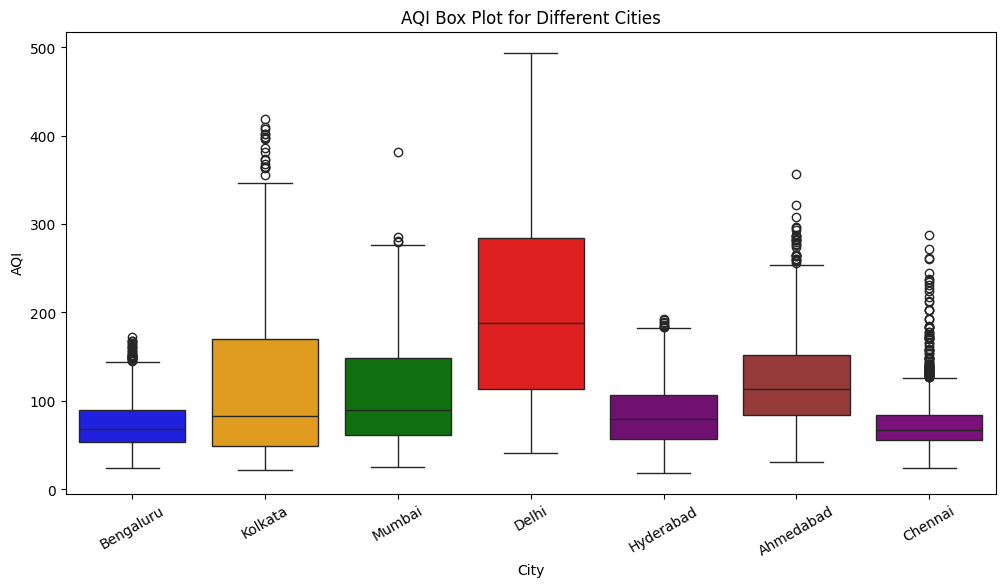

In [17]:
import pandas as pd

import seaborn as sns

# Convert AQI to numeric and forward-fill missing values
for city, df in dfs.items():
    df["AQI"] = pd.to_numeric(df["AQI"], errors="coerce")
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")  # Convert to datetime
    df["City"] = city  # Add city name column

# Concatenate all DataFrames
combined_df = pd.concat(dfs.values(), ignore_index=True)

# Plot using Seaborn boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x="City", y="AQI", data=combined_df, palette=city_colors)
plt.xticks(rotation=30)
plt.xlabel("City")
plt.ylabel("AQI")
plt.title("AQI Box Plot for Different Cities")
plt.show()


### Correlation Between Cities

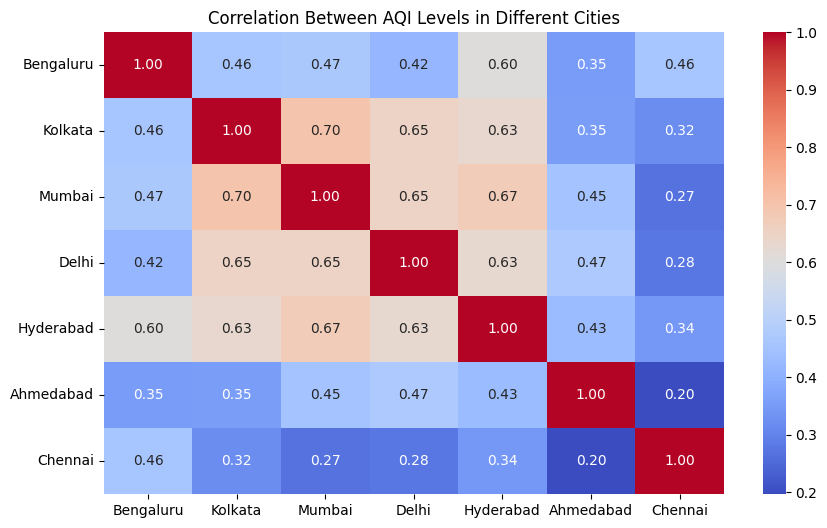

In [19]:

# Combine AQI data from all cities
aqi_data = pd.DataFrame({city: df["AQI"].values for city, df in dfs.items()})
plt.figure(figsize=(10, 6))
sns.heatmap(aqi_data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between AQI Levels in Different Cities")
plt.show()


### AQI Levels: Weekday vs Weekend

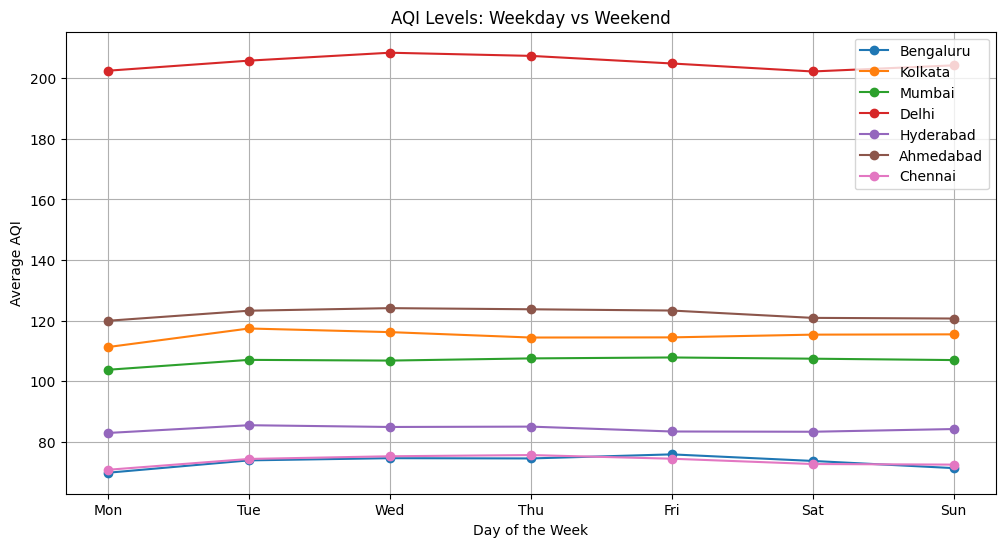

In [21]:

plt.figure(figsize=(12, 6))
for city, df in dfs.items():
    df["DayOfWeek"] = df["Date"].dt.dayofweek
    weekday_mean = df.groupby("DayOfWeek")["AQI"].mean()
    plt.plot(weekday_mean, marker="o", label=city)
 
plt.xticks(ticks=range(7), labels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
plt.xlabel("Day of the Week")
plt.ylabel("Average AQI")
plt.title("AQI Levels: Weekday vs Weekend")
plt.legend()
plt.grid()
plt.show()


### Monthly AQI Trends

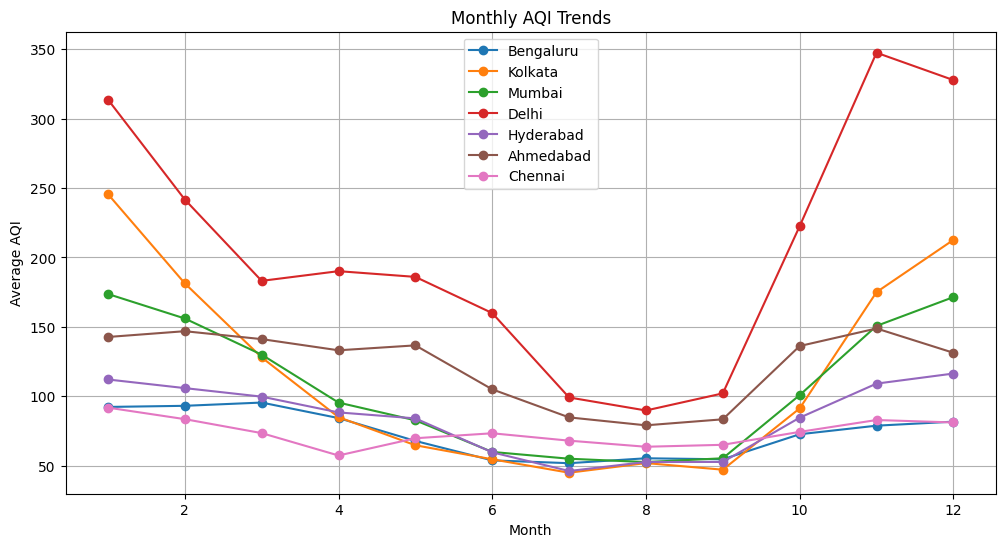

In [23]:

plt.figure(figsize=(12, 6))
 
for city, df in dfs.items():
    df["Month"] = df["Date"].dt.month
    monthly_mean = df.groupby("Month")["AQI"].mean()
    plt.plot(monthly_mean, marker="o", label=city)
 
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.title("Monthly AQI Trends")
plt.legend()
plt.grid()
plt.show()


### Seasonal Variation (Winter, Summer, Monsoon, Post-Monsoon)


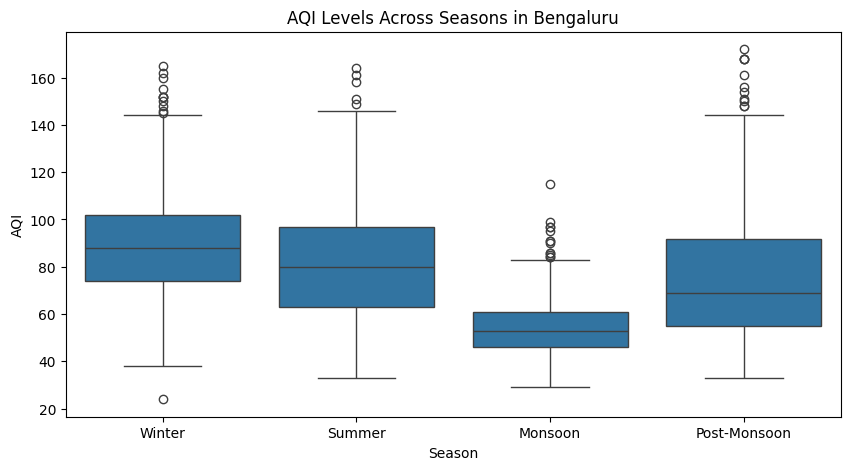

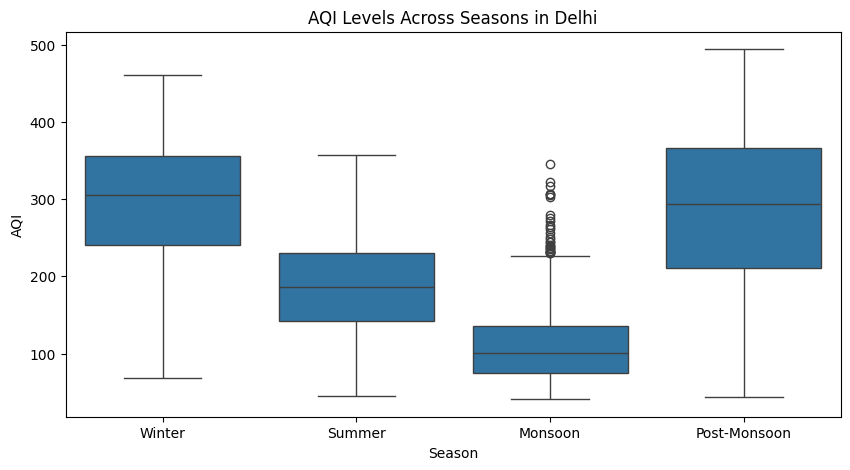

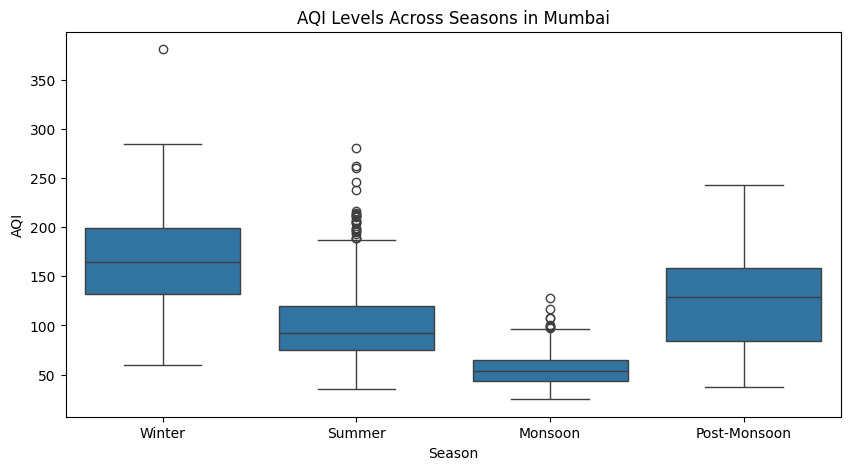

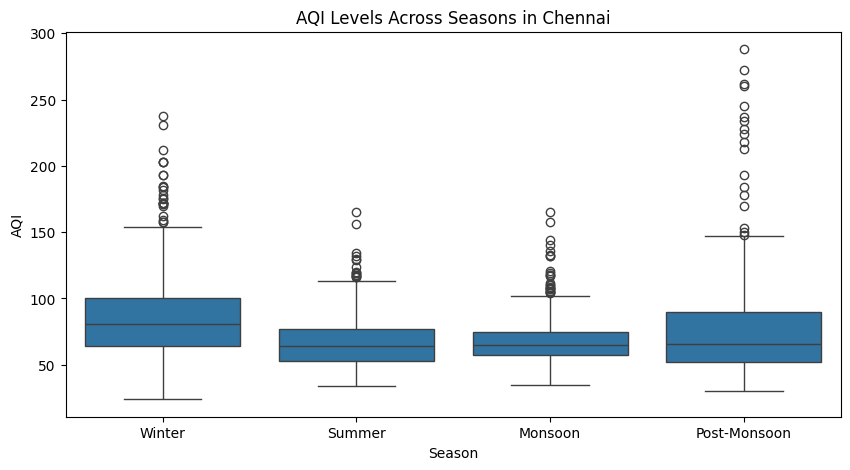

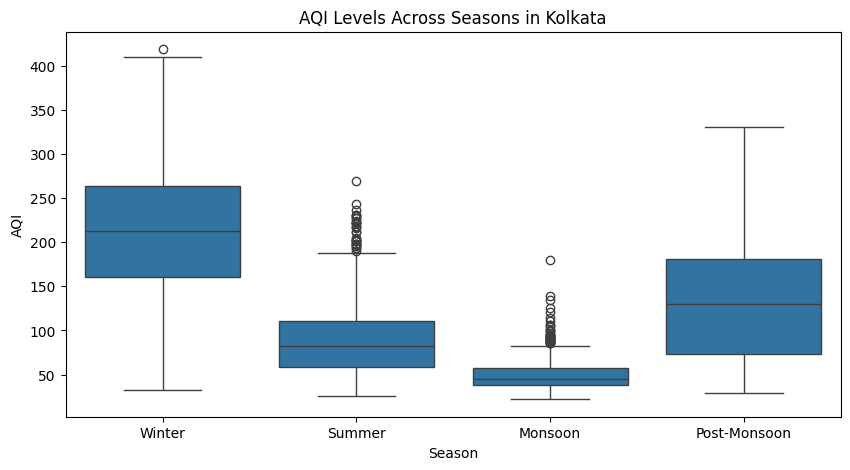

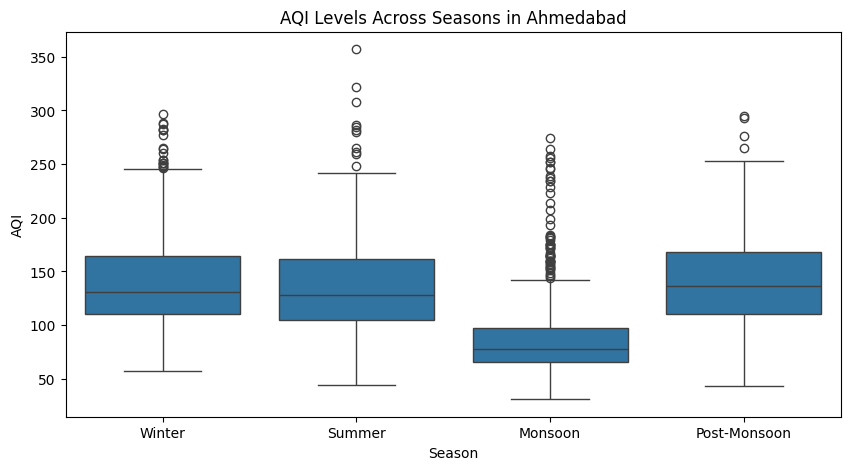

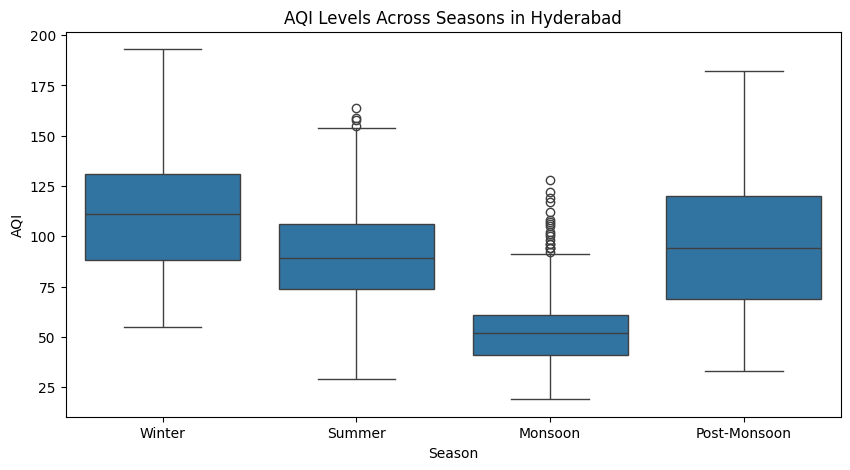

In [25]:

 
# Define seasons in India
def get_season(date):
    month = date.month
    if month in [12, 1, 2]:  # Winter (Dec - Feb)
        return 'Winter'
    elif month in [3, 4, 5]:  # Summer (Mar - May)
        return 'Summer'
    elif month in [6, 7, 8, 9]:  # Monsoon (Jun - Sep)
        return 'Monsoon'
    else:  # Post-Monsoon (Oct - Nov)
        return 'Post-Monsoon'
 
# Loop through all city DataFrames
cities = ['Bengaluru', 'Delhi', 'Mumbai', 'Chennai', 'Kolkata', 'Ahmedabad', 'Hyderabad']
 
for city in cities:
    df = globals()[f'df_{city}']  # Access DataFrame dynamically
    df['Date'] = pd.to_datetime(df['Date'])  # Ensure Date column is in datetime format
    df['Season'] = df['Date'].apply(get_season)
 
    # Plot AQI distribution by season
    plt.figure(figsize=(10, 5))
    sns.boxplot(x='Season', y='AQI', data=df, order=['Winter', 'Summer', 'Monsoon', 'Post-Monsoon'])
    plt.title(f'AQI Levels Across Seasons in {city}')
    plt.xlabel('Season')
    plt.ylabel('AQI')
plt.show()


- Winter and Post-Monsoon tend to have higher AQI due to lower wind speed and higher pollution retention.

### Pollution Spikes in Winter vs. Monsoon


C:\Users\admin\AppData\Local\Temp\ipykernel_4148\3196784487.py:8: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(winter_aqi, label='Winter', shade=True, color='red')
C:\Users\admin\AppData\Local\Temp\ipykernel_4148\3196784487.py:9: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(monsoon_aqi, label='Monsoon', shade=True, color='blue')
C:\Users\admin\AppData\Local\Temp\ipykernel_4148\3196784487.py:8: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(winter_aqi, label='Winter', shade=True, color='red')
C:\Users\admin\AppData\Local\Temp\ipykernel_4148\3196784487.py:9: FutureWarning: 

`shade` is now deprecated in favor of `fill`; s

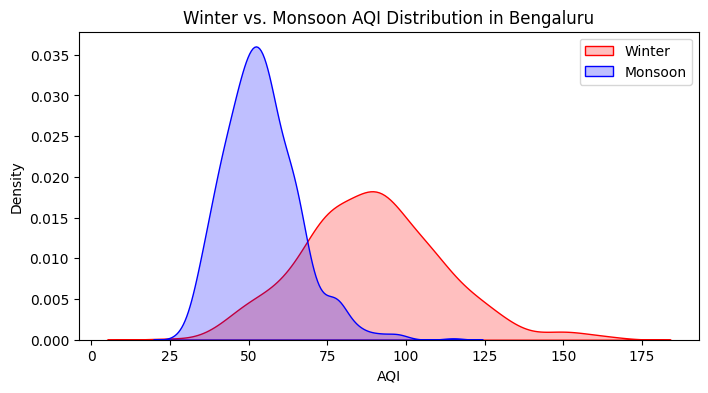

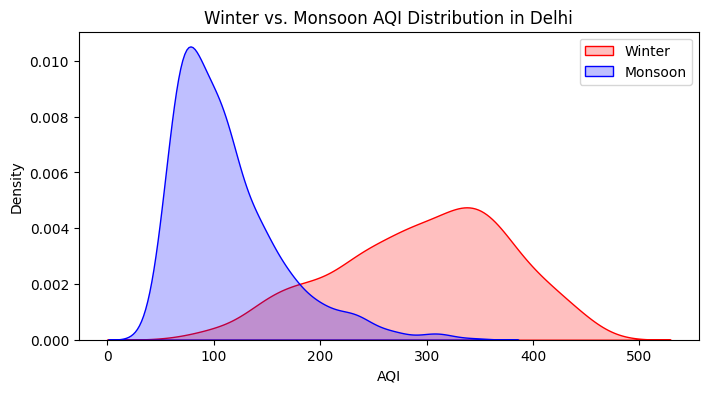

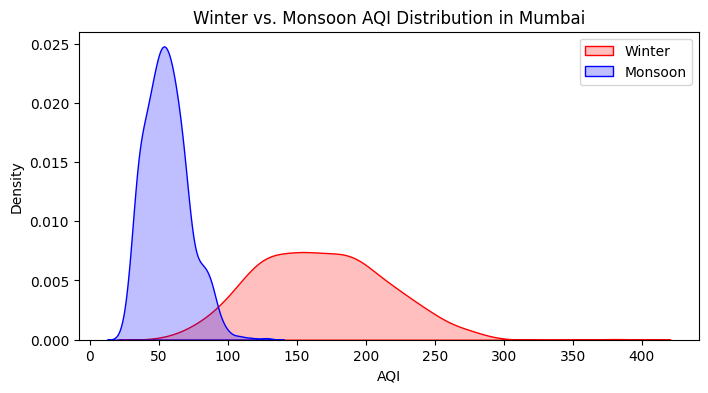

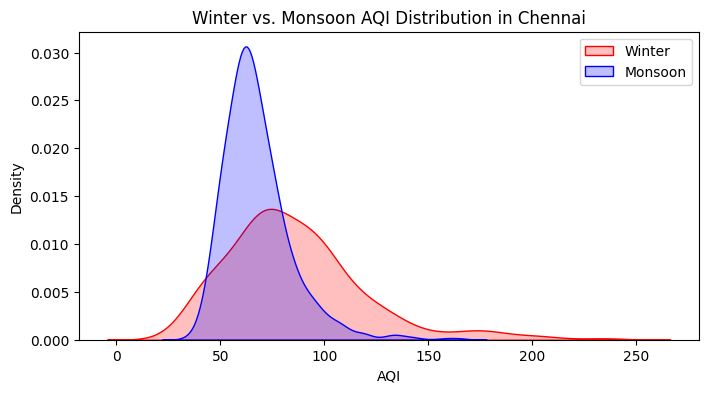

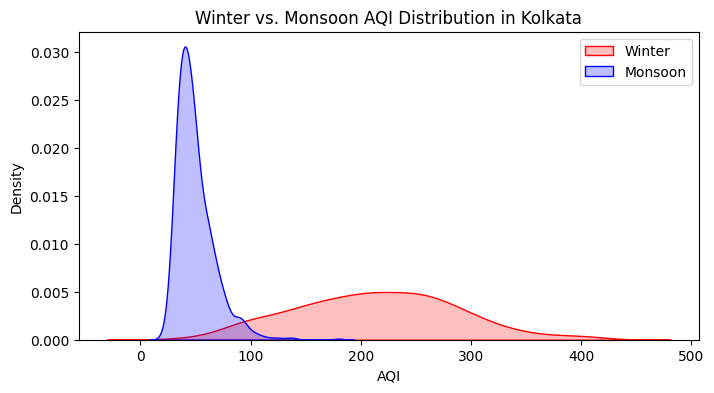

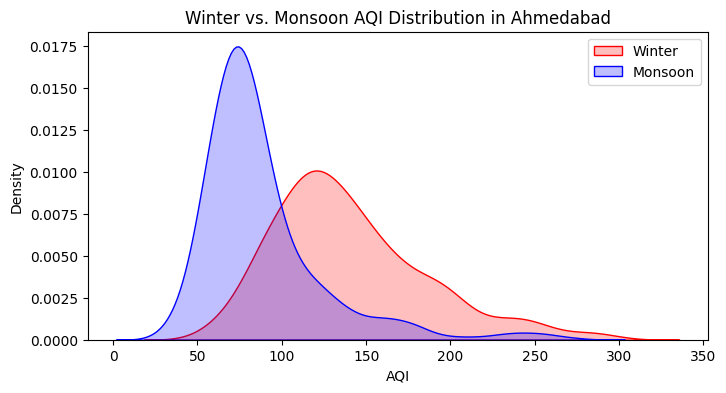

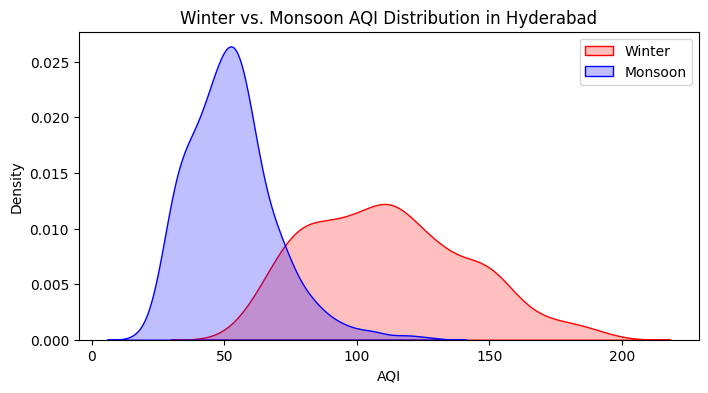

In [27]:

 
for city in cities:
    df = globals()[f'df_{city}']
    
    winter_aqi = df[df['Season'] == 'Winter']['AQI']
    monsoon_aqi = df[df['Season'] == 'Monsoon']['AQI']
 
    plt.figure(figsize=(8, 4))
    sns.kdeplot(winter_aqi, label='Winter', shade=True, color='red')
    sns.kdeplot(monsoon_aqi, label='Monsoon', shade=True, color='blue')
    plt.title(f'Winter vs. Monsoon AQI Distribution in {city}')
    plt.xlabel('AQI')
    plt.ylabel('Density')
    plt.legend()
plt.show()
 


- Winter AQI is having a heavier tail, indicating more extreme pollution levels compared to Monsoon.

- Monsoon tends to have lower AQI due to rain cleaning the air.



### Festival Impact (Diwali, Holi, New Year)


C:\Users\admin\AppData\Local\Temp\ipykernel_4148\1318553821.py:40: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8, 5))


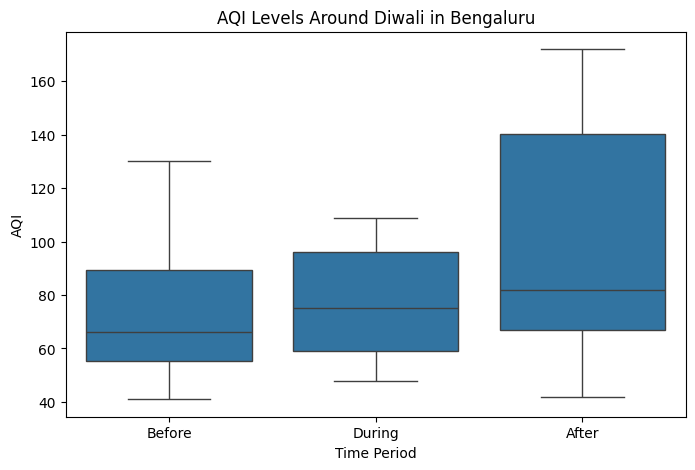

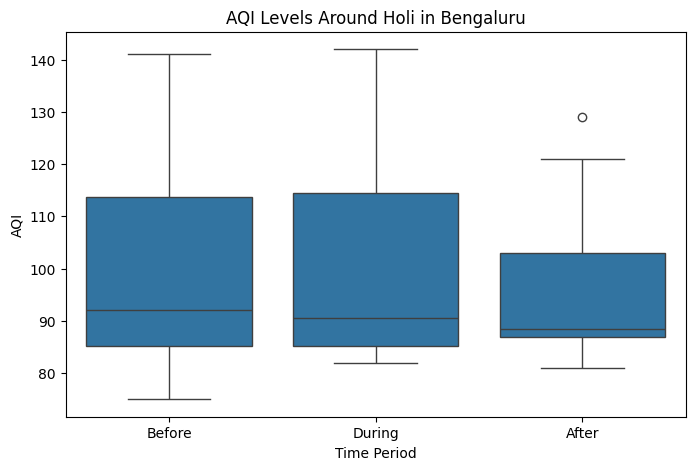

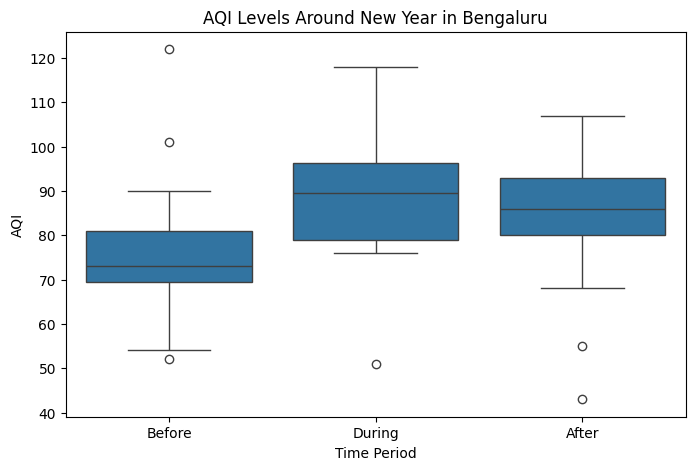

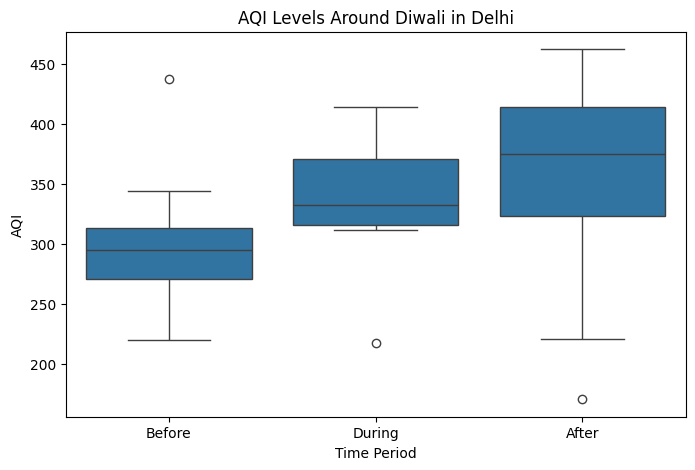

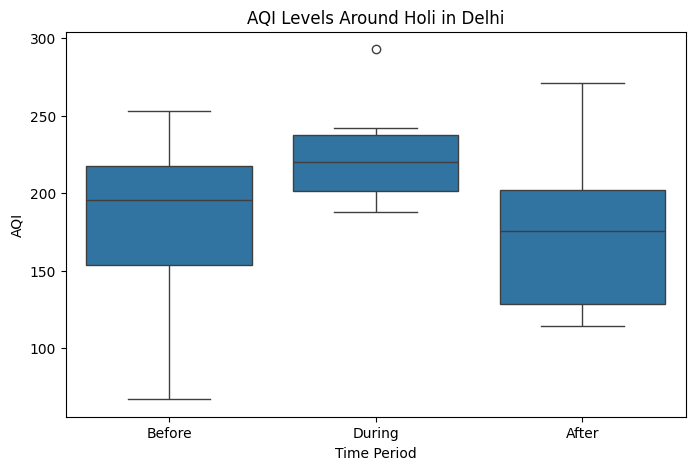

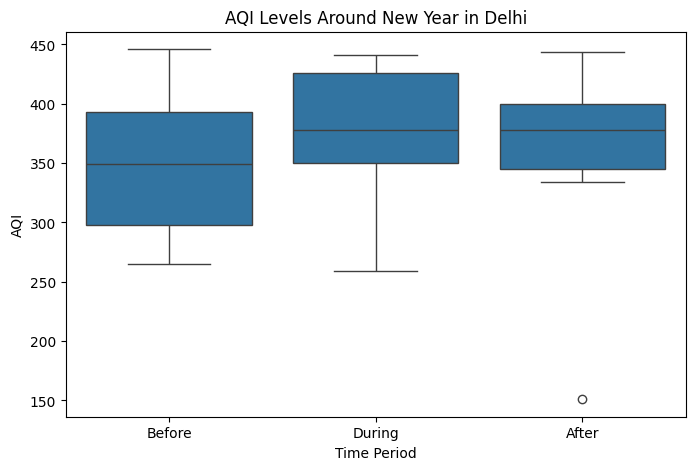

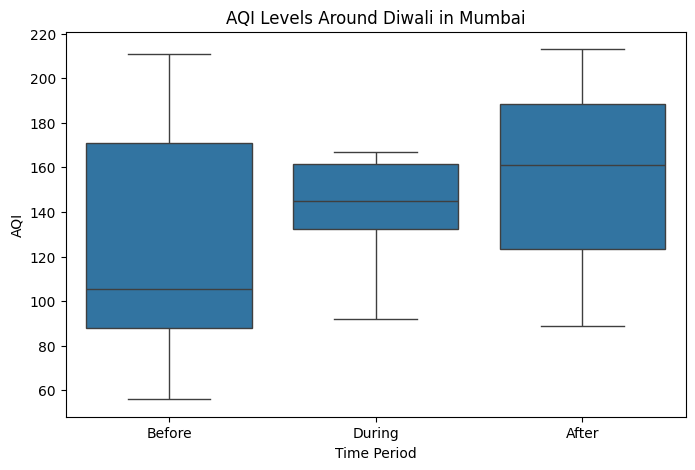

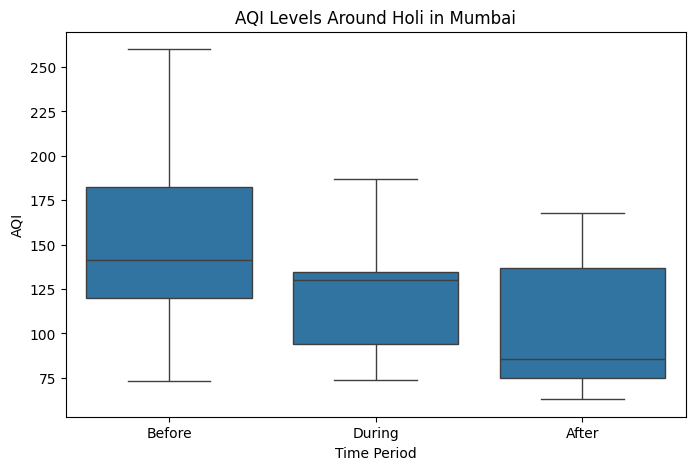

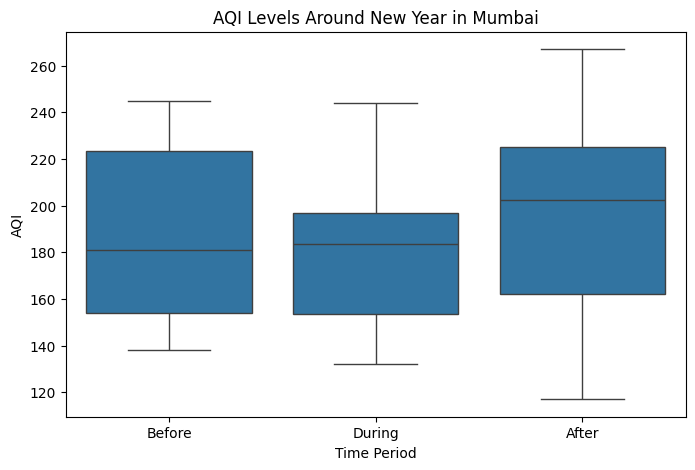

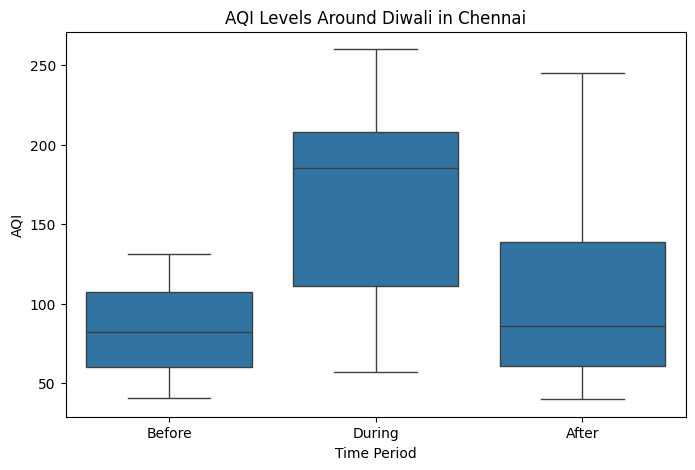

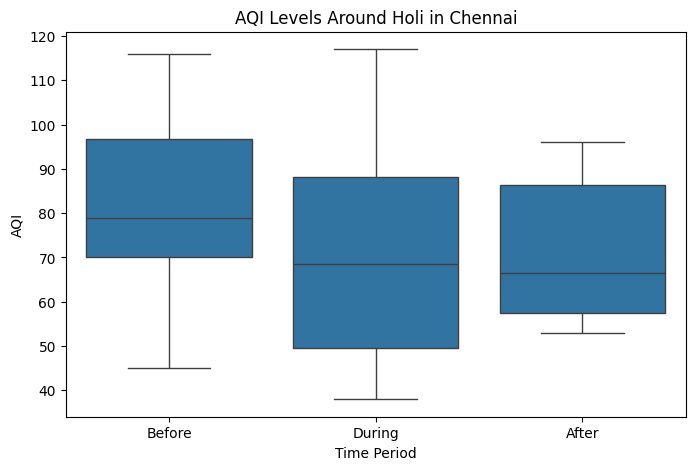

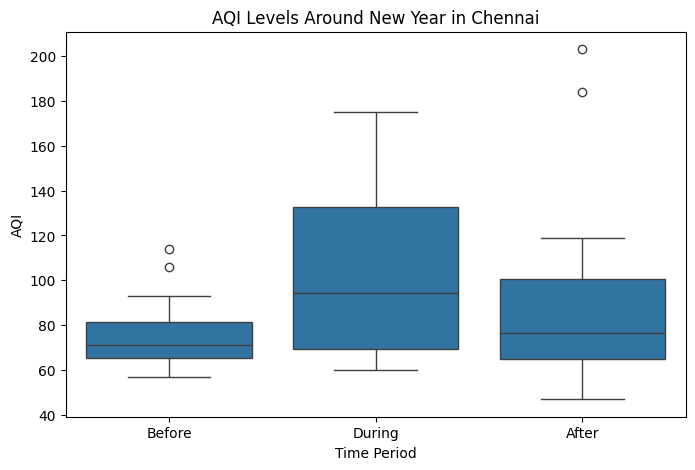

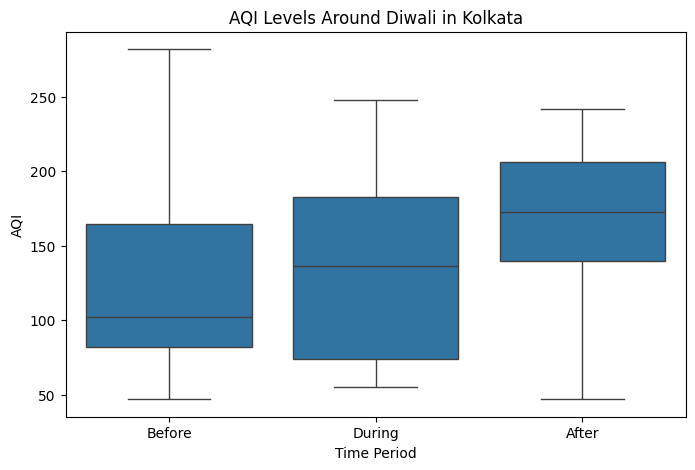

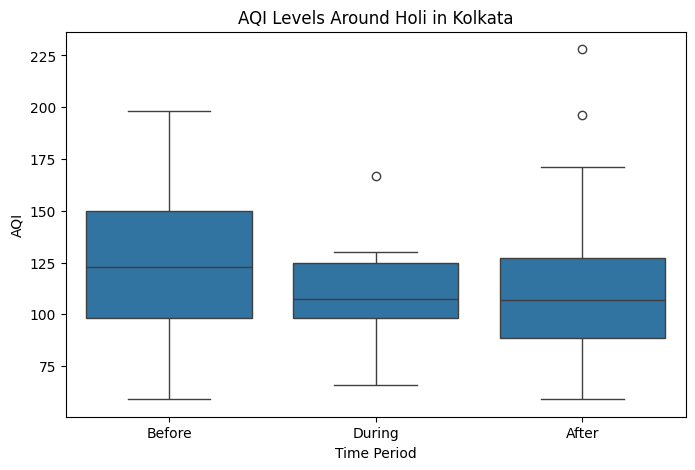

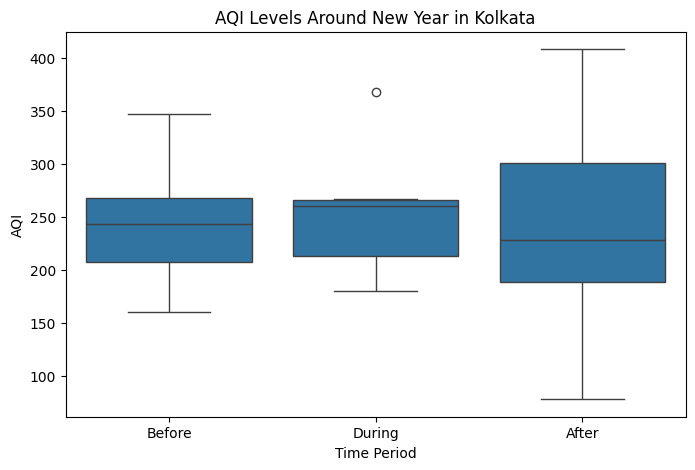

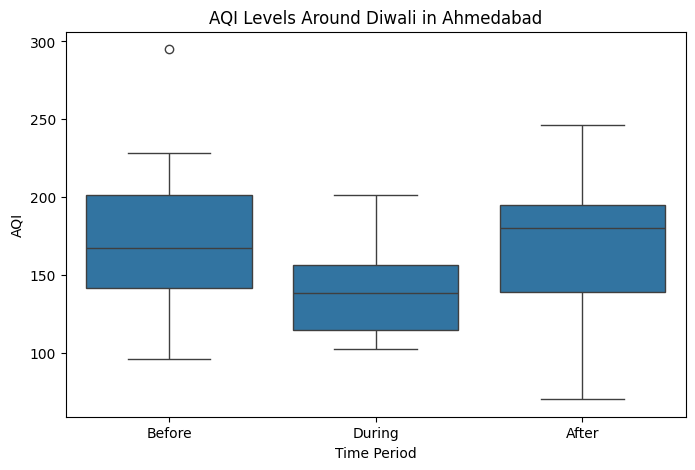

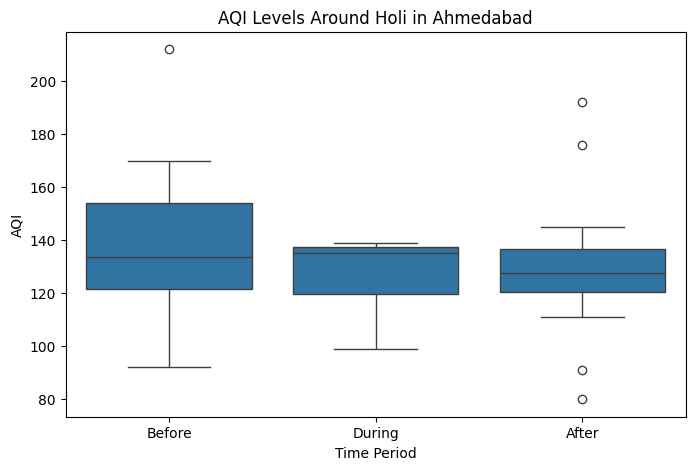

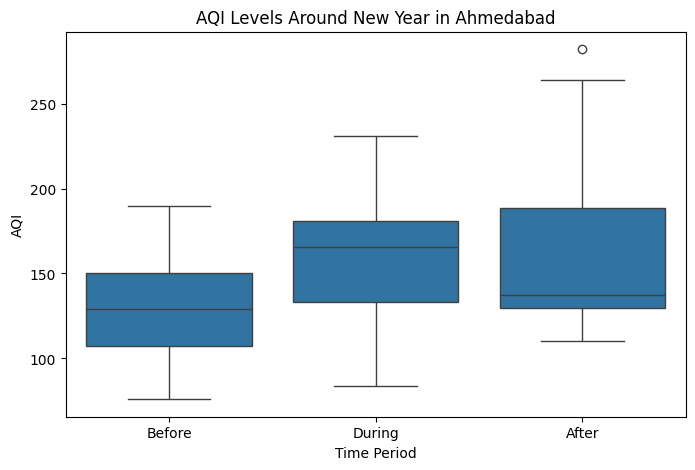

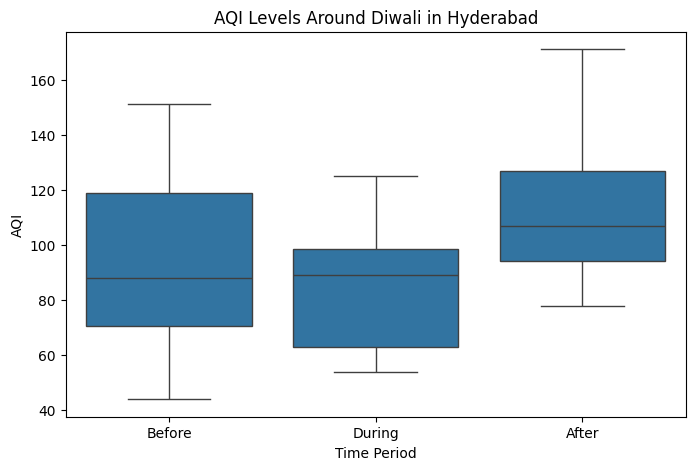

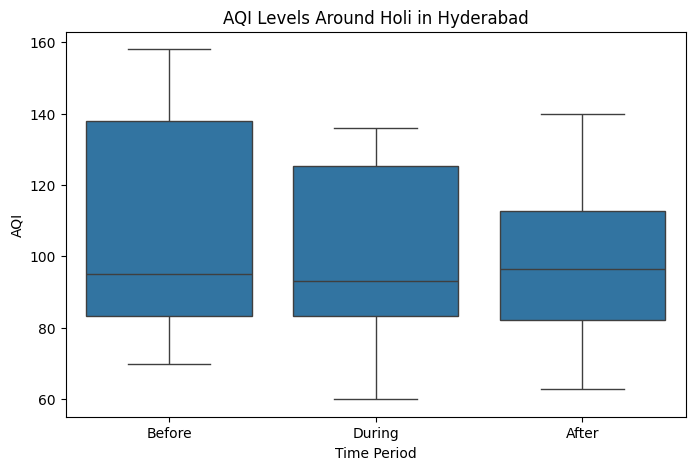

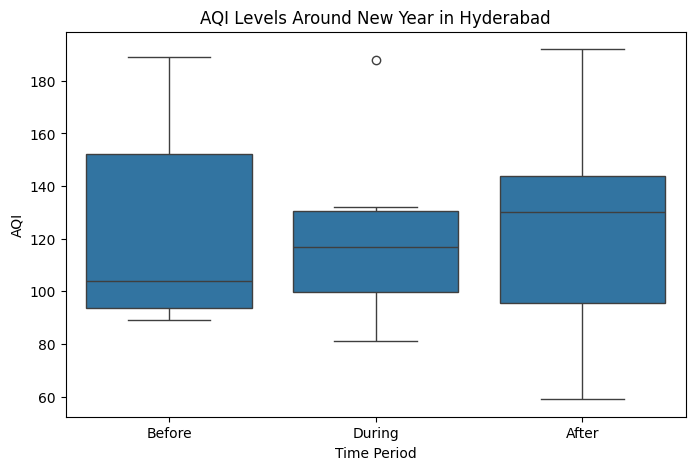

In [30]:
import numpy as np

festival_dates = {
    'Diwali': ['2019-10-27', '2020-11-14', '2021-11-04', '2022-10-24', '2023-11-12', '2024-10-31'],
    'Holi': ['2019-03-21', '2020-03-10', '2021-03-29', '2022-03-18', '2023-03-08', '2024-03-25'],
    'New Year': ['2019-01-01', '2020-01-01', '2021-01-01', '2022-01-01', '2023-01-01', '2024-01-01']
}
 
# Convert to datetime for comparison
for key in festival_dates:
    festival_dates[key] = pd.to_datetime(festival_dates[key])

#Compare AQI Before, During, and After Festivals

days_range = 3  # Number of days before/after to consider
 
for city in cities:
    df = globals()[f'df_{city}']
    df['Date'] = pd.to_datetime(df['Date'])
 
    for festival, dates in festival_dates.items():
        aqi_before, aqi_during, aqi_after = [], [], []
 
        for date in dates:
            before = df[(df['Date'] >= date - pd.Timedelta(days=days_range)) & (df['Date'] < date)]
            during = df[df['Date'] == date]
            after = df[(df['Date'] > date) & (df['Date'] <= date + pd.Timedelta(days=days_range))]
 
            aqi_before.extend(before['AQI'].values)
            aqi_during.extend(during['AQI'].values)
            aqi_after.extend(after['AQI'].values)
 
        # Create DataFrame for visualization
        festival_df = pd.DataFrame({
            'AQI': np.concatenate([aqi_before, aqi_during, aqi_after]),
            'Period': ['Before'] * len(aqi_before) + ['During'] * len(aqi_during) + ['After'] * len(aqi_after)
        })
 
        # Boxplot for AQI levels before, during, and after the festival
        plt.figure(figsize=(8, 5))
        sns.boxplot(x='Period', y='AQI', data=festival_df, order=['Before', 'During', 'After'])
        plt.title(f'AQI Levels Around {festival} in {city}')
        plt.xlabel('Time Period')
        plt.ylabel('AQI')
plt.show()


C:\Users\admin\AppData\Local\Temp\ipykernel_4148\549385269.py:21: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8, 5))


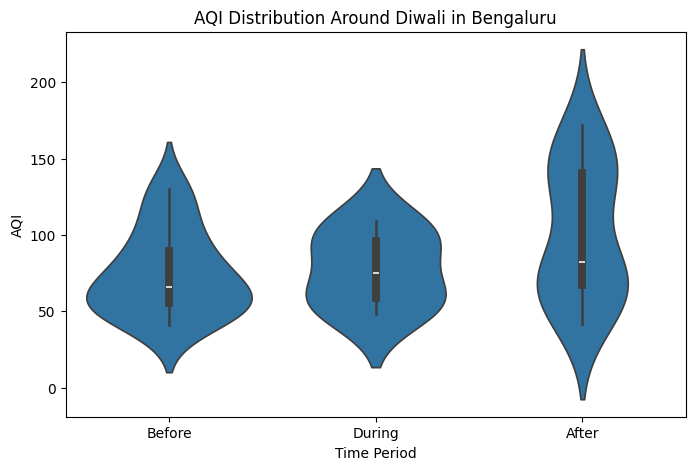

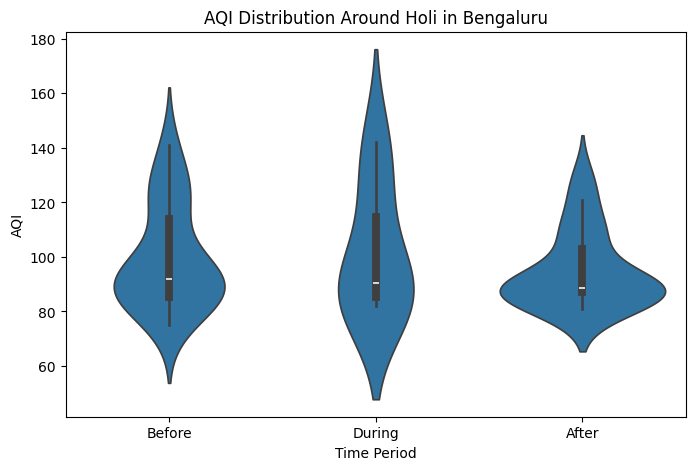

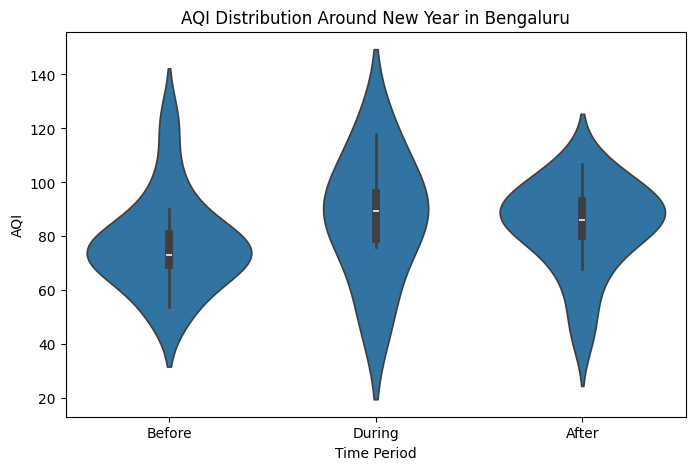

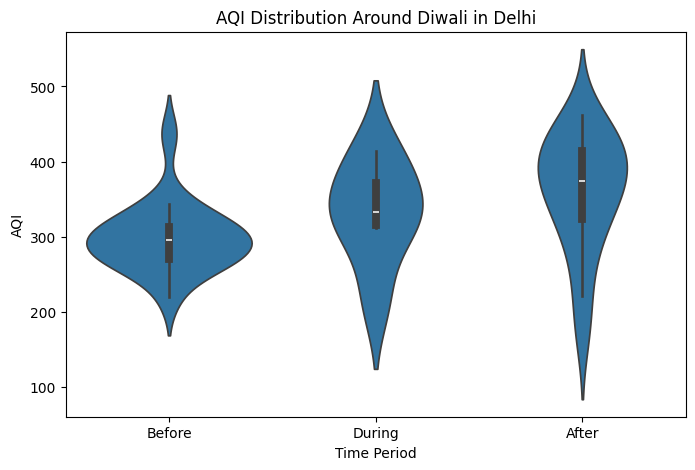

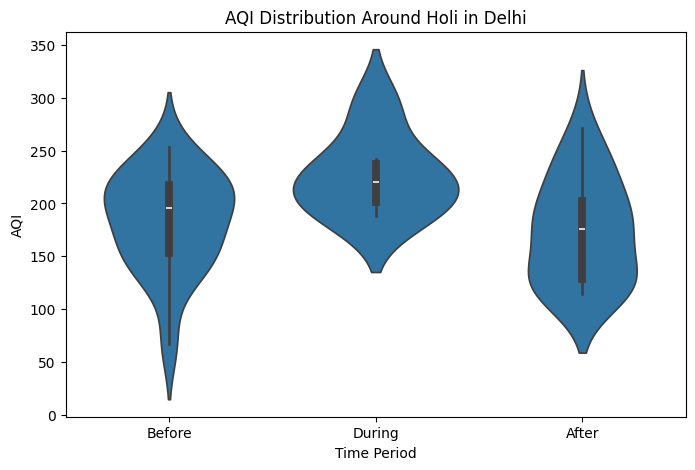

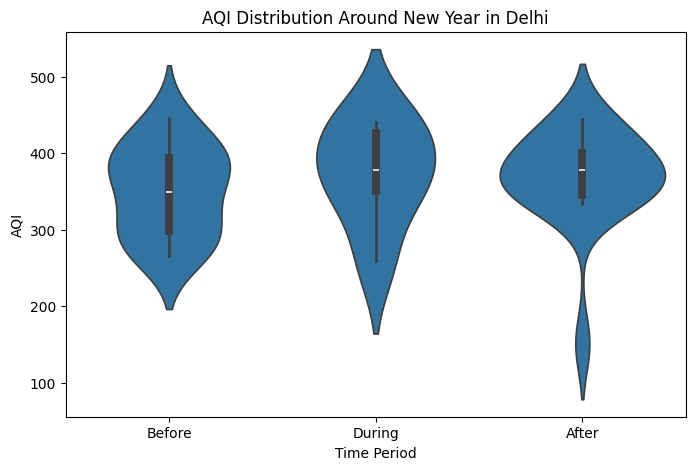

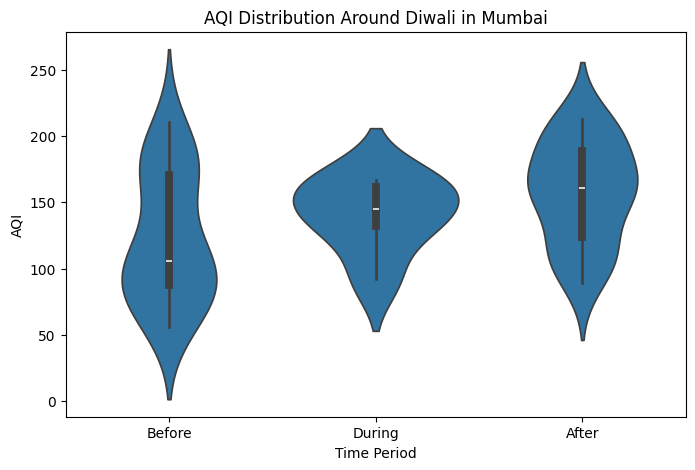

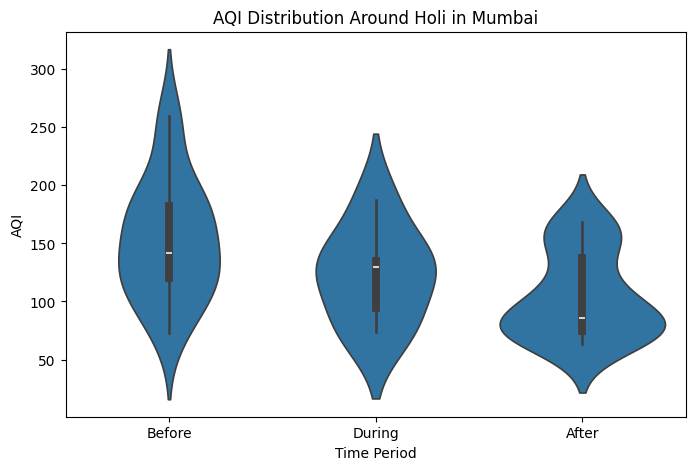

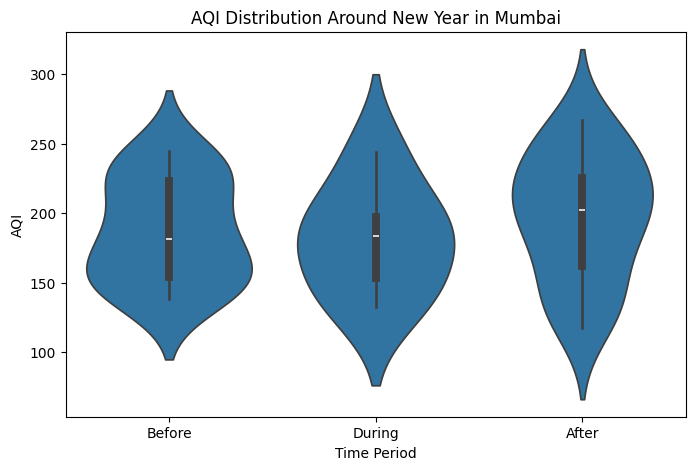

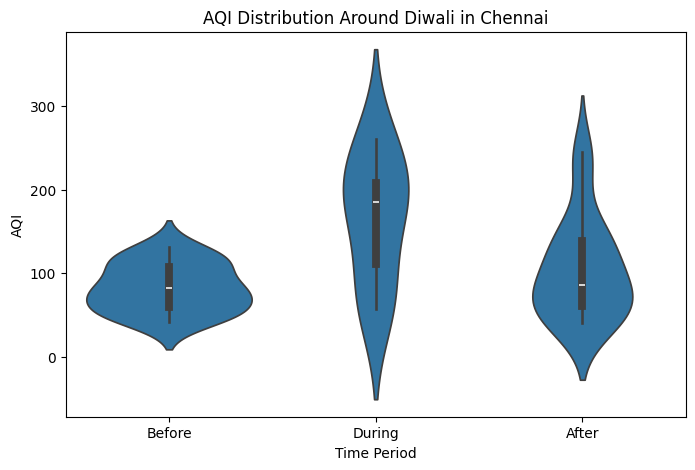

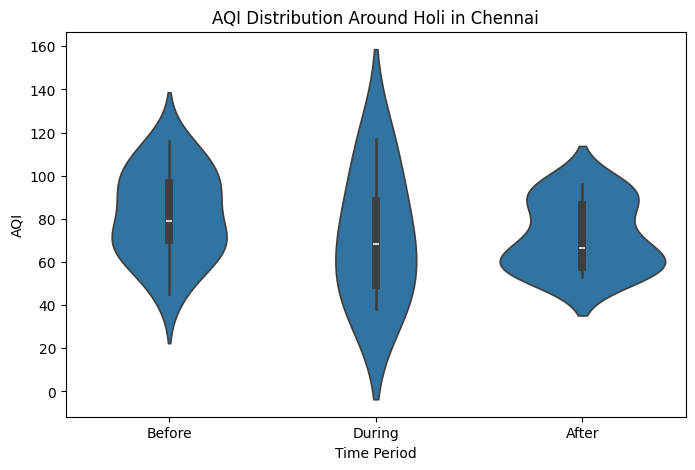

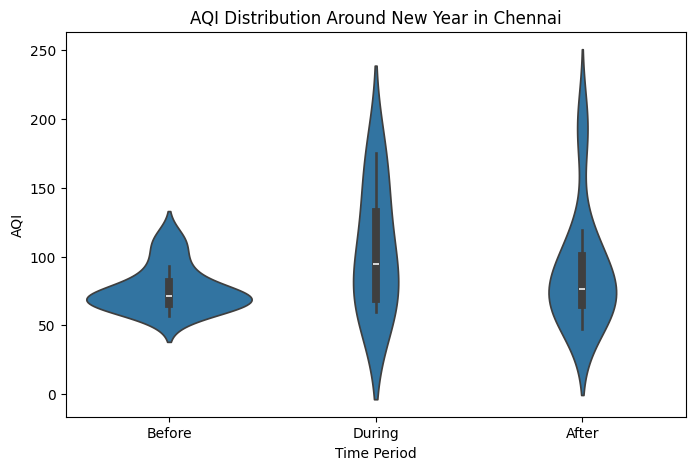

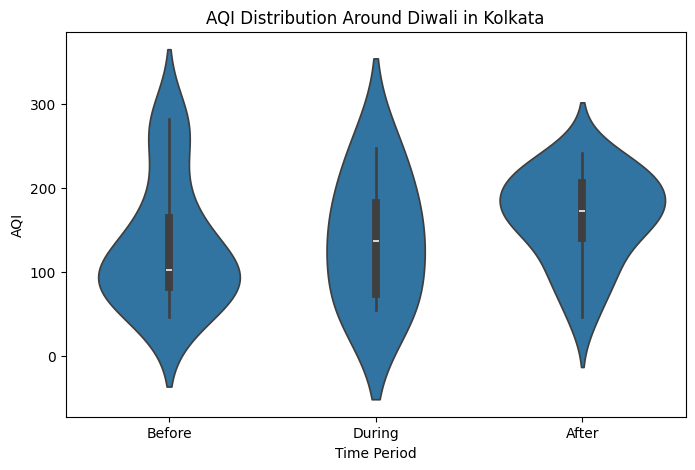

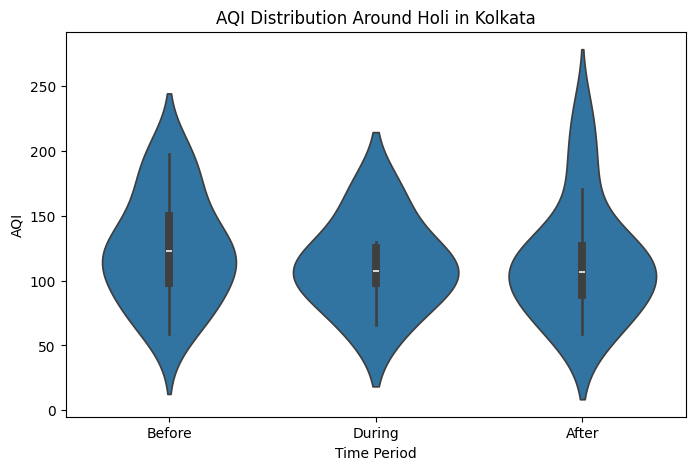

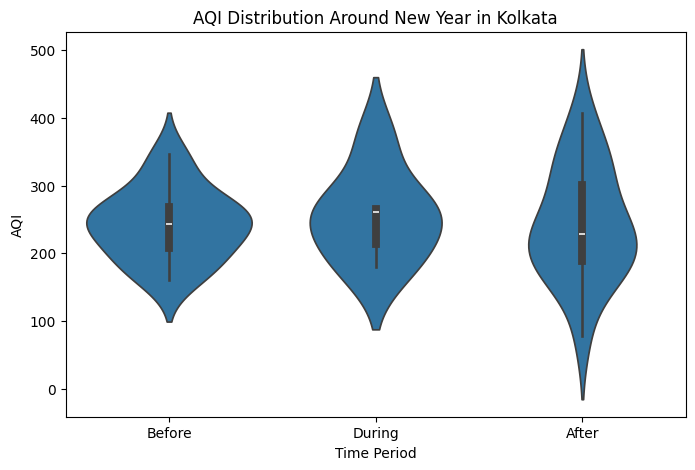

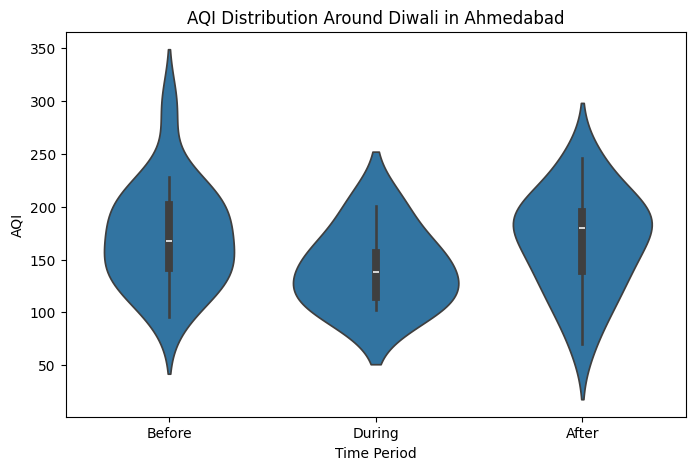

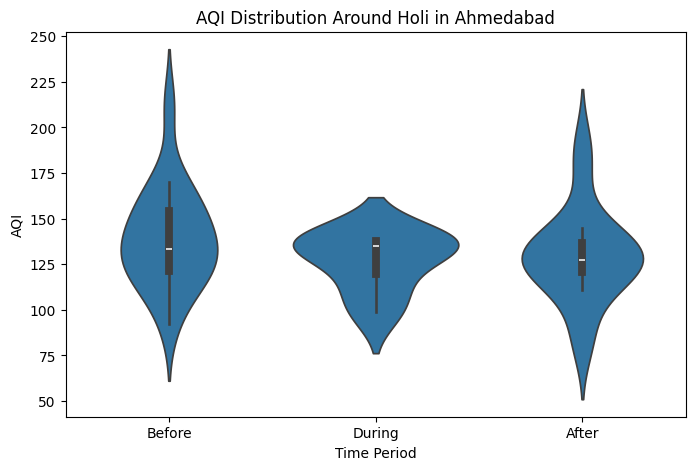

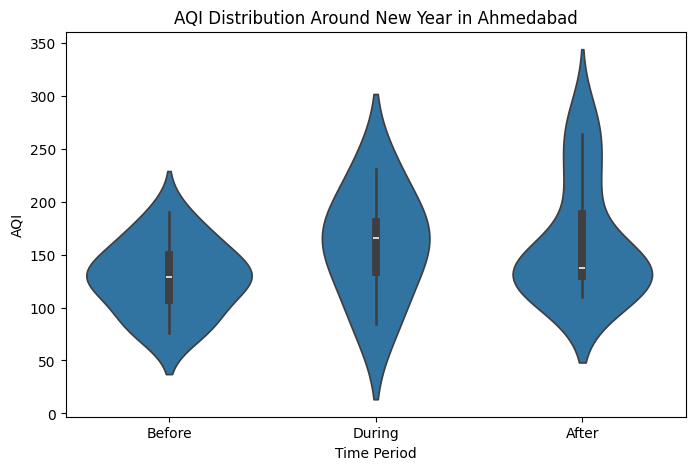

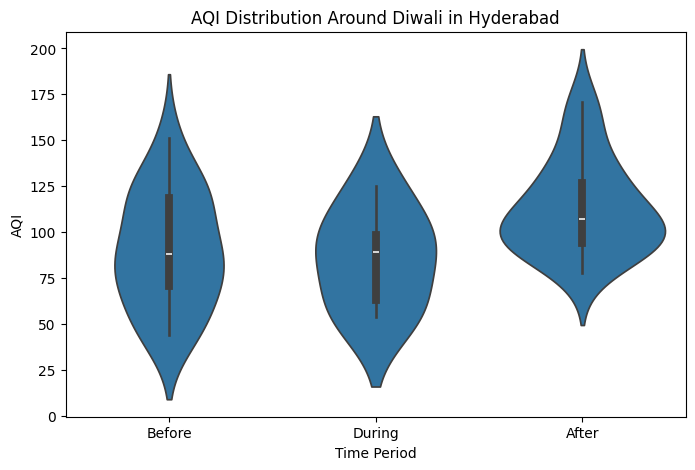

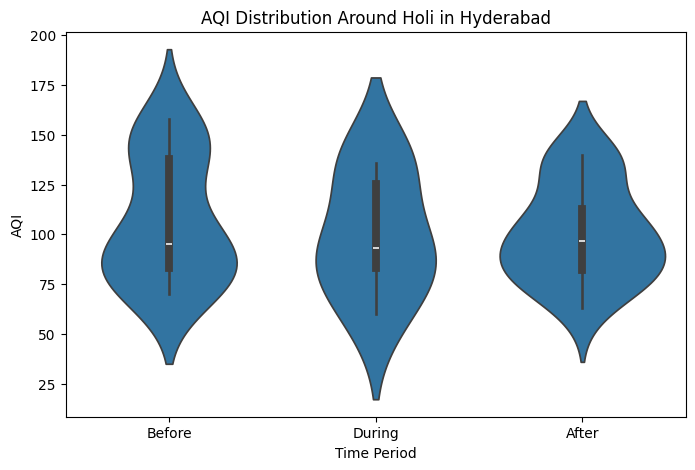

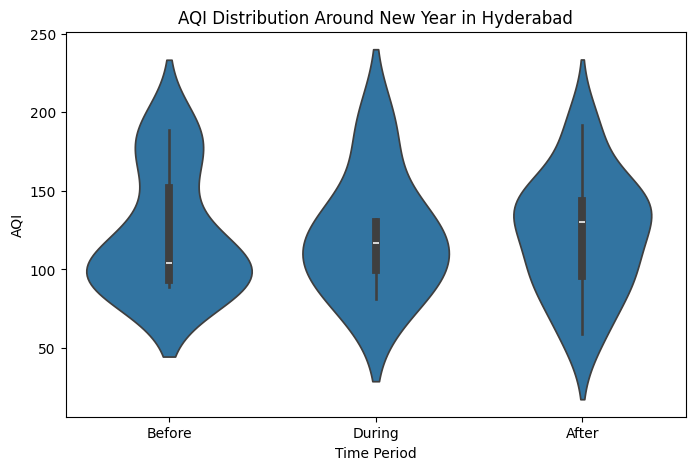

In [31]:

for city in cities:
    df = globals()[f'df_{city}']
 
    for festival, dates in festival_dates.items():
        aqi_before, aqi_during, aqi_after = [], [], []
 
        for date in dates:
            before = df[(df['Date'] >= date - pd.Timedelta(days=3)) & (df['Date'] < date)]
            during = df[df['Date'] == date]
            after = df[(df['Date'] > date) & (df['Date'] <= date + pd.Timedelta(days=3))]
 
            aqi_before.extend(before['AQI'].values)
            aqi_during.extend(during['AQI'].values)
            aqi_after.extend(after['AQI'].values)
 
        festival_df = pd.DataFrame({
            'AQI': aqi_before + aqi_during + aqi_after,
            'Period': ['Before'] * len(aqi_before) + ['During'] * len(aqi_during) + ['After'] * len(aqi_after)
        })
 
        plt.figure(figsize=(8, 5))
        sns.violinplot(x='Period', y='AQI', data=festival_df, order=['Before', 'During', 'After'])
        plt.title(f'AQI Distribution Around {festival} in {city}')
        plt.xlabel('Time Period')
        plt.ylabel('AQI')
plt.show()




C:\Users\admin\AppData\Local\Temp\ipykernel_4148\3387470883.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(avg_aqi.keys()), y=list(avg_aqi.values()), palette=['blue', 'red', 'green'])
C:\Users\admin\AppData\Local\Temp\ipykernel_4148\3387470883.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(avg_aqi.keys()), y=list(avg_aqi.values()), palette=['blue', 'red', 'green'])
C:\Users\admin\AppData\Local\Temp\ipykernel_4148\3387470883.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(avg_aqi.keys()), y=list(avg_aqi.v

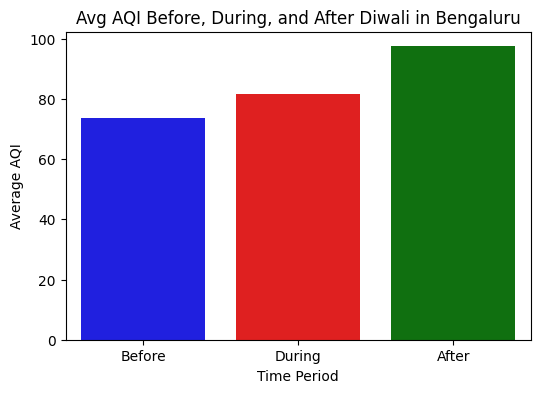

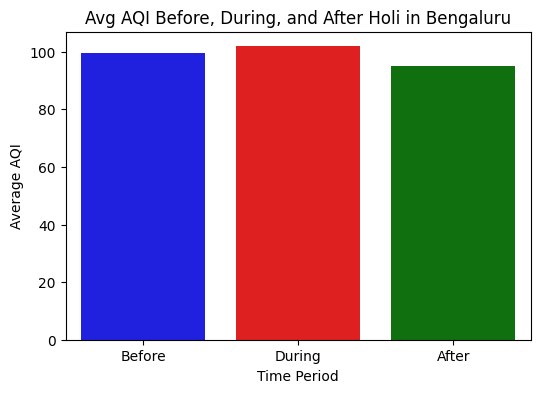

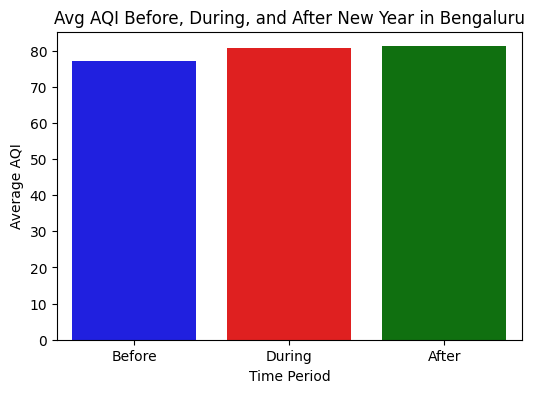

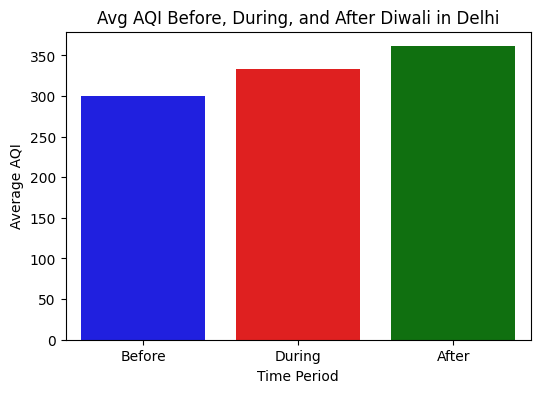

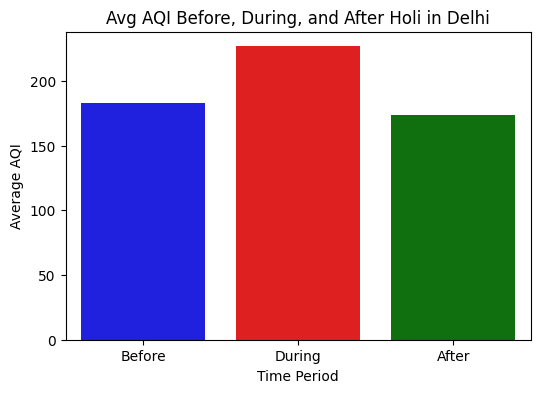

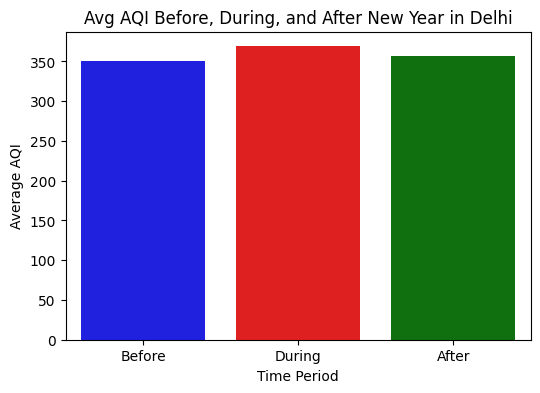

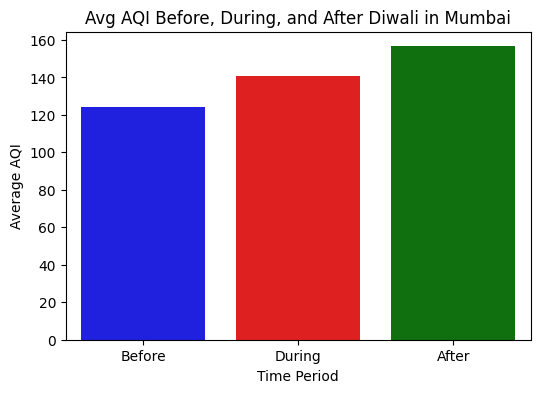

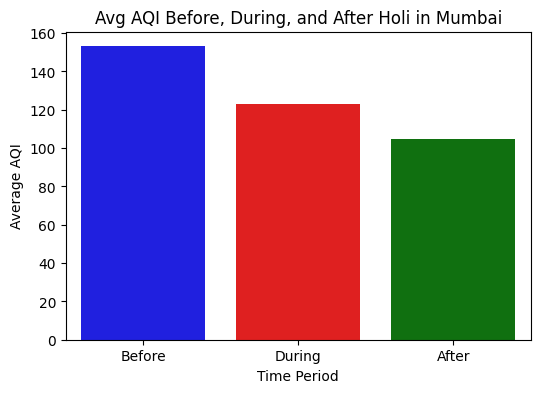

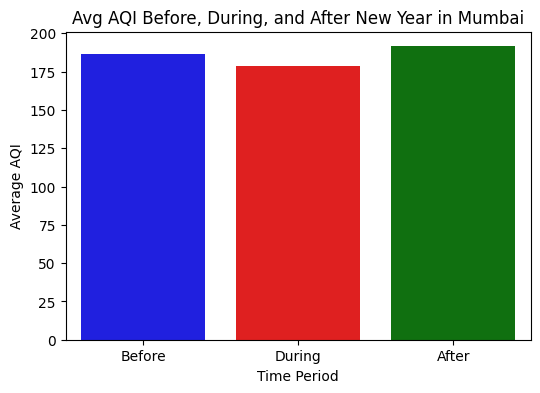

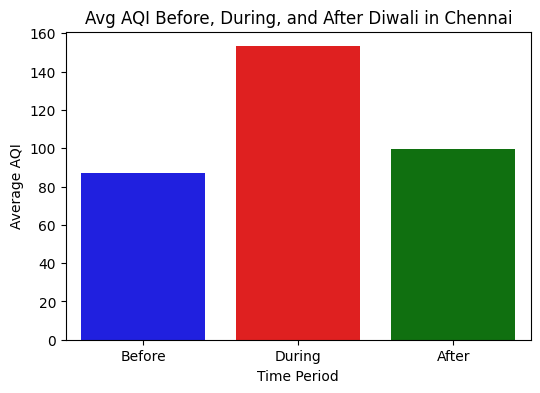

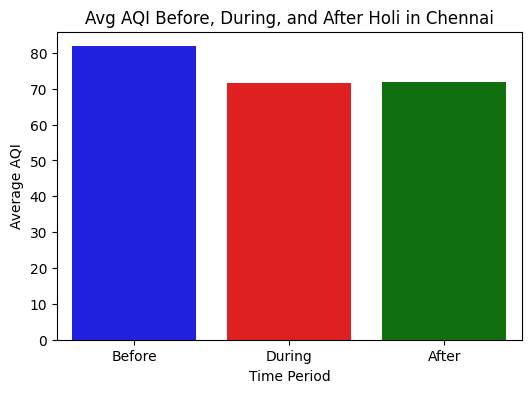

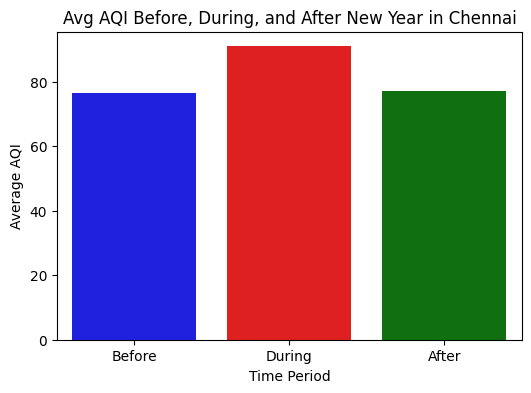

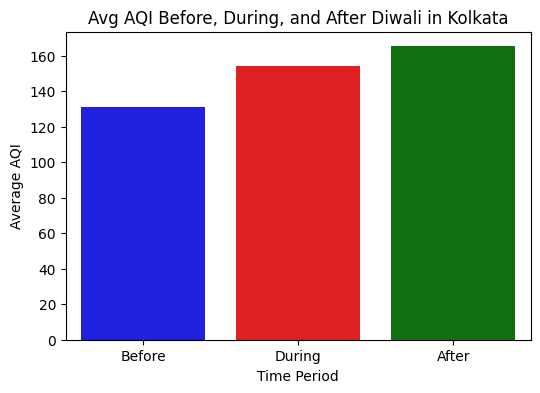

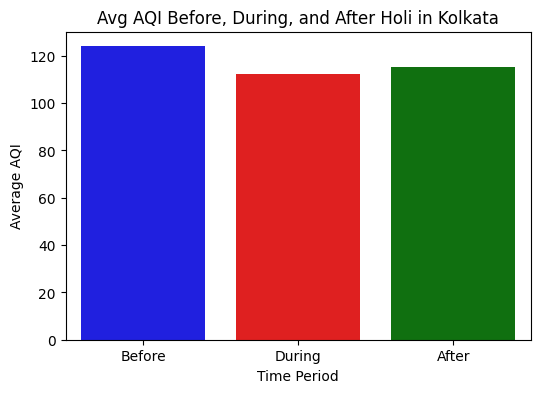

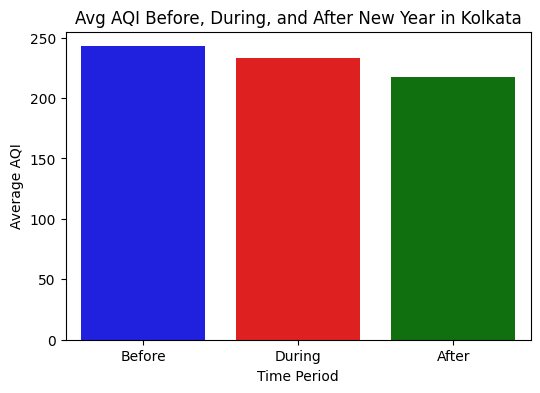

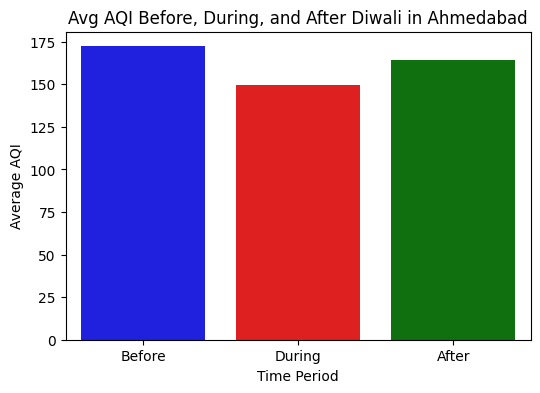

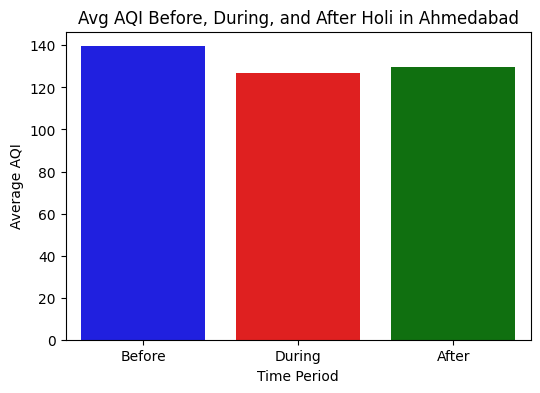

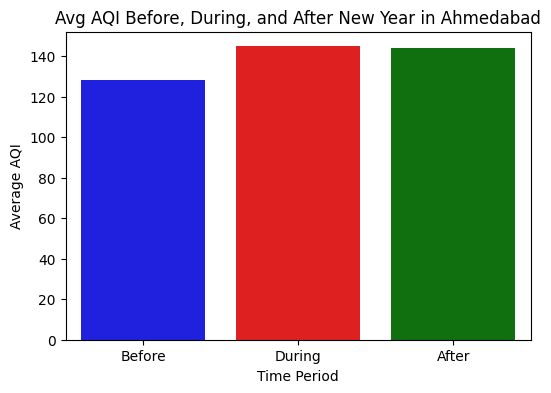

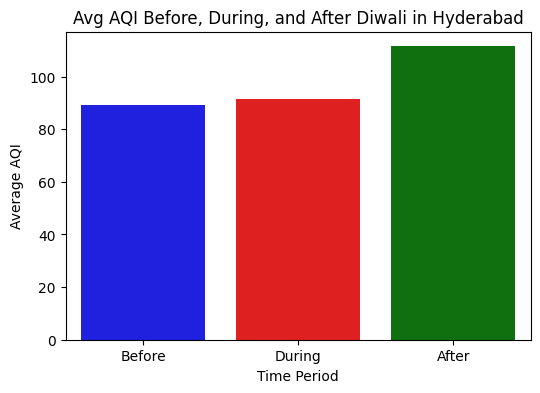

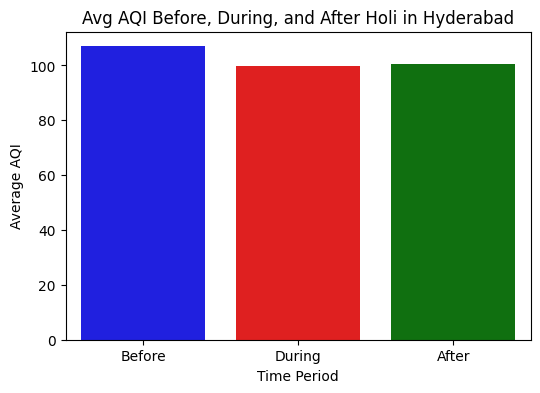

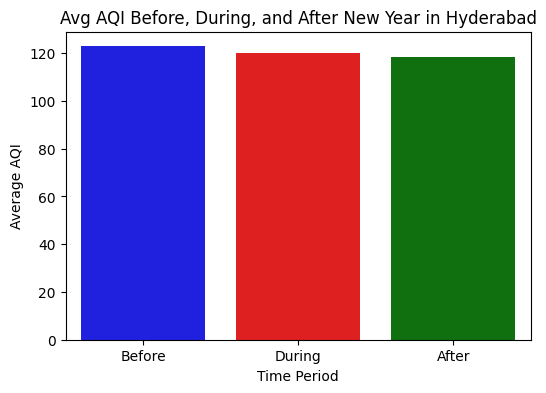

In [32]:
# Define festival dates for each year (you can update based on actual festival dates)
festival_dates = {
    "Diwali": ["2019-10-27", "2020-11-14", "2021-11-04", "2022-10-24", "2023-11-12", "2024-11-01"],
    "Holi": ["2019-03-21", "2020-03-10", "2021-03-29", "2022-03-18", "2023-03-08", "2024-03-25"],
    "New Year": ["2020-01-01", "2021-01-01", "2022-01-01", "2023-01-01", "2024-01-01"]
}
 
# Convert string dates to datetime objects
for fest in festival_dates:
    festival_dates[fest] = [pd.Timestamp(date) for date in festival_dates[fest]]
 
# List of cities
cities = ["Bengaluru", "Delhi", "Mumbai", "Chennai", "Kolkata", "Ahmedabad", "Hyderabad"]
 
for city in cities:
    df = globals()[f'df_{city}']
    df['Date'] = pd.to_datetime(df['Date'])  # Ensure Date column is in datetime format
 
    for festival, dates in festival_dates.items():
        aqi_data = {'Before': [], 'During': [], 'After': []}
 
        for date in dates:
            if festival == "New Year":
                # Special handling for New Year: Before = Dec 29-31 of previous year
                prev_year = date.year - 1
                before_mask = (df['Date'] >= pd.Timestamp(f"{prev_year}-12-29")) & (df['Date'] <= pd.Timestamp(f"{prev_year}-12-31"))
            else:
                # Regular handling for other festivals: Before = 3 days prior
                before_mask = (df['Date'] >= date - pd.Timedelta(days=3)) & (df['Date'] < date)
            
            during_mask = df['Date'] == date
            after_mask = (df['Date'] > date) & (df['Date'] <= date + pd.Timedelta(days=3))
 
            before = df[before_mask]['AQI'].mean()
            during = df[during_mask]['AQI'].mean()
            after = df[after_mask]['AQI'].mean()
 
            aqi_data['Before'].append(before)
            aqi_data['During'].append(during)
            aqi_data['After'].append(after)
 
        # Compute average AQI values, ensuring we exclude empty lists
        avg_aqi = {key: sum(val) / len(val) for key, val in aqi_data.items() if len(val) > 0 and pd.notna(sum(val))}
 
        # Plot bar chart
        plt.figure(figsize=(6, 4))
        sns.barplot(x=list(avg_aqi.keys()), y=list(avg_aqi.values()), palette=['blue', 'red', 'green'])
        plt.title(f'Avg AQI Before, During, and After {festival} in {city}')
        plt.xlabel('Time Period')
        plt.ylabel('Average AQI')
plt.show()



### Highest AQI Values

In [34]:
# Dictionary to store the highest AQI date for each city per year
highest_aqi_dates = []
 
for city in cities:
    df = globals()[f'df_{city}']
    df['Date'] = pd.to_datetime(df['Date'])  # Ensure Date column is datetime
    df['Year'] = df['Date'].dt.year  # Extract year
 
    # Find the row with the highest AQI for each year
    highest_dates = df.loc[df.groupby('Year')['AQI'].idxmax(), ['Date', 'AQI', 'Year']].copy()
    highest_dates['City'] = city  # Add city name
 
    highest_aqi_dates.append(highest_dates)
 
# Combine results into a single DataFrame
df_highest_aqi = pd.concat(highest_aqi_dates, ignore_index=True)
 
# Rearrange columns for better readability
df_highest_aqi = df_highest_aqi[['City', 'Year', 'Date', 'AQI']]
#df_highest_aqi.to_csv(f"Highest AQI.csv", index=False)
# Display final DataFrame
print(df_highest_aqi)


         City  Year       Date    AQI
0   Bengaluru  2019 2019-02-09  165.0
1   Bengaluru  2020 2020-03-03  161.0
2   Bengaluru  2021 2021-12-22  152.0
3   Bengaluru  2022 2022-11-17  168.0
4   Bengaluru  2023 2023-11-15  172.0
5   Bengaluru  2024 2024-01-16  148.0
6       Delhi  2019 2019-11-03  494.0
7       Delhi  2020 2020-11-09  477.0
8       Delhi  2021 2021-11-12  471.0
9       Delhi  2022 2022-11-03  450.0
10      Delhi  2023 2023-11-03  468.0
11      Delhi  2024 2024-11-18  494.0
12     Mumbai  2019 2019-12-25  280.0
13     Mumbai  2020 2020-01-26  250.0
14     Mumbai  2021 2021-01-07  285.0
15     Mumbai  2022 2022-01-24  381.0
16     Mumbai  2023 2023-03-04  281.0
17     Mumbai  2024 2024-11-02  208.0
18    Chennai  2019 2019-11-08  288.0
19    Chennai  2020 2020-01-14  170.0
20    Chennai  2021 2021-12-23  171.0
21    Chennai  2022 2022-12-07  238.0
22    Chennai  2023 2023-11-13  245.0
23    Chennai  2024 2024-01-14  231.0
24    Kolkata  2019 2019-01-23  419.0
25    Kolkat

### Impact of COVID-19 Lockdown on AQI (2020 vs. Other Years)
- During the COVID-19 lockdown (March - May 2020), air pollution levels dropped significantly due to reduced traffic and industrial activity. We'll compare AQI during the lockdown period against the same months in other years (2019, 2021-2024) to measure the impact.


        City  Lockdown_AQI_2020  Avg_AQI_Other_Years  AQI_Reduction_%
0  Bengaluru          67.250000            85.591304        21.428934
1      Delhi         127.413043           198.156522        35.700807
2     Mumbai          75.076087           108.354348        30.712437
3    Chennai          56.250000            69.143478        18.647425
4    Kolkata          78.989130            95.395652        17.198396
5  Ahmedabad         125.130435           139.413043        10.244815
6  Hyderabad          72.173913            94.493478        23.620218


C:\Users\admin\AppData\Local\Temp\ipykernel_4148\3444492983.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='City', y='AQI_Reduction_%', data=df_aqi_comparison, palette='coolwarm')


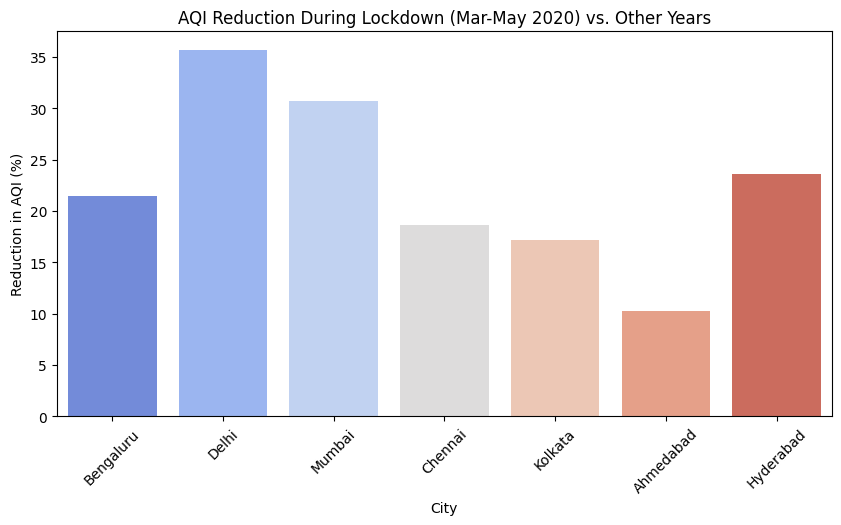

In [36]:

 # Define lockdown period (March - May 2020)
lockdown_start = "2020-03-01"
lockdown_end = "2020-05-31"
 
# Dictionary to store AQI comparisons for each city
aqi_comparison = []
 
for city in cities:
    df = globals()[f'df_{city}']
    df['Date'] = pd.to_datetime(df['Date'])  # Ensure datetime format
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    
    # Filter AQI for lockdown period (March - May) across all years
    lockdown_aqi = df[(df['Date'] >= lockdown_start) & (df['Date'] <= lockdown_end) & (df['Year'] == 2020)]['AQI'].mean()
    other_years_aqi = df[(df['Month'].between(3, 5)) & (df['Year'] != 2020)].groupby('Year')['AQI'].mean()
    
    # Store results for comparison
    aqi_comparison.append({'City': city, 'Lockdown_AQI_2020': lockdown_aqi, 'Avg_AQI_Other_Years': other_years_aqi.mean()})
 
# Convert results into a DataFrame
df_aqi_comparison = pd.DataFrame(aqi_comparison)
 
# Calculate AQI reduction percentage
df_aqi_comparison['AQI_Reduction_%'] = ((df_aqi_comparison['Avg_AQI_Other_Years'] - df_aqi_comparison['Lockdown_AQI_2020']) / df_aqi_comparison['Avg_AQI_Other_Years']) * 100
 
# Display the impact of lockdown on AQI
print(df_aqi_comparison)
 
# Plot AQI comparison
plt.figure(figsize=(10, 5))
sns.barplot(x='City', y='AQI_Reduction_%', data=df_aqi_comparison, palette='coolwarm')
plt.title('AQI Reduction During Lockdown (Mar-May 2020) vs. Other Years')
plt.ylabel('Reduction in AQI (%)')
plt.xlabel('City')
plt.xticks(rotation=45)
plt.show()



### Yearly Average AQI per City (Line Plot)

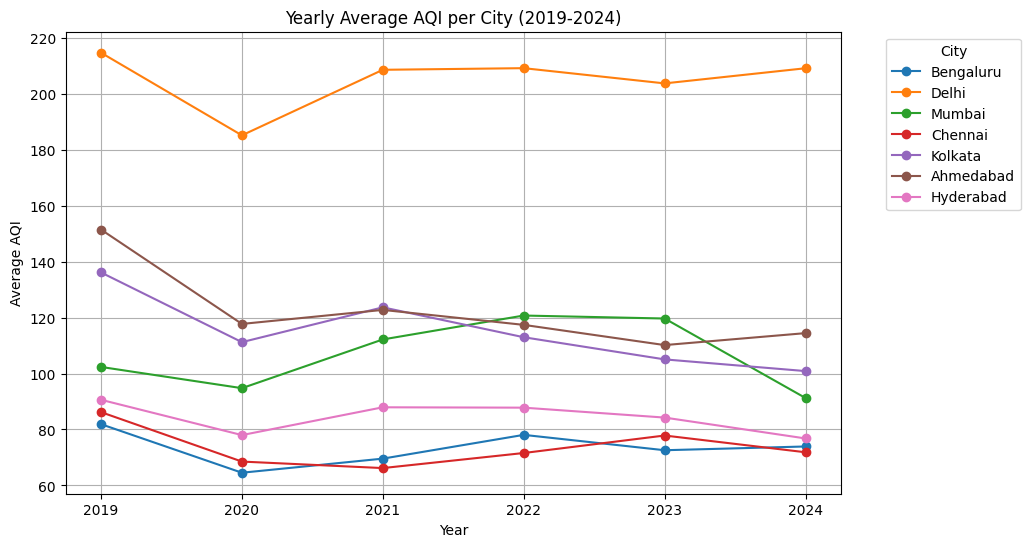

In [38]:


# Dictionary to store yearly average AQI for each city
yearly_avg_aqi = {}
 
for city in cities:
    df = globals()[f'df_{city}']
    df['Date'] = pd.to_datetime(df['Date'])  # Ensure datetime format
    df['Year'] = df['Date'].dt.year  # Extract year
 
    # Compute yearly average AQI
    yearly_avg_aqi[city] = df.groupby('Year')['AQI'].mean()
 
# Convert to DataFrame
df_yearly_avg = pd.DataFrame(yearly_avg_aqi)
 
# Plot yearly trends
plt.figure(figsize=(10, 6))
for city in cities:
    plt.plot(df_yearly_avg.index, df_yearly_avg[city], marker='o', label=city)
 
plt.title('Yearly Average AQI per City (2019-2024)')
plt.xlabel('Year')
plt.ylabel('Average AQI')
plt.legend(title='City', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()


### AQI Distribution


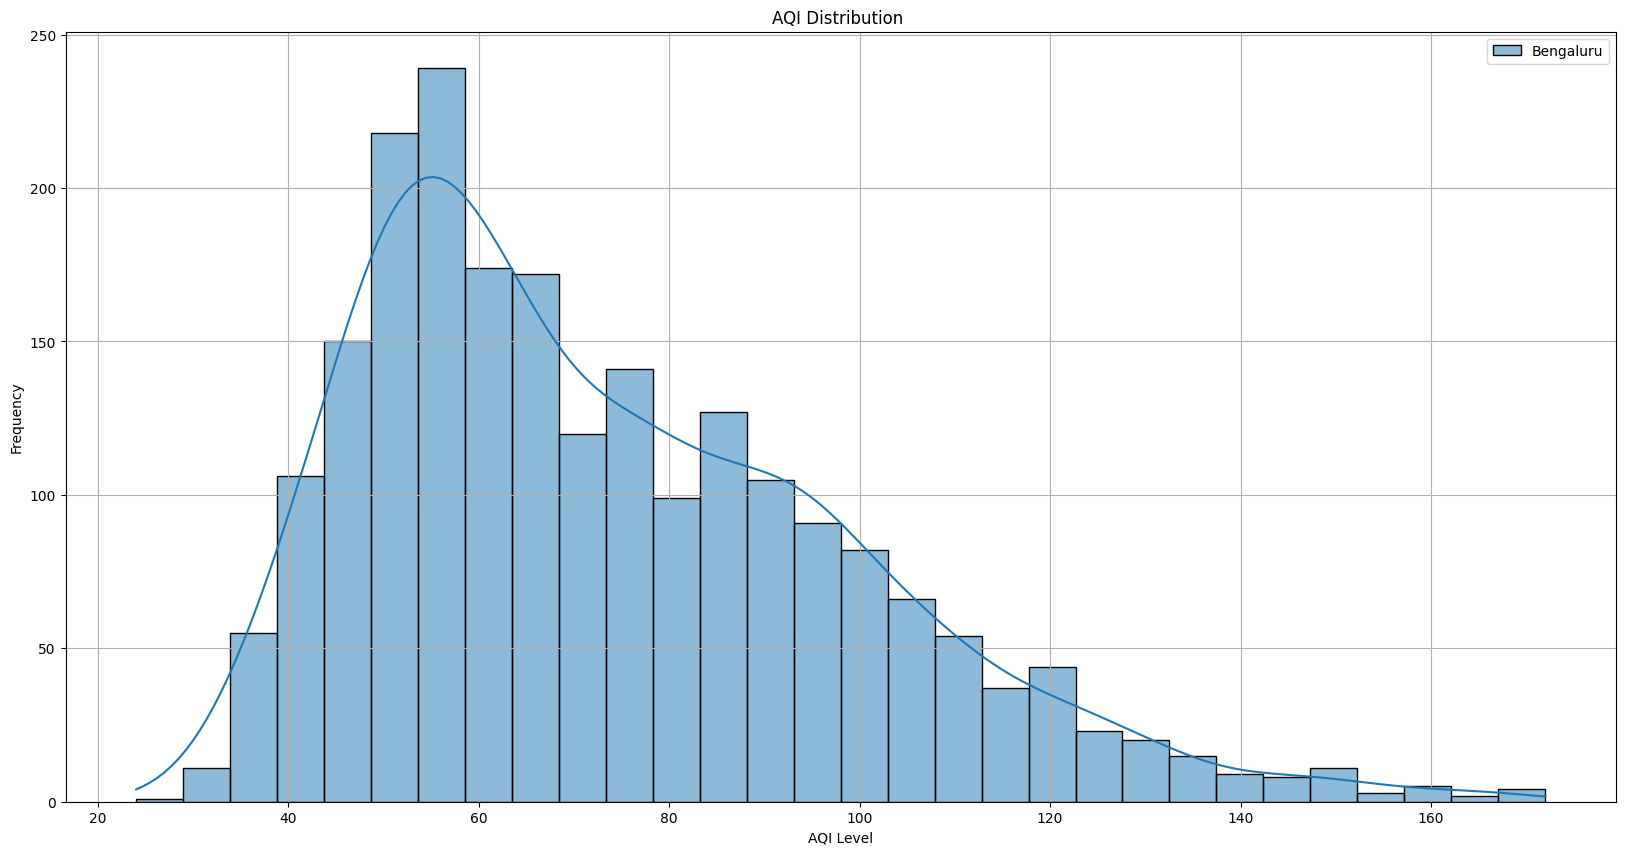

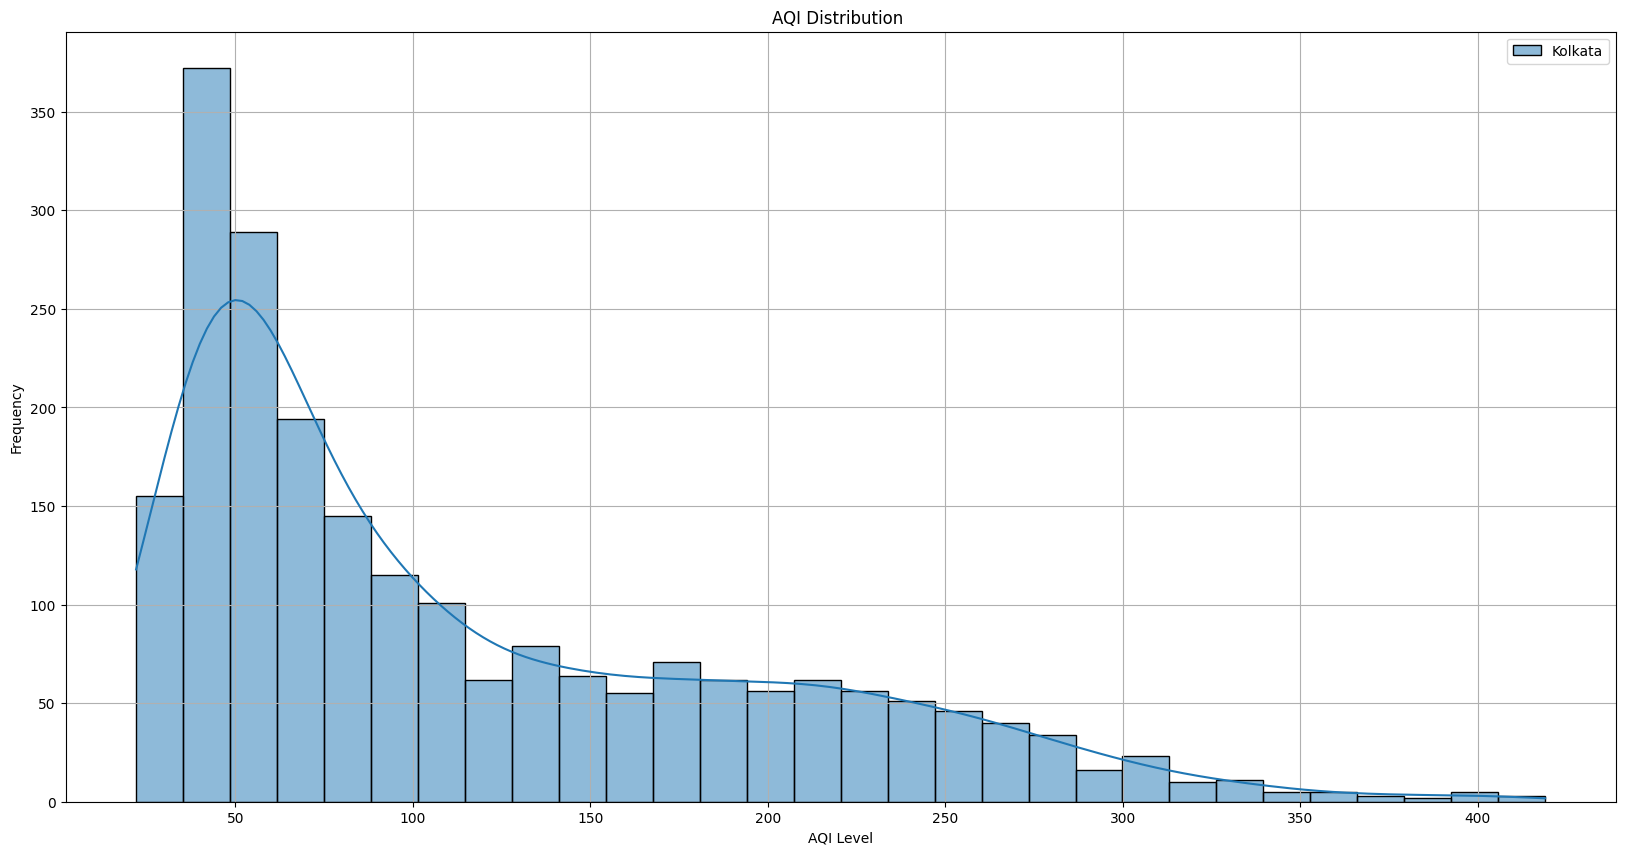

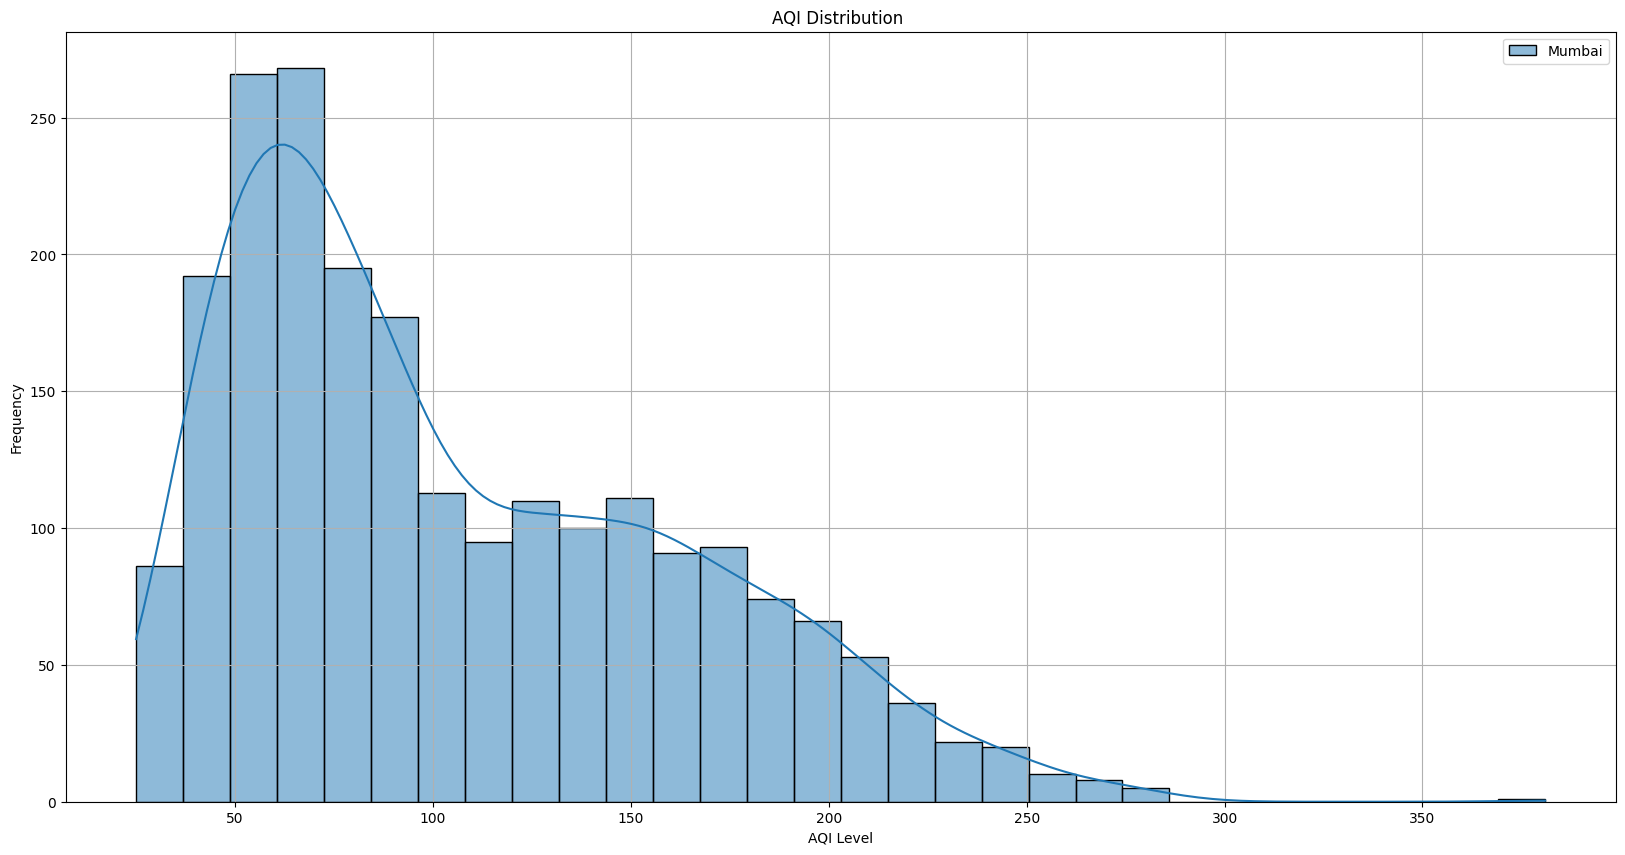

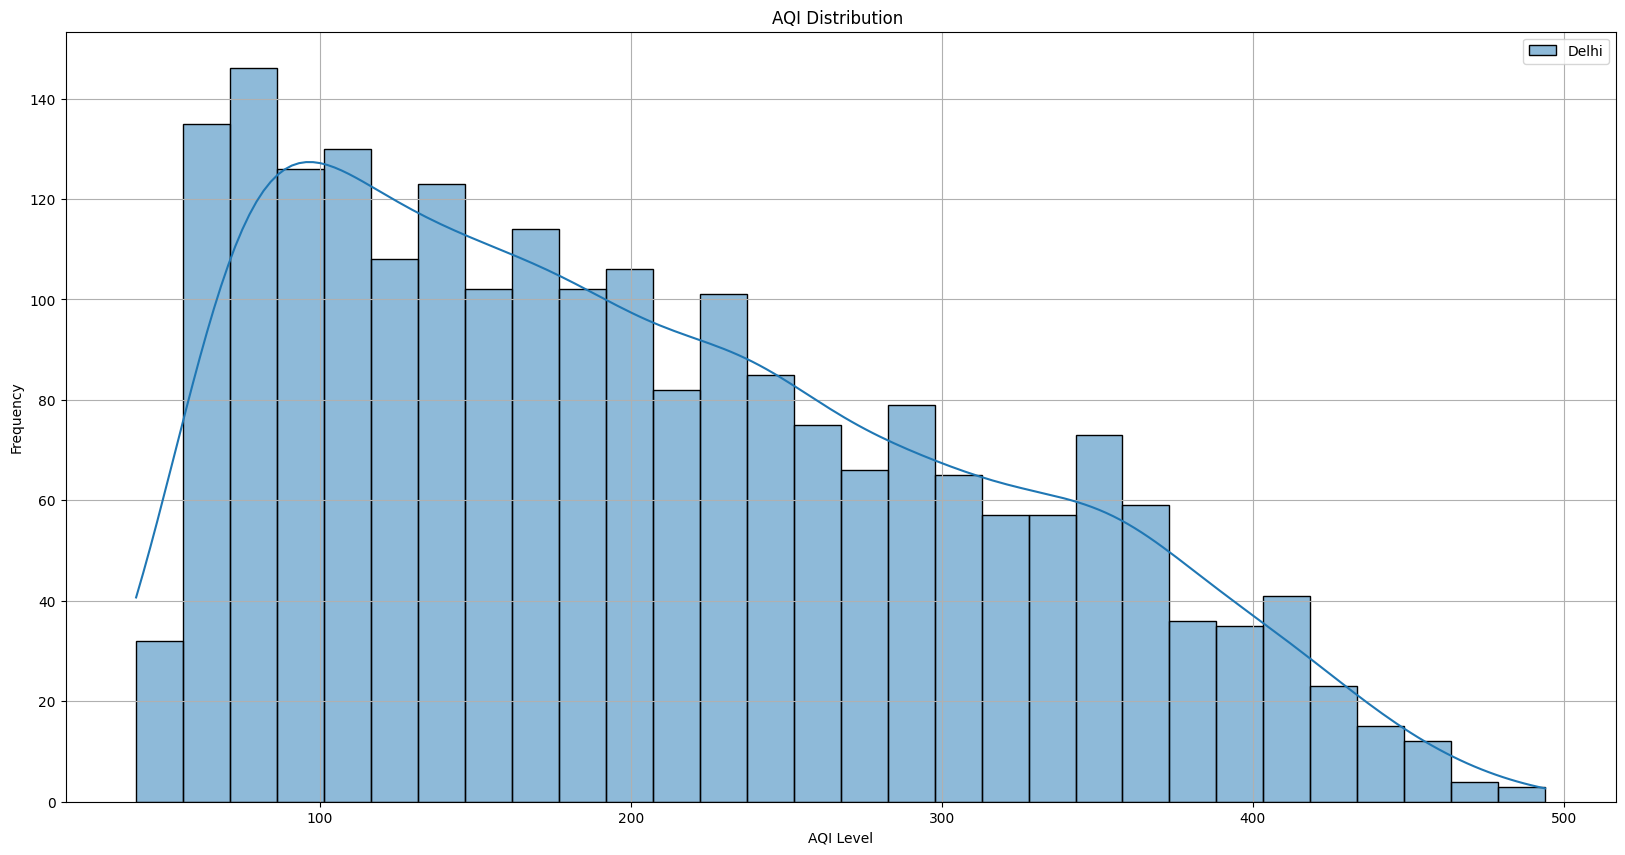

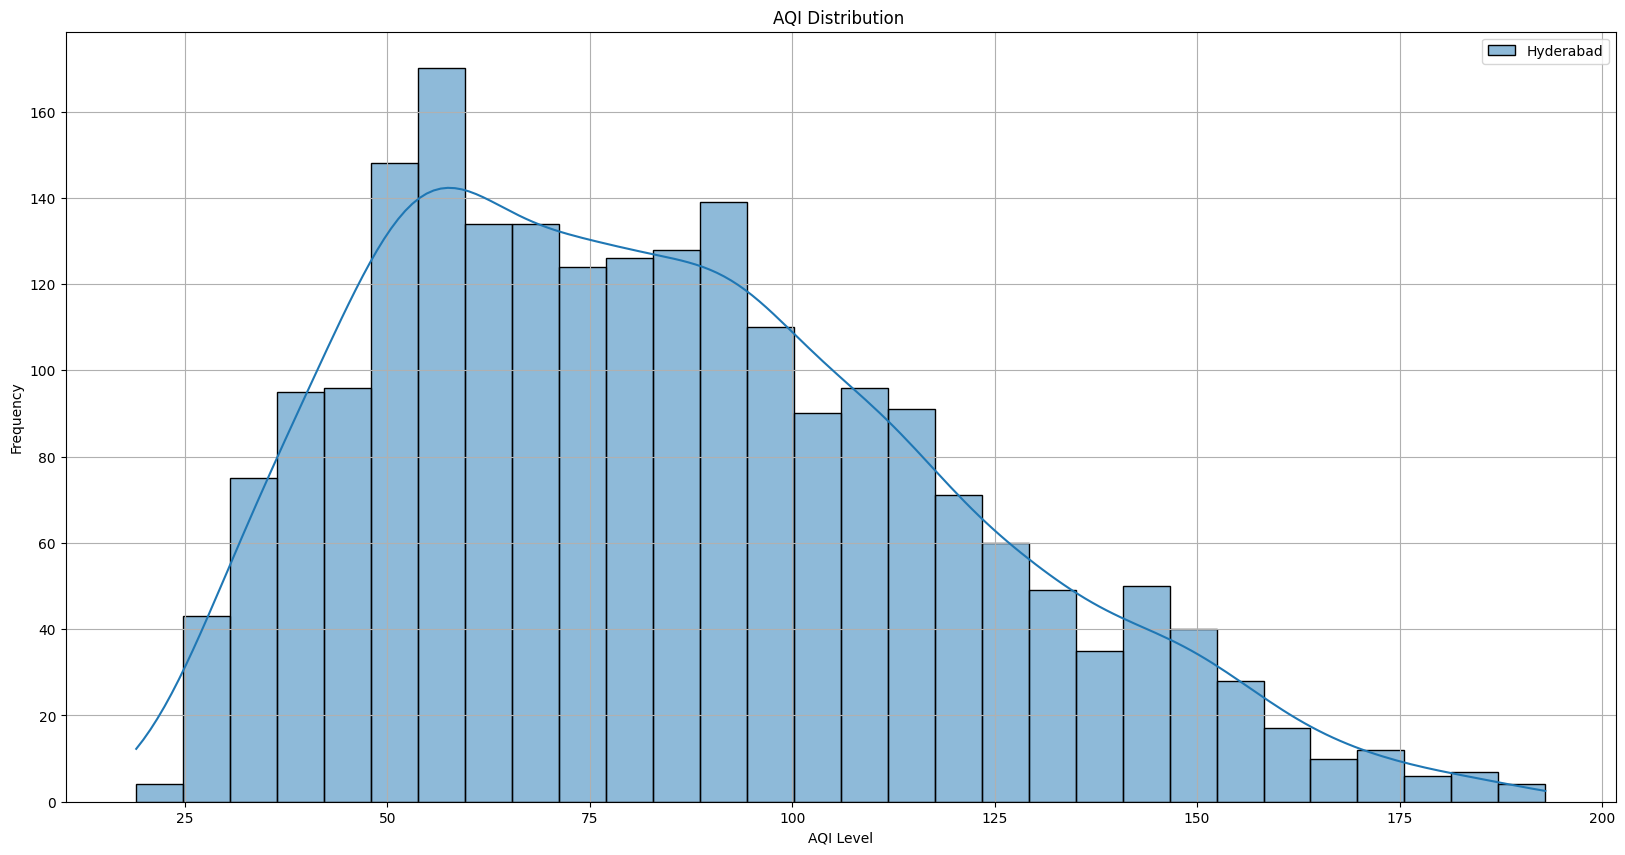

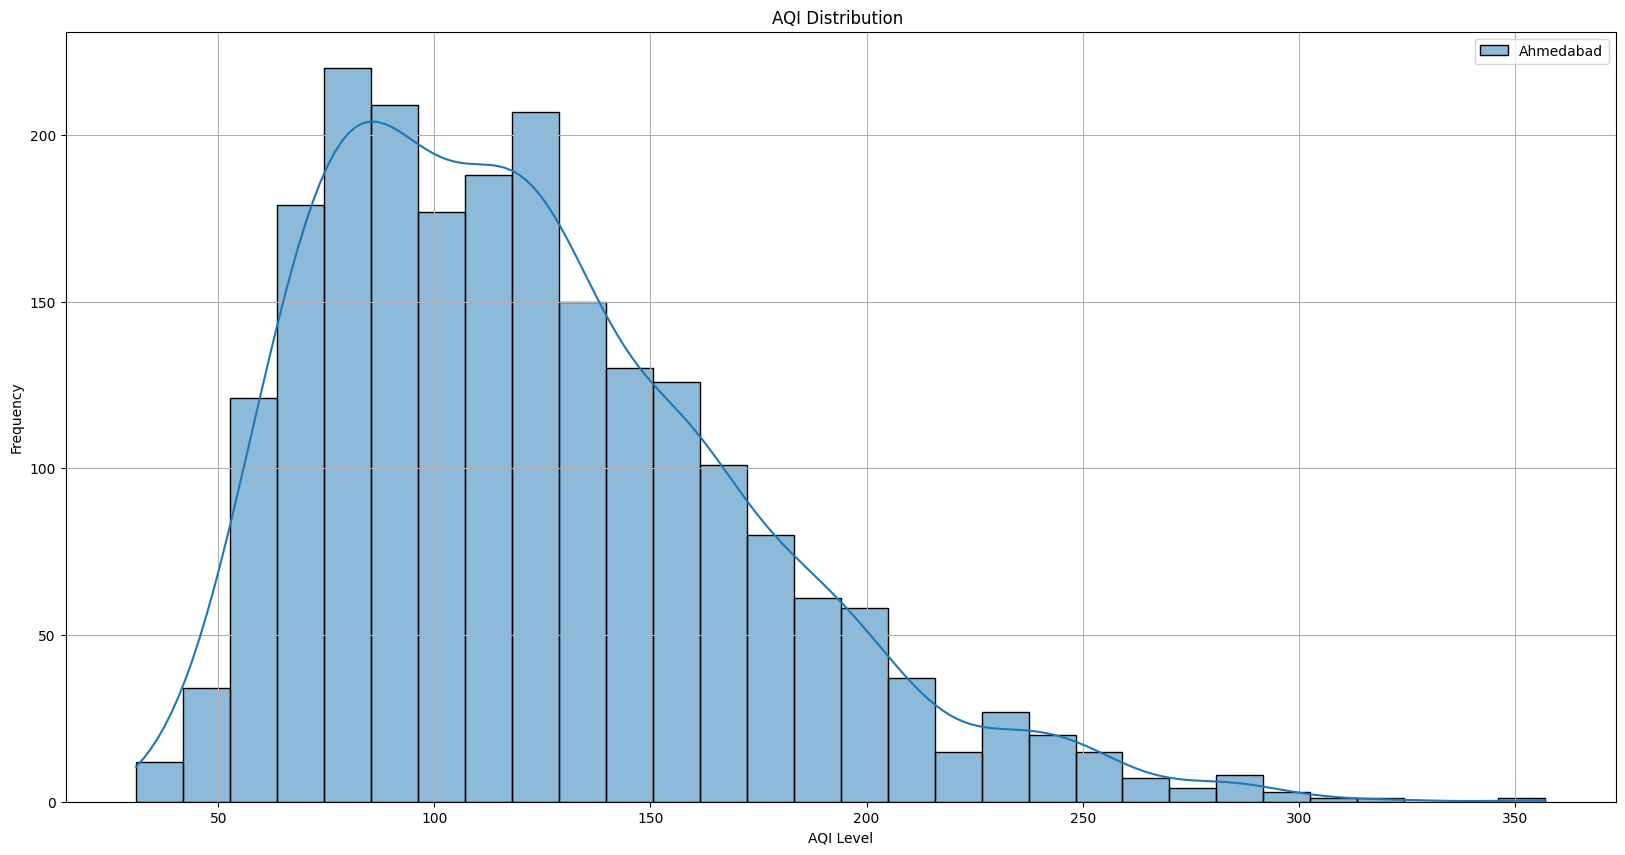

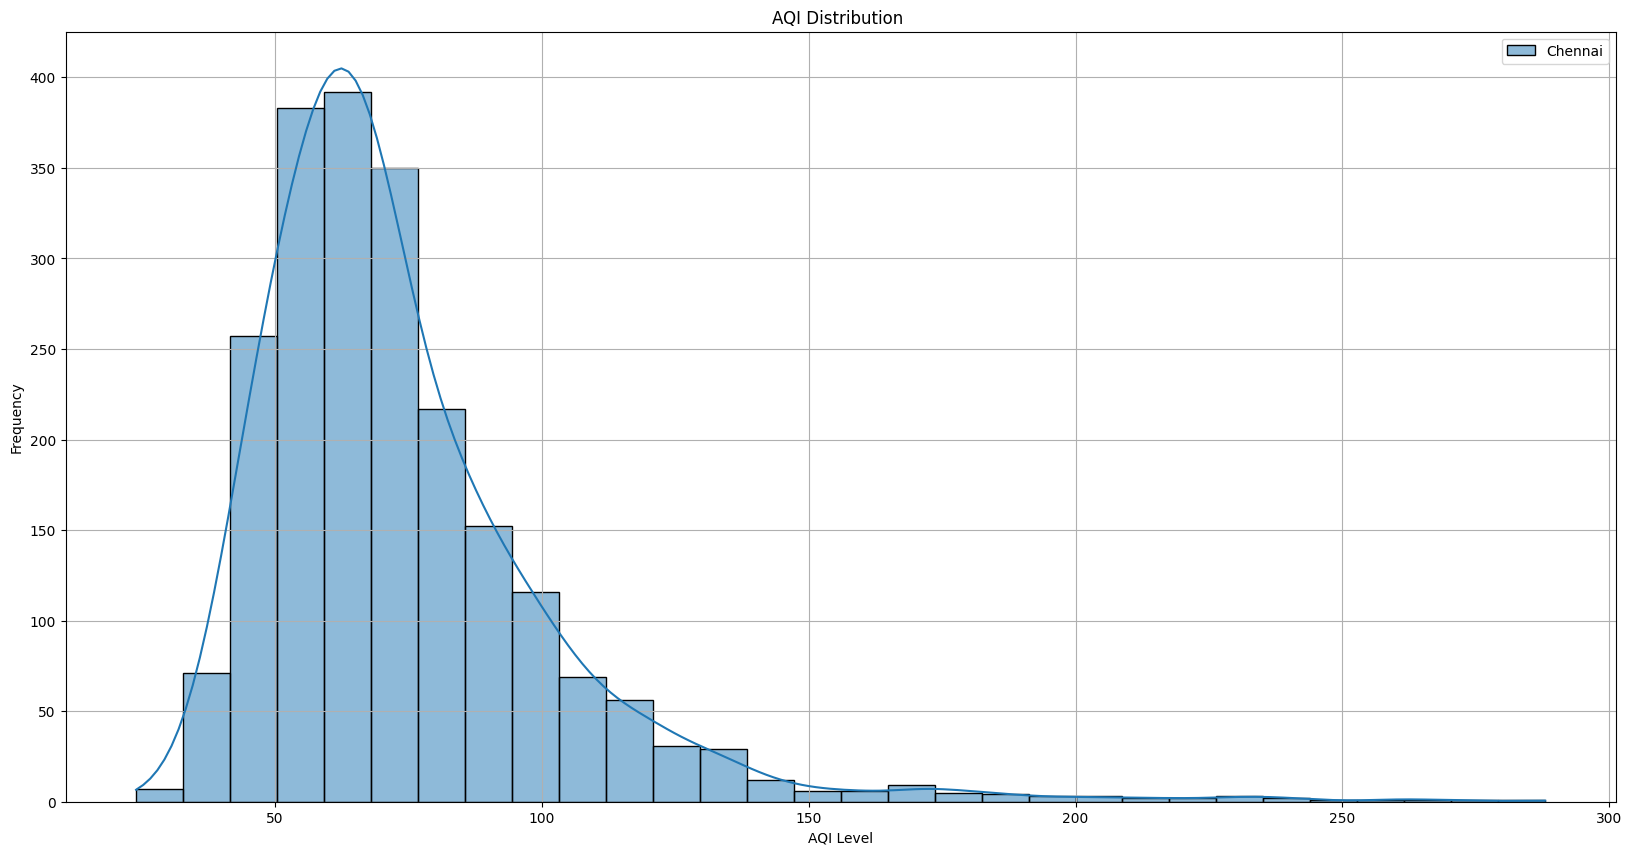

In [40]:
for city, df in dfs.items():
    plt.figure(figsize=(20, 10))
    sns.histplot(df["AQI"], bins=30, label=city, kde=True, alpha=0.5)
 
    plt.xlabel("AQI Level")
    plt.ylabel("Frequency")
    plt.title("AQI Distribution ")
    plt.legend()
    plt.grid()
    plt.show()

In [41]:
df_Bengaluru

,Date,AQI,City,DayOfWeek,Month,Season,Year
0,2019-01-01,118.0,Bengaluru,1,1,Winter,2019
1,2019-01-02,92.0,Bengaluru,2,1,Winter,2019
2,2019-01-03,93.0,Bengaluru,3,1,Winter,2019
3,2019-01-04,104.0,Bengaluru,4,1,Winter,2019
4,2019-01-05,102.0,Bengaluru,5,1,Winter,2019
...,...,...,...,...,...,...,...
2187,2024-12-27,54.0,Bengaluru,4,12,Winter,2024
2188,2024-12-28,57.0,Bengaluru,5,12,Winter,2024
2189,2024-12-29,70.0,Bengaluru,6,12,Winter,2024
2190,2024-12-30,62.0,Bengaluru,0,12,Winter,2024


### Seasonal Decomposition of AQI using statsmodels (Additive & Multiplicative)¶
- Time series decomposition to break down AQI into trend, seasonality, and residuals for each city.


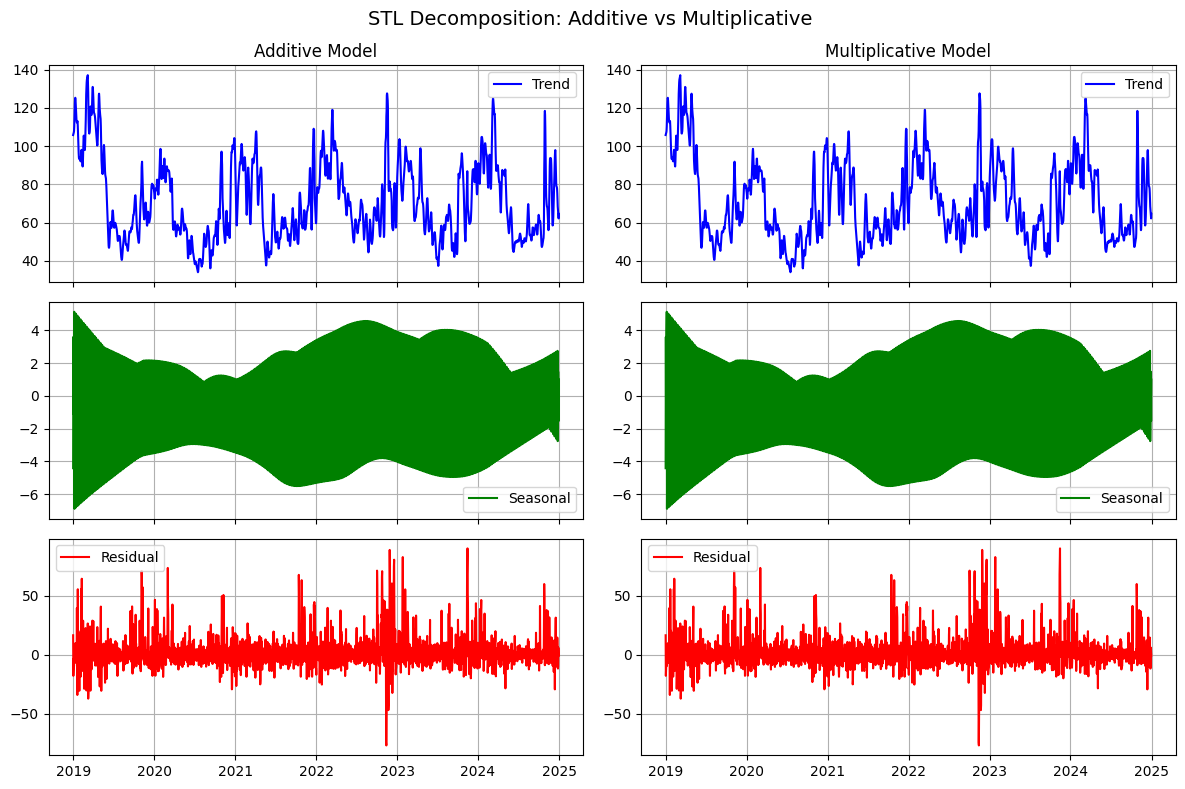

Additive Model Residual Variance: 186.85385906025078
Multiplicative Model Residual Variance: 186.85385906025078
The multiplicative model is better.


In [43]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Copy df_Bengaluru into df
df = df_Bengaluru.copy()
df=df[['Date','AQI']]
# Convert 'Date' column to datetime format and set as index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Perform STL decomposition for both additive and multiplicative models
stl_additive = sm.tsa.STL(df['AQI'], seasonal=91, robust=True).fit()
stl_multiplicative = sm.tsa.STL(df['AQI'], seasonal=91, robust=True, seasonal_deg=1).fit()

# Plot results for comparison
fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True)
fig.suptitle("STL Decomposition: Additive vs Multiplicative", fontsize=14)

# Additive Model
axes[0, 0].set_title("Additive Model")
axes[0, 0].plot(df.index, stl_additive.trend, label="Trend", color='blue')
axes[1, 0].plot(df.index, stl_additive.seasonal, label="Seasonal", color='green')
axes[2, 0].plot(df.index, stl_additive.resid, label="Residual", color='red')

# Multiplicative Model
axes[0, 1].set_title("Multiplicative Model")
axes[0, 1].plot(df.index, stl_multiplicative.trend, label="Trend", color='blue')
axes[1, 1].plot(df.index, stl_multiplicative.seasonal, label="Seasonal", color='green')
axes[2, 1].plot(df.index, stl_multiplicative.resid, label="Residual", color='red')

# Labels
for ax in axes.flatten():
    ax.legend()
    ax.grid()

plt.tight_layout()
plt.show()

# Compare residuals to decide the best model
residual_var_additive = stl_additive.resid.var()
residual_var_multiplicative = stl_multiplicative.resid.var()

print("Additive Model Residual Variance:", residual_var_additive)
print("Multiplicative Model Residual Variance:", residual_var_multiplicative)

# Choose the best model based on lower residual variance
if residual_var_additive < residual_var_multiplicative:
    print("The additive model is better.")
else:
    print("The multiplicative model is better.")


In [44]:
df

,AQI
Date,
2019-01-01,118.0
2019-01-02,92.0
2019-01-03,93.0
2019-01-04,104.0
2019-01-05,102.0
...,...
2024-12-27,54.0
2024-12-28,57.0
2024-12-29,70.0


### Modeling


### Sarima

**ADF Test Before Differencing**
ADF Statistic: -6.738492695885209
p-value: 3.1626045169429e-09
Critical Values: {'1%': -3.5552728880540942, '5%': -2.9157312396694217, '10%': -2.5956695041322315}
✅ Data is stationary (reject H0)

**ADF Test After Differencing**
ADF Statistic: -5.528827957095668
p-value: 1.8068843918829019e-06
Critical Values: {'1%': -3.5656240522121956, '5%': -2.920142229157715, '10%': -2.598014675124952}
✅ Data is stationary (reject H0)


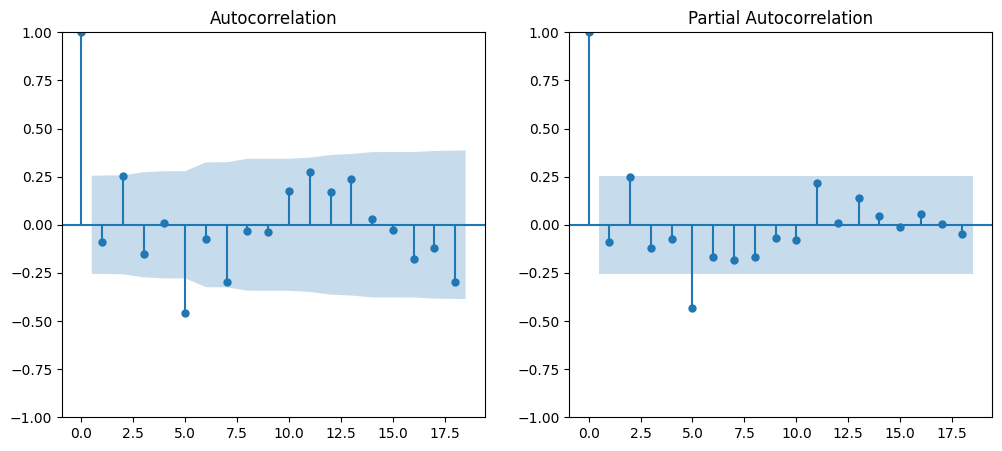

C:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                                AQI   No. Observations:                   60
Model:             SARIMAX(2, 1, 2)x(1, 1, 2, 12)   Log Likelihood                 -60.168
Date:                            Wed, 02 Apr 2025   AIC                            136.335
Time:                                    10:05:28   BIC                            144.301
Sample:                                01-31-2019   HQIC                           137.890
                                     - 12-31-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6821      0.175     -3.889      0.000      -1.026      -0.338
ar.L2         -0.8942      0.231   

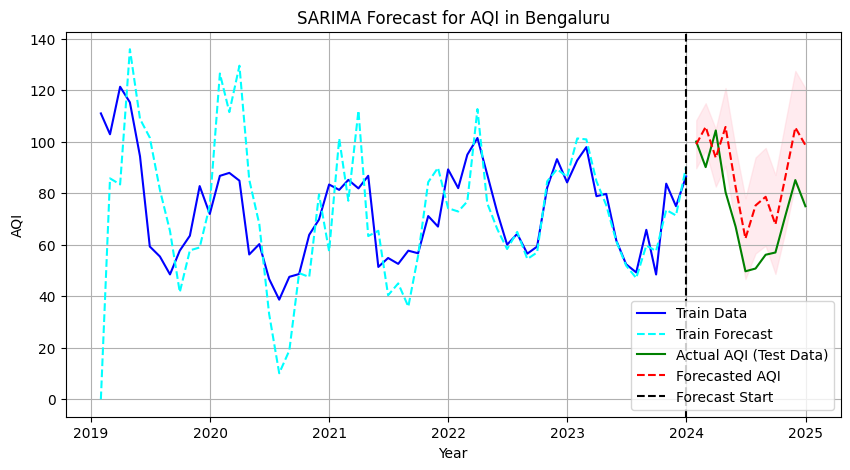

In [88]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Load Bengaluru AQI data
df_bengaluru = df.copy()

# Convert index to datetime if not already
df_bengaluru.index = pd.to_datetime(df_bengaluru.index)

# Resample to monthly average AQI
df_bengaluru = df_bengaluru['AQI'].resample('M').mean()

# Split Data: Train (2019-2023) and Test (2024)
train = df_bengaluru.loc['2019-01-01':'2023-12-31']
test = df_bengaluru.loc['2024-01-01':'2024-12-31']

# Step 1: Check for Stationarity using ADF Test
def adf_test(series):
    result = adfuller(series.dropna())
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("Critical Values:", result[4])
    if result[1] < 0.05:
        print("\u2705 Data is stationary (reject H0)")
    else:
        print("\u274C Data is non-stationary (fail to reject H0)")

print("**ADF Test Before Differencing**")
adf_test(train)

# Step 2: Differencing (if needed)
train_diff = train.diff().dropna()
print("\n**ADF Test After Differencing**")
adf_test(train_diff)

# Step 3: Plot ACF and PACF to determine ARIMA (p, d, q)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
plot_acf(train_diff, ax=ax[0])
plot_pacf(train_diff, ax=ax[1])
plt.show()

# Step 4: Train SARIMA Model
sarima_order = (2, 1, 2)  # (p, d, q)
seasonal_order = (1, 1, 2, 12)  # (P, D, Q, s)

model = sm.tsa.statespace.SARIMAX(train, 
                                  order=sarima_order, 
                                  seasonal_order=seasonal_order, 
                                  enforce_stationarity=False, 
                                  enforce_invertibility=False)
sarima_fit = model.fit()

print(sarima_fit.summary())

# Step 5: Forecast Future AQI Values
forecast = sarima_fit.get_forecast(steps=len(test))
forecast_index = test.index
forecast_values = forecast.predicted_mean
conf_int = forecast.conf_int()

# Step 6: In-Sample Forecast for Training Data
train_forecast = sarima_fit.fittedvalues

# Step 7: Evaluate Model
mae_train = mean_absolute_error(train[1:], train_forecast[1:])  # Exclude first NaN value
test_mae = mean_absolute_error(test, forecast_values)
mse_train = mean_squared_error(train[1:], train_forecast[1:])
test_mse = mean_squared_error(test, forecast_values)
rmse_train = np.sqrt(mse_train)
test_rmse = np.sqrt(test_mse)

print("Model Evaluation:")
print(f"Train MAE: {mae_train}")
print(f"Train MSE: {mse_train}")
print(f"Train RMSE: {rmse_train}")
print(f"Test MAE: {test_mae}")
print(f"Test MSE: {test_mse}")
print(f"Test RMSE: {test_rmse}")

# Step 8: Forecast Monthly Mean AQI for Each Month
monthly_forecast = forecast_values.groupby(forecast_values.index.month).mean()
print("Monthly Mean Forecast AQI:")
print(monthly_forecast)

# Step 9: Plot Results
plt.figure(figsize=(10, 5))
plt.plot(train, label='Train Data', color='blue')
plt.plot(train.index, train_forecast, label='Train Forecast', color='cyan', linestyle='dashed')
plt.plot(test, label='Actual AQI (Test Data)', color='green')
plt.plot(forecast_index, forecast_values, label='Forecasted AQI', color='red', linestyle='dashed')
plt.fill_between(forecast_index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3)
plt.axvline(x=pd.Timestamp('2024-01-01'), color='black', linestyle='dashed', label='Forecast Start')
plt.title('SARIMA Forecast for AQI in Bengaluru')
plt.xlabel('Year')
plt.ylabel('AQI')
plt.legend()
plt.grid()
plt.show()


**ADF Test Before Differencing**
ADF Statistic: -6.963593243888291
p-value: 9.033039960931767e-10
Critical Values: {'1%': -3.5319549603840894, '5%': -2.905755128523123, '10%': -2.5903569458676765}
✅ Data is stationary (reject H0)

**ADF Test After Differencing**
ADF Statistic: -5.3458385581981975
p-value: 4.397222160669529e-06
Critical Values: {'1%': -3.542412746661615, '5%': -2.910236235808284, '10%': -2.5927445767266866}
✅ Data is stationary (reject H0)


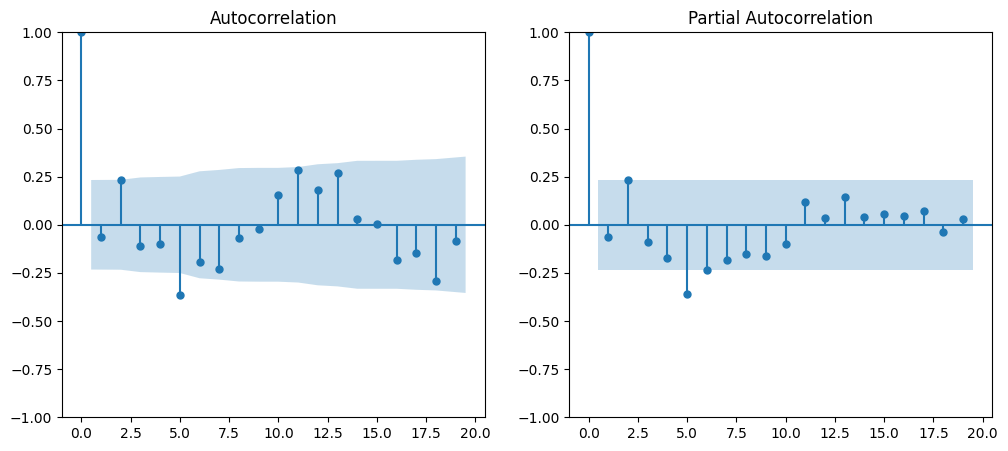

C:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                                AQI   No. Observations:                   72
Model:             SARIMAX(2, 1, 2)x(1, 1, 2, 12)   Log Likelihood                 -99.198
Date:                            Wed, 02 Apr 2025   AIC                            214.396
Time:                                    10:08:59   BIC                            226.122
Sample:                                01-31-2019   HQIC                           218.283
                                     - 12-31-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6688      0.149     -4.493      0.000      -0.961      -0.377
ar.L2         -0.7579      0.221   

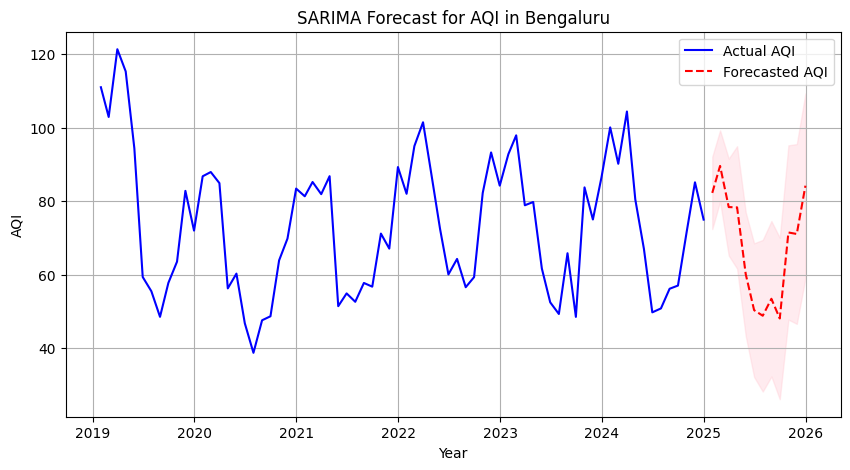

In [91]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pandas as pd
import matplotlib.pyplot as plt

# Load Bengaluru AQI data
df_bengaluru = df.copy()

# Resample to monthly average AQI
df_bengaluru = df_bengaluru['AQI'].resample('M').mean()

# Step 1: Check for Stationarity using ADF Test
def adf_test(series):
    result = adfuller(series.dropna())
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("Critical Values:", result[4])
    if result[1] < 0.05:
        print("\u2705 Data is stationary (reject H0)")
    else:
        print("\u274C Data is non-stationary (fail to reject H0)")

print("**ADF Test Before Differencing**")
adf_test(df_bengaluru)

# Step 2: Differencing (if needed)
df_bengaluru_diff = df_bengaluru.diff().dropna()

print("\n**ADF Test After Differencing**")
adf_test(df_bengaluru_diff)

# Step 3: Plot ACF and PACF to determine ARIMA (p, d, q)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
plot_acf(df_bengaluru_diff, ax=ax[0])
plot_pacf(df_bengaluru_diff, ax=ax[1])
plt.show()

# # Step 4: Train SARIMA Model
# sarima_order = (1, 1, 1)  # (p, d, q)
# seasonal_order = (1, 1, 1, 12)  # (P, D, Q, s) → Seasonal component


# Step 4: Train SARIMA Model
sarima_order = (2, 1, 2)  # (p, d, q)
seasonal_order = (1, 1, 2, 12)  # (P, D, Q, s) → Seasonal component
 

model = sm.tsa.statespace.SARIMAX(df_bengaluru, 
                                  order=sarima_order, 
                                  seasonal_order=seasonal_order, 
                                  enforce_stationarity=False, 
                                  enforce_invertibility=False)
sarima_fit = model.fit()

print(sarima_fit.summary())

# Step 5: Forecast Future AQI Values
future_periods = 12  # Forecast next 12 months
forecast = sarima_fit.get_forecast(steps=future_periods)
forecast_index = pd.date_range(start=df_bengaluru.index[-1], periods=future_periods+1, freq='M')[1:]
forecast_values = forecast.predicted_mean
conf_int = forecast.conf_int()

# Plot Results
plt.figure(figsize=(10, 5))
plt.plot(df_bengaluru, label='Actual AQI', color='blue')
plt.plot(forecast_index, forecast_values, label='Forecasted AQI', color='red', linestyle='dashed')
plt.fill_between(forecast_index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3)
plt.title('SARIMA Forecast for AQI in Bengaluru')
plt.xlabel('Year')
plt.ylabel('AQI')
plt.legend()
plt.grid()
plt.show()


### For daily predictions Sarima doesnt perform well

**ADF Test Before Differencing**
ADF Statistic: -4.035929898830908
p-value: 0.0012336273158579008
Critical Values: {'1%': -3.433976034843506, '5%': -2.8631416925158244, '10%': -2.5676226884667694}
✅ Data is stationary (reject H0)

**ADF Test After Differencing**
ADF Statistic: -15.586984411359792
p-value: 1.90110354448711e-28
Critical Values: {'1%': -3.433976034843506, '5%': -2.8631416925158244, '10%': -2.5676226884667694}
✅ Data is stationary (reject H0)


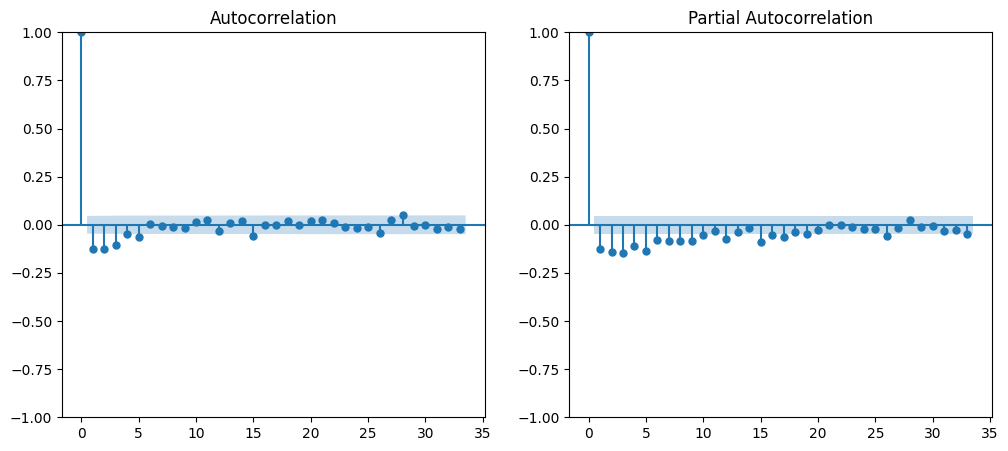

                                     SARIMAX Results                                      
Dep. Variable:                                AQI   No. Observations:                 1826
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -7388.076
Date:                            Wed, 02 Apr 2025   AIC                          14786.152
Time:                                    09:51:40   BIC                          14813.627
Sample:                                01-01-2019   HQIC                         14796.294
                                     - 12-31-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6565      0.019     33.905      0.000       0.619       0.694
ma.L1         -0.9471      0.010   

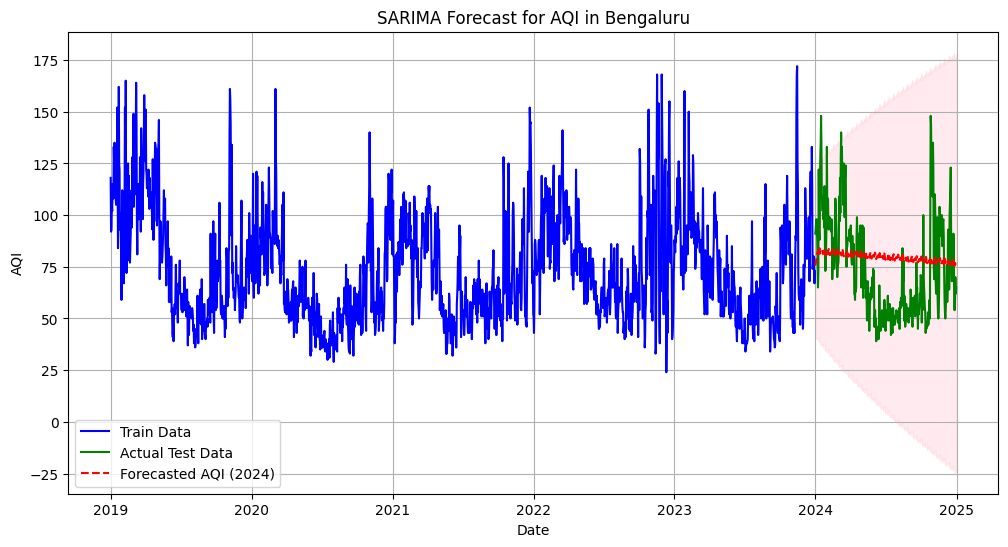

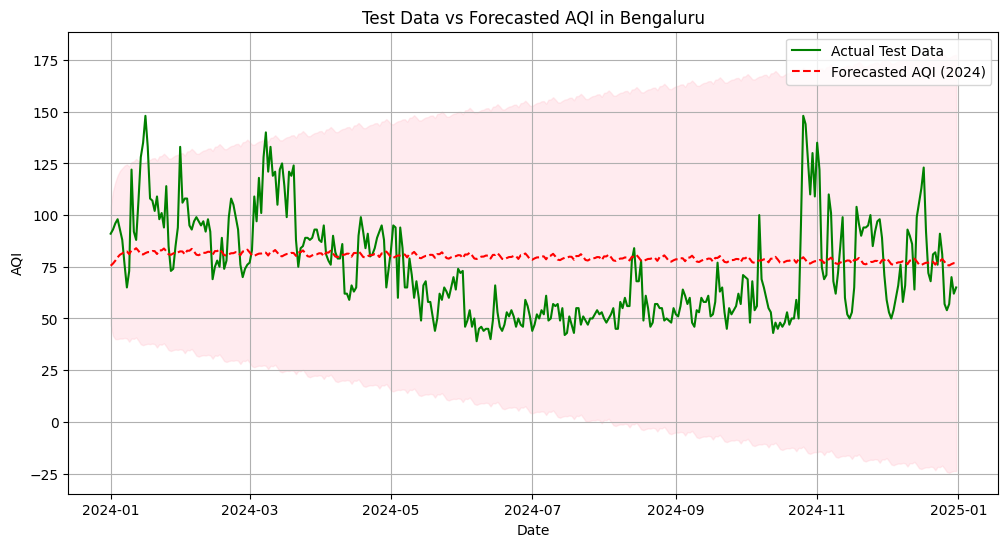

In [76]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Load Bengaluru AQI data
df_bengaluru = df.copy()

# # Convert 'Date' column to datetime format and set as index
# df_bengaluru['Date'] = pd.to_datetime(df_bengaluru['Date'])
# df_bengaluru.set_index('Date', inplace=True)

# Resample to daily average AQI
df_bengaluru = df_bengaluru['AQI'].resample('D').mean()

# Split data into train (until 31/12/2023) and test (2024)
train = df_bengaluru.loc[:'2023-12-31']
test = df_bengaluru.loc['2024-01-01':]

# Step 1: Check for Stationarity using ADF Test
def adf_test(series):
    result = adfuller(series.dropna())
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("Critical Values:", result[4])
    if result[1] < 0.05:
        print("\u2705 Data is stationary (reject H0)")
    else:
        print("\u274C Data is non-stationary (fail to reject H0)")

print("**ADF Test Before Differencing**")
adf_test(train)

# Step 2: Differencing (if needed)
train_diff = train.diff().dropna()

print("\n**ADF Test After Differencing**")
adf_test(train_diff)

# Step 3: Plot ACF and PACF to determine ARIMA (p, d, q)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
plot_acf(train_diff, ax=ax[0])
plot_pacf(train_diff, ax=ax[1])
plt.show()

# Step 4: Train SARIMA Model
sarima_order = (1, 1, 1)  # (p, d, q)
seasonal_order = (1, 1, 1, 12)  # (P, D, Q, s) → Seasonal component

model = sm.tsa.statespace.SARIMAX(train, 
                                  order=sarima_order, 
                                  seasonal_order=seasonal_order, 
                                  enforce_stationarity=False, 
                                  enforce_invertibility=False)
sarima_fit = model.fit()

print(sarima_fit.summary())

# Step 5: Forecast Future AQI Values for 2024
forecast_2024 = sarima_fit.get_forecast(steps=len(test))
forecast_index = test.index
forecast_values = forecast_2024.predicted_mean
conf_int = forecast_2024.conf_int()

# Evaluation
mae = mean_absolute_error(test, forecast_values)
mse = mean_squared_error(test, forecast_values)
rmse = np.sqrt(mse)
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

# Plot Train, Forecast, and Actual
plt.figure(figsize=(12, 6))
plt.plot(train, label='Train Data', color='blue')
plt.plot(test, label='Actual Test Data', color='green')
plt.plot(forecast_index, forecast_values, label='Forecasted AQI (2024)', color='red', linestyle='dashed')
plt.fill_between(forecast_index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3)
plt.title('SARIMA Forecast for AQI in Bengaluru')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.grid()
plt.show()

# Plot Test Forecast vs Actual
plt.figure(figsize=(12, 6))
plt.plot(test, label='Actual Test Data', color='green')
plt.plot(forecast_index, forecast_values, label='Forecasted AQI (2024)', color='red', linestyle='dashed')
plt.fill_between(forecast_index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3)
plt.title('Test Data vs Forecasted AQI in Bengaluru')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.grid()
plt.show()

### Prophat

11:29:19 - cmdstanpy - INFO - Chain [1] start processing
11:29:19 - cmdstanpy - INFO - Chain [1] done processing
11:29:20 - cmdstanpy - INFO - Chain [1] start processing
11:29:20 - cmdstanpy - INFO - Chain [1] done processing
11:29:20 - cmdstanpy - INFO - Chain [1] start processing
11:29:21 - cmdstanpy - INFO - Chain [1] done processing
11:29:21 - cmdstanpy - INFO - Chain [1] start processing
11:29:21 - cmdstanpy - INFO - Chain [1] done processing
11:29:22 - cmdstanpy - INFO - Chain [1] start processing
11:29:22 - cmdstanpy - INFO - Chain [1] done processing
11:29:23 - cmdstanpy - INFO - Chain [1] start processing
11:29:23 - cmdstanpy - INFO - Chain [1] done processing
11:29:24 - cmdstanpy - INFO - Chain [1] start processing
11:29:24 - cmdstanpy - INFO - Chain [1] done processing
11:29:25 - cmdstanpy - INFO - Chain [1] start processing
11:29:25 - cmdstanpy - INFO - Chain [1] done processing
11:29:26 - cmdstanpy - INFO - Chain [1] start processing
11:29:26 - cmdstanpy - INFO - Chain [1]


Train Metrics:
MAE:  12.0988
MSE:  244.8510
RMSE: 15.6477

Test Metrics:
MAE:  9.7246
MSE:  189.4779
RMSE: 13.7651


11:29:43 - cmdstanpy - INFO - Chain [1] start processing
11:29:43 - cmdstanpy - INFO - Chain [1] done processing


  0%|          | 0/5 [00:00<?, ?it/s]

11:29:44 - cmdstanpy - INFO - Chain [1] start processing
11:29:44 - cmdstanpy - INFO - Chain [1] done processing
11:29:44 - cmdstanpy - INFO - Chain [1] start processing
11:29:44 - cmdstanpy - INFO - Chain [1] done processing
11:29:45 - cmdstanpy - INFO - Chain [1] start processing
11:29:45 - cmdstanpy - INFO - Chain [1] done processing
11:29:45 - cmdstanpy - INFO - Chain [1] start processing
11:29:45 - cmdstanpy - INFO - Chain [1] done processing
11:29:46 - cmdstanpy - INFO - Chain [1] start processing
11:29:46 - cmdstanpy - INFO - Chain [1] done processing


     horizon        mae       rmse
0    37 days  20.905271  23.677430
1    38 days  21.123318  23.817407
2    39 days  21.275029  23.916760
3    40 days  21.366579  23.969631
4    41 days  21.463492  24.034990
..       ...        ...        ...
324 361 days  24.661106  31.215051
325 362 days  24.337428  30.847525
326 363 days  23.856418  30.277764
327 364 days  23.335545  29.650982
328 365 days  22.821906  29.052228

[329 rows x 3 columns]


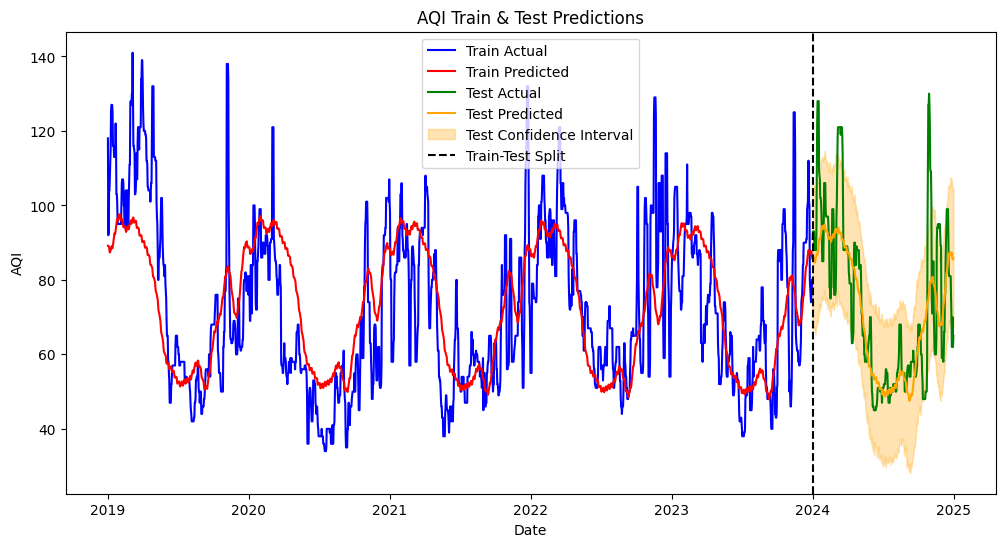

In [162]:
import pandas as pd
import itertools
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from prophet.diagnostics import cross_validation, performance_metrics

# Load dataset
df = df_Bengaluru.copy()
df.rename(columns={'AQI': 'y'}, inplace=True)
df['ds'] = df.index

# Handle Outliers (Optional: Replace extreme values with rolling median)
df['y'] = df['y'].rolling(window=7, center=True).median().fillna(df['y'])

# Split data: Train (2019-2023), Test (2024)
train = df[df['ds'] < '2024-01-01']
test = df[df['ds'] >= '2024-01-01']

# Define hyperparameter grid
param_grid = {
    'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5],
    'seasonality_prior_scale': [1.0, 10.0, 20.0],
    'seasonality_mode': ['additive', 'multiplicative'],
}

# Generate all parameter combinations
param_combinations = list(itertools.product(
    param_grid['changepoint_prior_scale'],
    param_grid['seasonality_prior_scale'],
    param_grid['seasonality_mode']
))

best_mae = float('inf')
best_params = None

# Grid search
for params in param_combinations:
    model = Prophet(
        changepoint_prior_scale=params[0],
        seasonality_prior_scale=params[1],
        seasonality_mode=params[2]
    )
    
    # Add seasonalities
    model.add_seasonality(name='weekly', period=7, fourier_order=3)
    model.add_seasonality(name='yearly', period=365, fourier_order=10)
    
    model.fit(train)
    
    # Make predictions for 2024
    future = model.make_future_dataframe(periods=len(test), freq='D')
    forecast = model.predict(future)

    # Merge actual and predicted values
    test_pred = test.merge(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']], on='ds', how='left').dropna()
    
    # Calculate MAE
    mae = mean_absolute_error(test_pred['y'], test_pred['yhat'])
    
    if mae < best_mae:
        best_mae = mae
        best_params = params
        best_forecast = forecast

# Train and Test Metrics
def calculate_metrics(y_true, y_pred, dataset_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    
    print(f"\n{dataset_name} Metrics:")
    print(f"MAE:  {mae:.4f}")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    return mae, mse, rmse

train_pred = train.merge(best_forecast[['ds', 'yhat']], on='ds', how='left').dropna()
test_pred = test.merge(best_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']], on='ds', how='left').dropna()

train_metrics = calculate_metrics(train_pred['y'], train_pred['yhat'], "Train")
test_metrics = calculate_metrics(test_pred['y'], test_pred['yhat'], "Test")

best_model = Prophet(
    changepoint_prior_scale=best_params[0],
    seasonality_prior_scale=best_params[1],
    seasonality_mode=best_params[2]
)

# Add seasonalities again to the best model
best_model.add_seasonality(name='weekly', period=7, fourier_order=3)
best_model.add_seasonality(name='yearly', period=365, fourier_order=10)

# Fit the model with the entire training data
best_model.fit(train)

# Cross-validation
cv_results = cross_validation(best_model, initial='730 days', period='180 days', horizon='365 days')
performance = performance_metrics(cv_results)
print(performance[['horizon', 'mae', 'rmse']])

# Plot Train and Test Predictions
plt.figure(figsize=(12, 6))
plt.plot(train_pred['ds'], train_pred['y'], label="Train Actual", color='blue')
plt.plot(train_pred['ds'], train_pred['yhat'], label="Train Predicted", color='red')
plt.plot(test_pred['ds'], test_pred['y'], label="Test Actual", color='green')
plt.plot(test_pred['ds'], test_pred['yhat'], label="Test Predicted", color='orange')
plt.fill_between(test_pred['ds'], test_pred['yhat_lower'], test_pred['yhat_upper'], color='orange', alpha=0.3, label="Test Confidence Interval")
plt.axvline(x=pd.Timestamp('2024-01-01'), linestyle="dashed", color="black", label="Train-Test Split")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.title("AQI Train & Test Predictions")
plt.legend()
plt.show()

11:30:08 - cmdstanpy - INFO - Chain [1] start processing
11:30:08 - cmdstanpy - INFO - Chain [1] done processing


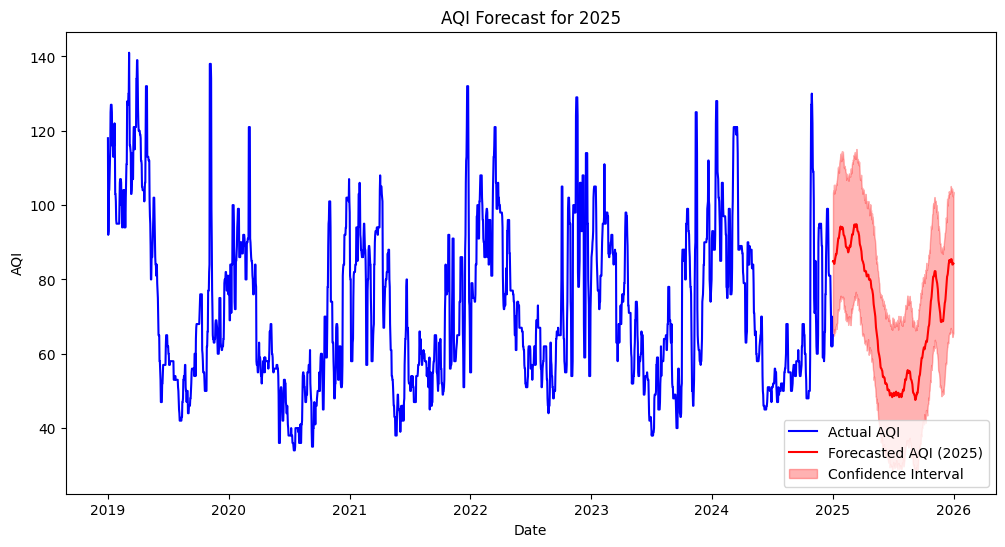

In [164]:
# Retrain the best model using full data (2019-2024)
best_model = Prophet(
    changepoint_prior_scale=best_params[0],
    seasonality_prior_scale=best_params[1],
    seasonality_mode=best_params[2]
)
best_model.add_seasonality(name='weekly', period=7, fourier_order=3)
best_model.add_seasonality(name='yearly', period=365, fourier_order=10)
best_model.fit(df)

# Forecast for 2025
future_2025 = best_model.make_future_dataframe(periods=365, freq='D')
forecast_2025 = best_model.predict(future_2025)
forecast_2025 = forecast_2025[forecast_2025['ds'] >= '2025-01-01'][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

# Plot Forecast for 2025
plt.figure(figsize=(12, 6))
plt.plot(df['ds'], df['y'], label="Actual AQI", color='blue')
plt.plot(forecast_2025['ds'], forecast_2025['yhat'], label="Forecasted AQI (2025)", color='red')
plt.fill_between(forecast_2025['ds'], forecast_2025['yhat_lower'], forecast_2025['yhat_upper'], color='red', alpha=0.3, label="Confidence Interval")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.title("AQI Forecast for 2025")
plt.legend()
plt.show()

### Neural Prophat

WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.945% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.


Training: |                                                                                      | 0/? [00:00<…

Training: |                                                                                      | 0/? [00:00<…

INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.945% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.727% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.727% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D


Predicting: |                                                                                    | 0/? [00:00<…

...

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.945% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.945% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D


Test set - MAE: 12.740186378604076, MSE: 313.06085826194425, RMSE: 17.69352588553068


Predicting: |                                                                                    | 0/? [00:00<…

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


Train set - MAE: 13.495165069680356, MSE: 344.587038660533, RMSE: 18.56305574684656


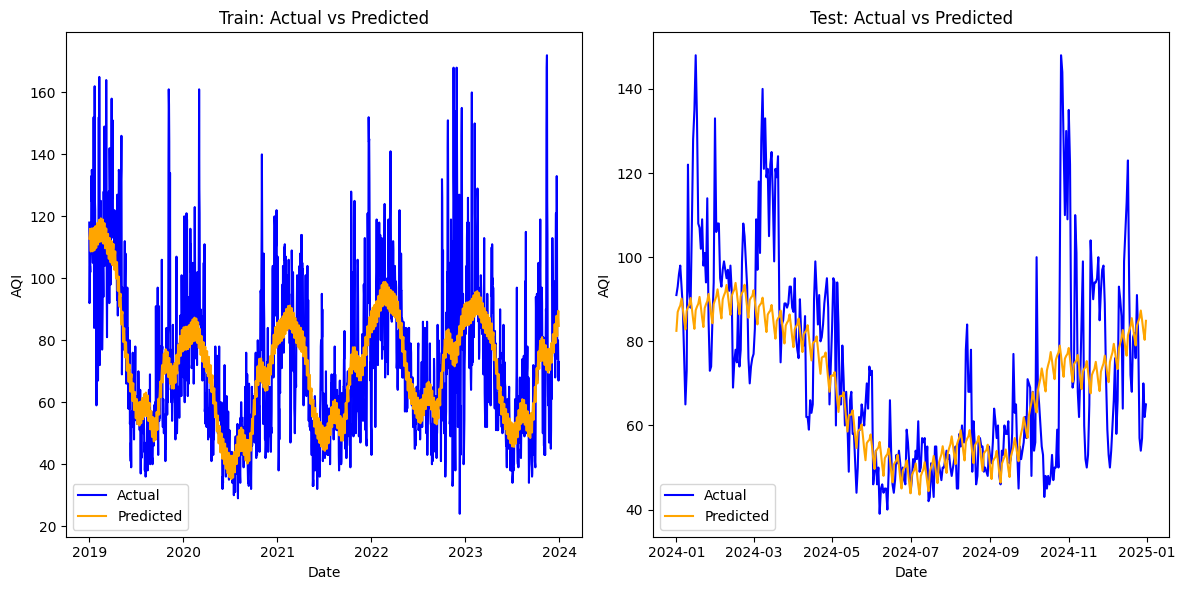

In [315]:
import pandas as pd
from neuralprophet import NeuralProphet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import ParameterGrid

# Function to calculate RMSE
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Prepare the data
df = df_Bengaluru[['Date', 'AQI']].copy()
df['Date'] = pd.to_datetime(df['Date'])

# Filter data from 2019 to 2023 for training
train_df = df[(df['Date'] >= '2019-01-01') & (df['Date'] <= '2023-12-31')]

# Prepare the data for NeuralProphet
train_df = train_df.rename(columns={'Date': 'ds', 'AQI': 'y'})

# Hyperparameter tuning
param_grid = {
    'n_changepoints': [20, 30, 40],  # More changepoints
    'yearly_seasonality': [True, False],  # Both seasonalities
    'weekly_seasonality': [True, False],
    'daily_seasonality': [True, False],  # Adding daily seasonality
    'learning_rate': [0.01],  # Tuning learning rate
    'epochs': [100],  # Tuning epochs
    'batch_size': [32, 64],  # Tuning batch size
}

best_model = None
best_mae = float('inf')
best_params = None

# Grid search for hyperparameter tuning
for params in ParameterGrid(param_grid):
    model = NeuralProphet(
        yearly_seasonality=params['yearly_seasonality'],
        weekly_seasonality=params['weekly_seasonality'],
        daily_seasonality=params['daily_seasonality'],
        n_changepoints=params['n_changepoints'],
        learning_rate=params['learning_rate'],
        epochs=params['epochs'],
        batch_size=params['batch_size']
    )
    # Fit the model
    model.fit(train_df, freq='D')

    # Forecast for 2024
    future = model.make_future_dataframe(train_df, periods=366)
    forecast = model.predict(future)
    
    # Extract forecast for 2024
    forecast_2024 = forecast[['ds', 'yhat1']].loc[forecast['ds'].dt.year == 2024]
    
    # Get actual 2024 values
    actual_2024 = df[(df['Date'] >= '2024-01-01') & (df['Date'] <= '2024-12-31')]
    
    # Merge the actual and predicted data for 2024
    evaluation_df = pd.merge(actual_2024[['Date', 'AQI']], forecast_2024, left_on='Date', right_on='ds', how='left')
    
    # Evaluate the model on the test set
    evaluation_df = evaluation_df.dropna(subset=['AQI', 'yhat1'])  # Remove NaN values
    mae = mean_absolute_error(evaluation_df['AQI'], evaluation_df['yhat1'])
    
    # Track the best model based on MAE
    if mae < best_mae:
        best_mae = mae
        best_model = model
        best_params = params

# Print the best hyperparameters and the MAE
print(f"Best hyperparameters: {best_params}")
print(f"Best MAE on 2024 test set: {best_mae}")

# Reinitialize the best model and fit it on the entire training data
best_model = NeuralProphet(
    yearly_seasonality=best_params['yearly_seasonality'],
    weekly_seasonality=best_params['weekly_seasonality'],
    n_changepoints=best_params['n_changepoints'],
)

best_model.fit(train_df, freq='D')

# Forecast for 2024
future = best_model.make_future_dataframe(train_df, periods=366)
forecast = best_model.predict(future)

# Extract forecast for 2024
forecast_2024 = forecast[['ds', 'yhat1']].loc[forecast['ds'].dt.year == 2024]

# Get actual 2024 values for test set evaluation
actual_2024 = df[(df['Date'] >= '2024-01-01') & (df['Date'] <= '2024-12-31')]
evaluation_df = pd.merge(actual_2024[['Date', 'AQI']], forecast_2024, left_on='Date', right_on='ds', how='left')

# Remove NaN values
evaluation_df = evaluation_df.dropna(subset=['AQI', 'yhat1'])

# Calculate MAE, MSE, RMSE for test set
mae_test = mean_absolute_error(evaluation_df['AQI'], evaluation_df['yhat1'])
mse_test = mean_squared_error(evaluation_df['AQI'], evaluation_df['yhat1'])
rmse_test = rmse(evaluation_df['AQI'], evaluation_df['yhat1'])

print(f"Test set - MAE: {mae_test}, MSE: {mse_test}, RMSE: {rmse_test}")

# Step 3: Evaluate on training data
train_forecast = best_model.predict(train_df)
train_mae = mean_absolute_error(train_df['y'], train_forecast['yhat1'])
train_mse = mean_squared_error(train_df['y'], train_forecast['yhat1'])
train_rmse = rmse(train_df['y'], train_forecast['yhat1'])

print(f"Train set - MAE: {train_mae}, MSE: {train_mse}, RMSE: {train_rmse}")

# Step 4: Plot actual vs predicted
plt.figure(figsize=(12, 6))

# Train data plot
plt.subplot(1, 2, 1)
plt.plot(train_df['ds'], train_df['y'], label='Actual', color='blue')
plt.plot(train_df['ds'], train_forecast['yhat1'], label='Predicted', color='orange')
plt.title("Train: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.legend()

# Test data plot
plt.subplot(1, 2, 2)
plt.plot(evaluation_df['Date'], evaluation_df['AQI'], label='Actual', color='blue')
plt.plot(evaluation_df['Date'], evaluation_df['yhat1'], label='Predicted', color='orange')
plt.title("Test: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.legend()

plt.tight_layout()
plt.show()


Best hyperparameters: {'batch_size': 64, 'daily_seasonality': False, 'epochs': 100, 'learning_rate': 0.01, 'n_changepoints': 30, 'weekly_seasonality': True, 'yearly_seasonality': True}
Best MAE on 2024 test set: 12.389725002434735

Test set - MAE: 12.740186378604076, MSE: 313.06085826194425, RMSE: 17.69352588553068

Train set - MAE: 13.495165069680356, MSE: 344.587038660533, RMSE: 18.56305574684656

WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.945% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.


Training: |                                                                                      | 0/? [00:00<…

Training: |                                                                                      | 0/? [00:00<…

INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.945% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.727% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.727% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D


Predicting: |                                                                                    | 0/? [00:00<…

...

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.945% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.945% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D


Test set - MAE: 12.551565159865415, MSE: 303.4402650097027, RMSE: 17.419536877015496


Predicting: |                                                                                    | 0/? [00:00<…

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


Train set - MAE: 13.464848529861634, MSE: 341.62721478847635, RMSE: 18.4831603030563


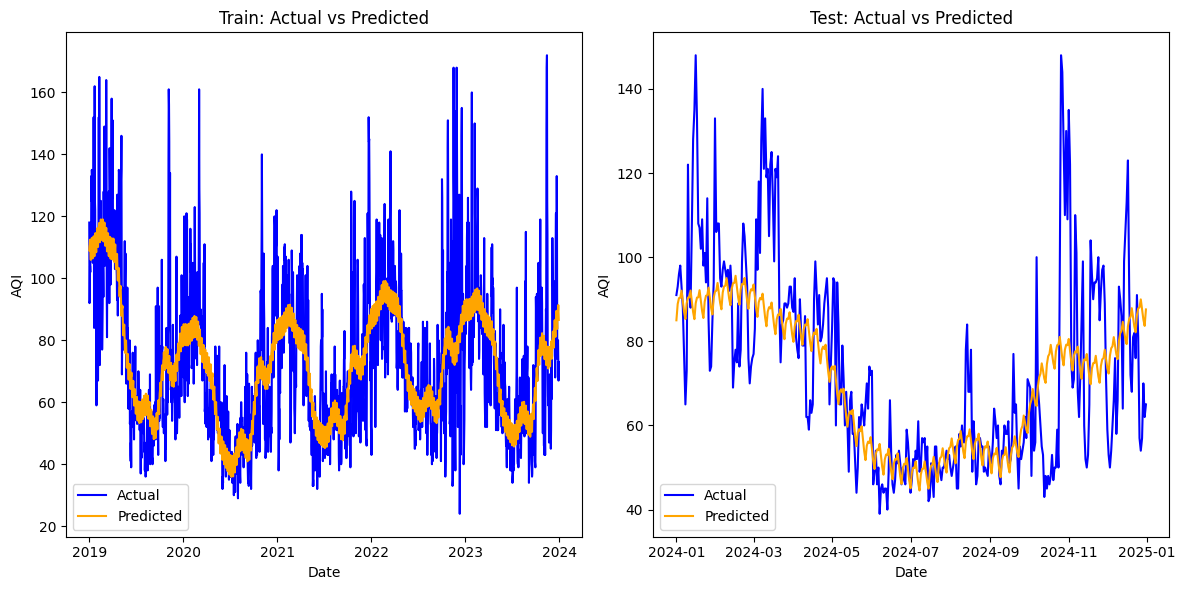

In [320]:
import pandas as pd
from neuralprophet import NeuralProphet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import ParameterGrid

# Function to calculate RMSE
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Prepare the data
df = df_Bengaluru[['Date', 'AQI']].copy()
df['Date'] = pd.to_datetime(df['Date'])

# Filter data from 2019 to 2023 for training
train_df = df[(df['Date'] >= '2019-01-01') & (df['Date'] <= '2023-12-31')]

# Prepare the data for NeuralProphet
train_df = train_df.rename(columns={'Date': 'ds', 'AQI': 'y'})

# Hyperparameter tuning
param_grid = {
    'n_changepoints': [30],  # More changepoints
    'yearly_seasonality': [True],  # Both seasonalities
    'weekly_seasonality': [True],
    'daily_seasonality': [False],  # Adding daily seasonality
    'learning_rate': [0.01],  # Tuning learning rate
    'epochs': [100],  # Tuning epochs
    'batch_size': [ 64],  # Tuning batch size
}

best_model = None
best_mae = float('inf')
best_params = None

# Grid search for hyperparameter tuning
for params in ParameterGrid(param_grid):
    model = NeuralProphet(
        yearly_seasonality=params['yearly_seasonality'],
        weekly_seasonality=params['weekly_seasonality'],
        daily_seasonality=params['daily_seasonality'],
        n_changepoints=params['n_changepoints'],
        learning_rate=params['learning_rate'],
        epochs=params['epochs'],
        batch_size=params['batch_size']
    )
    # Fit the model
    model.fit(train_df, freq='D')

    # Forecast for 2024
    future = model.make_future_dataframe(train_df, periods=366)
    forecast = model.predict(future)
    
    # Extract forecast for 2024
    forecast_2024 = forecast[['ds', 'yhat1']].loc[forecast['ds'].dt.year == 2024]
    
    # Get actual 2024 values
    actual_2024 = df[(df['Date'] >= '2024-01-01') & (df['Date'] <= '2024-12-31')]
    
    # Merge the actual and predicted data for 2024
    evaluation_df = pd.merge(actual_2024[['Date', 'AQI']], forecast_2024, left_on='Date', right_on='ds', how='left')
    
    # Evaluate the model on the test set
    evaluation_df = evaluation_df.dropna(subset=['AQI', 'yhat1'])  # Remove NaN values
    mae = mean_absolute_error(evaluation_df['AQI'], evaluation_df['yhat1'])
    
    # Track the best model based on MAE
    if mae < best_mae:
        best_mae = mae
        best_model = model
        best_params = params

# Print the best hyperparameters and the MAE
print(f"Best hyperparameters: {best_params}")
print(f"Best MAE on 2024 test set: {best_mae}")

# Reinitialize the best model and fit it on the entire training data
best_model = NeuralProphet(
    yearly_seasonality=best_params['yearly_seasonality'],
    weekly_seasonality=best_params['weekly_seasonality'],
    n_changepoints=best_params['n_changepoints'],
)

best_model.fit(train_df, freq='D')

# Forecast for 2024
future = best_model.make_future_dataframe(train_df, periods=366)
forecast = best_model.predict(future)

# Extract forecast for 2024
forecast_2024 = forecast[['ds', 'yhat1']].loc[forecast['ds'].dt.year == 2024]

# Get actual 2024 values for test set evaluation
actual_2024 = df[(df['Date'] >= '2024-01-01') & (df['Date'] <= '2024-12-31')]
evaluation_df = pd.merge(actual_2024[['Date', 'AQI']], forecast_2024, left_on='Date', right_on='ds', how='left')

# Remove NaN values
evaluation_df = evaluation_df.dropna(subset=['AQI', 'yhat1'])

# Calculate MAE, MSE, RMSE for test set
mae_test = mean_absolute_error(evaluation_df['AQI'], evaluation_df['yhat1'])
mse_test = mean_squared_error(evaluation_df['AQI'], evaluation_df['yhat1'])
rmse_test = rmse(evaluation_df['AQI'], evaluation_df['yhat1'])

print(f"Test set - MAE: {mae_test}, MSE: {mse_test}, RMSE: {rmse_test}")

# Step 3: Evaluate on training data
train_forecast = best_model.predict(train_df)
train_mae = mean_absolute_error(train_df['y'], train_forecast['yhat1'])
train_mse = mean_squared_error(train_df['y'], train_forecast['yhat1'])
train_rmse = rmse(train_df['y'], train_forecast['yhat1'])

print(f"Train set - MAE: {train_mae}, MSE: {train_mse}, RMSE: {train_rmse}")

# Step 4: Plot actual vs predicted
plt.figure(figsize=(12, 6))

# Train data plot
plt.subplot(1, 2, 1)
plt.plot(train_df['ds'], train_df['y'], label='Actual', color='blue')
plt.plot(train_df['ds'], train_forecast['yhat1'], label='Predicted', color='orange')
plt.title("Train: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.legend()

# Test data plot
plt.subplot(1, 2, 2)
plt.plot(evaluation_df['Date'], evaluation_df['AQI'], label='Actual', color='blue')
plt.plot(evaluation_df['Date'], evaluation_df['yhat1'], label='Predicted', color='orange')
plt.title("Test: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.legend()

plt.tight_layout()
plt.show()


WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.954% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.


Training: |                                                                                      | 0/? [00:00<…

Training: |                                                                                      | 0/? [00:00<…

INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.954% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.726% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.726% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D


Predicting: |                                                                                    | 0/? [00:00<…

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


Forecast columns: Index(['ds', 'y', 'yhat1', 'yhat1 2.5%', 'yhat1 97.5%', 'trend',
       'season_yearly', 'season_weekly'],
      dtype='object')


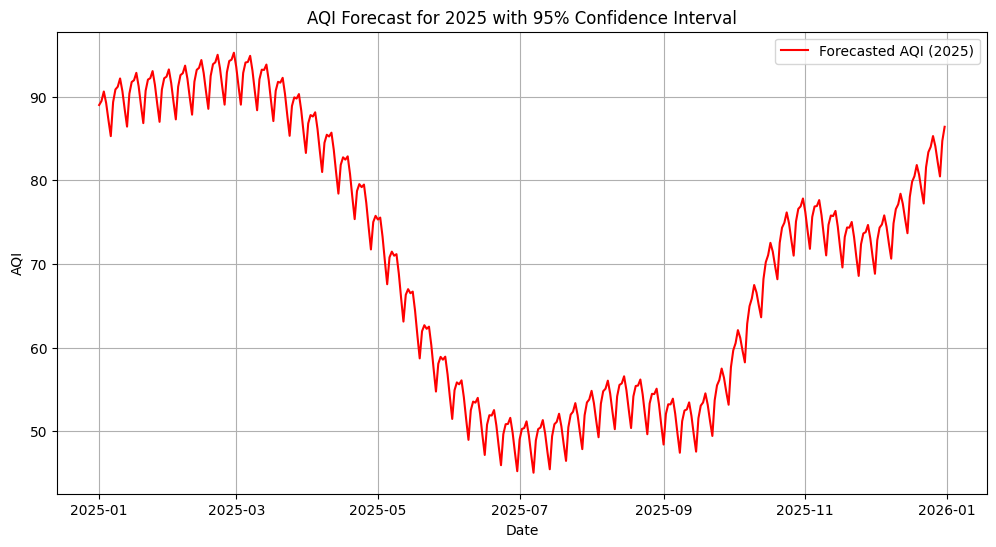

Forecast with confidence intervals saved as 'AQI_Forecast_2025_with_CI.csv'


In [326]:
import pandas as pd
import matplotlib.pyplot as plt
from neuralprophet import NeuralProphet

# Retrain the best model with 2019-2024 data and 95% confidence intervals
best_model = NeuralProphet(
    yearly_seasonality=best_params['yearly_seasonality'],
    weekly_seasonality=best_params['weekly_seasonality'],
    daily_seasonality=best_params['daily_seasonality'],
    n_changepoints=best_params['n_changepoints'],
    learning_rate=best_params['learning_rate'],
    epochs=best_params['epochs'],
    batch_size=best_params['batch_size'],
    quantiles=[0.025, 0.975]  # 95% confidence interval
)

best_model.fit(full_train_df, freq='D')

# Forecast for 2025 with confidence intervals
future_2025 = best_model.make_future_dataframe(full_train_df, periods=365)
forecast_2025 = best_model.predict(future_2025)

# 📌 **Check available columns to confirm confidence intervals are generated**
print("Forecast columns:", forecast_2025.columns)

# Ensure required columns exist before selecting them
expected_cols = {'ds', 'yhat1', 'yhat1_lower', 'yhat1_upper'}
available_cols = set(forecast_2025.columns)

if expected_cols.issubset(available_cols):
    forecast_2025 = forecast_2025[['ds', 'yhat1', 'yhat1_lower', 'yhat1_upper']]
else:
    print("Warning: Confidence interval columns missing! Using only 'ds' and 'yhat1'.")
    forecast_2025 = forecast_2025[['ds', 'yhat1']]

# Filter only 2025 data
forecast_2025 = forecast_2025[forecast_2025['ds'].dt.year == 2025]

# ✅ **Plot AQI forecast for 2025 with confidence intervals**
plt.figure(figsize=(12, 6))
plt.plot(forecast_2025['ds'], forecast_2025['yhat1'], label="Forecasted AQI (2025)", color="red")

# Plot confidence interval only if available
if 'yhat1_lower' in forecast_2025.columns and 'yhat1_upper' in forecast_2025.columns:
    plt.fill_between(forecast_2025['ds'], forecast_2025['yhat1_lower'], forecast_2025['yhat1_upper'], 
                     color='red', alpha=0.2, label="95% Confidence Interval")

plt.title("AQI Forecast for 2025 with 95% Confidence Interval")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.legend()
plt.grid()
plt.show()

# Save the forecast results
forecast_2025.to_csv("AQI_Forecast_2025_with_CI.csv", index=False)
print("Forecast with confidence intervals saved as 'AQI_Forecast_2025_with_CI.csv'")
